<div style="text-align:center;">
    <h2>Analysis_of_Agricultural_Sector_of_Ireland</h2>
    <b>Zygimantas Jakubauskas</b>
</div>

## Table of contents:
</span>

* [1. Introduction](#first-bullet)
* [2. Data Preparation](#third-bullet)
  * [2.1. Exploratory Data Analysis (EDA)](#second-bullet)
  * [2.2. Data Cleaning](#fourth-bullet)
  * [2.3. Data Wrangling and Feauture Engineering](#ninth-bullet)
      * [3.1.2. Imputing missing values](#fifth-bullet)    
  * [3.2. Feature Engineering](#tenth-bullet)
      * [3.2.1. Creating new variables](#22st-bullet)
      * [3.2.3. Data Scaling](#eleventh-bullet)   
* [3. Visualisations](#25th-bullet) 
* [4. Statistical Techniques](#twelfth-bullet)
  * [2.1. Descriptive Statistics](#12th-bullet)
  * [2.2. Inferential Statistics](#13th-bullet)
  * [2.3. Inferential Statistics Techniques](#19th-bullet) 
      * [2.3.1. Difference in Differences statistical significance test](#24th-bullet) 
      * [2.3.2. Augmented Dickey–Fuller test](#15th-bullet) 
      * [2.3.3. One-Way Anova test](#18th-bullet) 
      * [2.3.4. T-test](#seventh-bullet)  
      * [2.3.5. Welch T-test](#23rd-bullet)   
* [5. Machine Learning](#sixth-bullet)
  * [5.1. Time Series Analysis](#21st-bullet)
  * [5.2. K-Means Clustering](#17th-bullet)
      * [5.2.1. Grid Search and Hyperparameter tuning](#20th-bullet)
  * [5.3. Sentiment Analysis](#16th-bullet)
  * [5.4. Machine Learning models](#14th-bullet)
* [6. Dashboard](#11th-bullet)      

Starting with importing all the relevant libraries. 

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from ipywidgets import interact, widgets
import holoviews as hv
import numpy as np
import squarify

import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", message="An unsupported index was provided and will be ignored when e.g. forecasting.")

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import praw


import re
import nltk
nltk.download('vader_lexicon')
nltk.download("wordnet")
nltk.download("punkt")
nltk.download("averaged_perceptron_tagger")
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sid = SentimentIntensityAnalyzer()
from nltk.corpus import stopwords
import string
from string import punctuation
from nltk.stem import WordNetLemmatizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from nltk.corpus import wordnet
from nltk import pos_tag, word_tokenize

from scipy.stats import normaltest, shapiro
import scipy.stats as stats
from scipy.stats import f_oneway
from scipy.stats import ttest_ind
from scipy.stats import levene
from pprint import pprint
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.formula.api as smf

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler
import sklearn.preprocessing as preproc

from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import BayesianRidge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.metrics import silhouette_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score
from sklearn import metrics

from sklearn.model_selection import RandomizedSearchCV

import folium
import ipywidgets as widgets
from ipywidgets import interact, Layout
import altair as alt
alt.data_transformers.enable("default", max_rows=None)
import panel as pn
pn.extension("vega", template="fast")
import asyncio


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\zygis\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\zygis\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\zygis\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\zygis\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!



<span style="color: blue;">

# 1. Introduction <a class="anchor" id="first-bullet"></a>
    
</span>

The agriculture sector in Ireland is one of the oldest and largest indigenous exporting sector and its products are traded from every county to 180 countries around worldwide. The sector comprises of farming, fishing and forestry and products of these three branches are used in manufacture of food, beverages, wool and wood products.
 In 2022 the sector exported goods valued at a record €18.98 billion, accounting for 9% of all the merchandised goods exported from Ireland. The Irish agri-food sector is globally orientated, with approximately 90% of Irish beef, sheepmeat and dairy produce exported each year.
Large proportion of agri-food exports is beef, and this analysis is orientated at the beef sector, looking at production, exports and challenges faced by cattle farmers.


<span style="color: blue;">

# 2. Data Preparation <a class="anchor" id="third-bullet"></a>
    
</span>

Several datasets are used for the project. Starting with reading them.

In [9]:
df_overview = pd.read_csv("agrifood-exports-2014-2022-and-preliminary-2023.csv")

In [10]:
df_beef = pd.read_csv("TSA04.20241223144002.csv")

In [11]:
df_EU_beef_exports = pd.read_csv("FAOSTAT_data_en_EU_exports.csv")

In [12]:
df_EU_beef_export_volumes = pd.read_csv("FAOSTAT_data_en_export_volumes.csv")

In [13]:
df_population = pd.read_csv("population.csv", delimiter=',')  

In [14]:
df_worldwide = pd.read_csv("FAOSTAT_worldwide.csv")

In [15]:
df_worldwide_value = pd.read_csv("FAOSTAT_worldwide_export_value.csv")

In [16]:
df_reddit = pd.read_csv("reddit_comments.csv")

Several datasets are used for the analysis, but many variables are the same across many of them. Data Dictionary explains the variables.

###  Data dictionary 
    
__Domain Code__ and __STATISTIC__- A code for export category.

__Domain__ and __Statistic Label__ and __Unnamed: 0__- Export category.

__Area Code (M49)__ - Code for the country or larger area.

__Area__ - Country or larger area.

__Element Code__ - Code of the export measurement, could be quantity or volume.

__Element__ - Denotes export measurement - quantity or volume.

__Item Code (CPC)__ - Exported item's code.

__Item__ - Exported item.

__Year Code__ and __TLIST(A1)__ - Year code, normally matches the year.

__Year__ - Year.

__Unit__ -  Measurement unit of the export. Could be tonnes, or USD.

__Value__ - Numerical exported value.

__Flag__ - Code for the data vcllection method.

__Flag Description__ - Describes in detail how the data was collected.

__Note__ - Aditional notes where needed.

__Author__ -  Username in Reddit forum.

__Comment__ - Comment posted by the user.


<span style="color: blue;">

## 2.1. Exploratory Data Analysis (EDA) <a class="anchor" id="second-bullet"></a>
    
</span>

### EDA of df_overview dataframe.

In [21]:
# asking to display all the colums
pd.set_option('display.max_columns', None)

In [22]:
# asking to display full contents in the columns. Applies specifically to df_comments dataframe
pd.set_option('display.max_colwidth', None)

In [23]:
# displaying first lines of the dataset
df_overview.head()

,Unnamed: 0,CY_2014_value,CY_2014_Tonnes,CY_2015_value,CY_2015_Tonnes,CY_2016_value,CY_2016_Tonnes,CY_2017_value,CY_2017_Tonnes,CY_2018_value,CY_2018_Tonnes,CY_2019_value,CY_2019_Tonnes,CY_2020_value,CY_2020_Tonnes,CY_2021_value,CY_2021_Tonnes,CY_2022_value,CY_2022_Tonnes,CY_2023_value_p,CY_2023_Tonnes_p
0,Animal Feed,2.758339e+08,5.923439e+08,3.579597e+08,8.019594e+08,3.211745e+08,727520310.7,3.607344e+08,7.807120e+08,3.853307e+08,8.088434e+08,4.267932e+08,920134101.8,4.582374e+08,945213535.7,5.478339e+08,1.094767e+09,6.985222e+08,1.076283e+09,6.923800e+08,1.042315e+09
1,Animal Skins & Furs,1.658997e+08,8.411135e+07,1.525991e+08,8.341515e+07,1.299628e+08,85624984.8,1.382967e+08,9.229709e+07,1.076904e+08,9.160884e+07,7.411564e+07,75873739.1,5.863614e+07,79266169.8,7.401263e+07,7.315017e+07,8.271491e+07,8.479940e+07,7.407107e+07,7.820706e+07
2,Beef,2.131279e+09,5.099001e+08,2.209079e+09,4.861021e+08,2.267544e+09,532611774.8,2.402516e+09,5.471535e+08,2.434586e+09,5.345419e+08,2.348872e+09,528378576.3,2.334846e+09,524709670.1,2.433114e+09,4.555812e+08,3.054137e+09,4.921220e+08,2.989061e+09,4.755828e+08
3,Beverages,1.081306e+09,7.384821e+08,1.245963e+09,7.881005e+08,1.304503e+09,839219699.9,1.363533e+09,8.255549e+08,1.443813e+09,8.710051e+08,1.715262e+09,966941507.3,1.458033e+09,870026435.5,1.762278e+09,8.728332e+08,2.060086e+09,9.765312e+08,1.963572e+09,1.020101e+09
4,Cereal & cereal preparation,3.228012e+08,2.111307e+08,3.509583e+08,2.301387e+08,3.546374e+08,244023749.3,3.866876e+08,2.666976e+08,4.080233e+08,2.814396e+08,4.896746e+08,259596783.3,4.864996e+08,274912364.9,5.063803e+08,2.715598e+08,6.223982e+08,2.811562e+08,6.912721e+08,3.011625e+08


In [24]:
# looking at the size of the dataframe
df_overview.shape

(23, 21)

In [25]:
# looking at the statistical metrics of the dataset
df_overview.describe()

,CY_2014_value,CY_2014_Tonnes,CY_2015_value,CY_2015_Tonnes,CY_2016_value,CY_2016_Tonnes,CY_2017_value,CY_2017_Tonnes,CY_2018_value,CY_2018_Tonnes,CY_2019_value,CY_2019_Tonnes,CY_2020_value,CY_2020_Tonnes,CY_2021_value,CY_2021_Tonnes,CY_2022_value,CY_2022_Tonnes,CY_2023_value_p,CY_2023_Tonnes_p
count,2.300000e+01,2.300000e+01,2.300000e+01,2.300000e+01,2.300000e+01,2.300000e+01,2.300000e+01,2.300000e+01,2.300000e+01,2.300000e+01,2.300000e+01,2.300000e+01,2.300000e+01,2.300000e+01,2.300000e+01,2.300000e+01,2.300000e+01,2.300000e+01,2.300000e+01,2.300000e+01
mean,1.006441e+09,5.015214e+08,1.066460e+09,5.288135e+08,1.089317e+09,5.452815e+08,1.209858e+09,5.895219e+08,1.197275e+09,6.106670e+08,1.274193e+09,6.571655e+08,1.247215e+09,6.396011e+08,1.357683e+09,6.502304e+08,1.648146e+09,6.581363e+08,1.589773e+09,6.458109e+08
std,2.458535e+09,1.196274e+09,2.594615e+09,1.261311e+09,2.652210e+09,1.302345e+09,2.957050e+09,1.409069e+09,2.927254e+09,1.459198e+09,3.126373e+09,1.579573e+09,3.066511e+09,1.535062e+09,3.307449e+09,1.561343e+09,4.053745e+09,1.579976e+09,3.896665e+09,1.552935e+09
min,1.271072e+07,6.098519e+06,1.627769e+07,5.974769e+06,1.232961e+07,6.585063e+06,7.538185e+06,5.476108e+06,9.408797e+06,6.825376e+06,7.160539e+06,5.683959e+06,4.789209e+06,3.604578e+06,7.356870e+06,4.261045e+06,6.638178e+06,4.374947e+06,7.349643e+06,5.260220e+06
25%,1.061161e+08,6.939207e+07,1.399763e+08,7.338465e+07,1.271435e+08,7.026442e+07,1.388404e+08,7.383622e+07,1.371874e+08,7.610418e+07,1.339242e+08,8.046111e+07,1.186395e+08,7.873698e+07,1.298350e+08,7.495815e+07,1.554000e+08,8.085517e+07,1.586328e+08,7.491624e+07
50%,2.758339e+08,9.660628e+07,3.232176e+08,9.695434e+07,3.211745e+08,9.153003e+07,3.607344e+08,1.024976e+08,3.160045e+08,1.192771e+08,3.211934e+08,1.139398e+08,3.556804e+08,1.148095e+08,3.938811e+08,1.153110e+08,4.545732e+08,1.161245e+08,4.482688e+08,1.134513e+08
75%,4.683396e+08,3.847058e+08,4.991769e+08,3.690650e+08,4.854020e+08,3.989826e+08,5.548532e+08,4.122389e+08,5.269626e+08,4.092110e+08,5.332430e+08,4.014556e+08,5.096670e+08,4.005799e+08,6.499390e+08,3.732639e+08,7.407758e+08,3.886888e+08,7.452942e+08,3.883727e+08
max,1.157407e+10,5.767496e+09,1.226429e+10,6.081356e+09,1.252714e+10,6.270737e+09,1.391336e+10,6.779502e+09,1.376867e+10,7.022671e+09,1.465322e+10,7.557403e+09,1.434297e+10,7.355412e+09,1.561336e+10,7.477650e+09,1.895367e+10,7.568568e+09,1.828239e+10,7.426826e+09


In [26]:
# Looking at the types of the variables
df_overview.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        23 non-null     object 
 1   CY_2014_value     23 non-null     float64
 2   CY_2014_Tonnes    23 non-null     float64
 3   CY_2015_value     23 non-null     float64
 4   CY_2015_Tonnes    23 non-null     float64
 5   CY_2016_value     23 non-null     float64
 6   CY_2016_Tonnes    23 non-null     float64
 7   CY_2017_value     23 non-null     float64
 8   CY_2017_Tonnes    23 non-null     float64
 9   CY_2018_value     23 non-null     float64
 10  CY_2018_Tonnes    23 non-null     float64
 11  CY_2019_value     23 non-null     float64
 12  CY_2019_Tonnes    23 non-null     float64
 13  CY_2020_value     23 non-null     float64
 14  CY_2020_Tonnes    23 non-null     float64
 15  CY_2021_value     23 non-null     float64
 16  CY_2021_Tonnes    23 non-null     float64
 17 

In [27]:
df_overview.columns

Index(['Unnamed: 0', 'CY_2014_value', 'CY_2014_Tonnes', 'CY_2015_value',
       'CY_2015_Tonnes', 'CY_2016_value', 'CY_2016_Tonnes', 'CY_2017_value',
       'CY_2017_Tonnes', 'CY_2018_value', 'CY_2018_Tonnes', 'CY_2019_value',
       'CY_2019_Tonnes', 'CY_2020_value', 'CY_2020_Tonnes', 'CY_2021_value',
       'CY_2021_Tonnes', 'CY_2022_value', 'CY_2022_Tonnes', 'CY_2023_value_p',
       'CY_2023_Tonnes_p'],
      dtype='object')

In [28]:
df_overview["Unnamed: 0"].value_counts()

Unnamed: 0
Animal Feed                                     1
Fruit & Vegetables Based Products               1
Wool, Flax & Cotton                             1
Sugar, Sugar Preparation & Honey                1
Sheepmeat                                       1
Poultry                                         1
Pigmeat                                         1
Other Meat & Meat Produce                       1
Oils, Fats & Oleaginous Fruits                  1
Miscellaneous Edible Products & Preparations    1
Live Animals                                    1
Fruit & Vegetables                              1
Animal Skins & Furs                             1
Forestry & Wood products                        1
Fish                                            1
Egg                                             1
Dairy Produce                                   1
Crude Animal & Vegetable Material               1
Coffee, Tea, Cocoa & Spices                     1
Cereal & cereal preparation            

In [29]:
# checking for duplicates
df_overview.duplicated().value_counts()

False    23
Name: count, dtype: int64

In [30]:
# cheking for missing values
df_overview.isnull().sum()

Unnamed: 0          0
CY_2014_value       0
CY_2014_Tonnes      0
CY_2015_value       0
CY_2015_Tonnes      0
CY_2016_value       0
CY_2016_Tonnes      0
CY_2017_value       0
CY_2017_Tonnes      0
CY_2018_value       0
CY_2018_Tonnes      0
CY_2019_value       0
CY_2019_Tonnes      0
CY_2020_value       0
CY_2020_Tonnes      0
CY_2021_value       0
CY_2021_Tonnes      0
CY_2022_value       0
CY_2022_Tonnes      0
CY_2023_value_p     0
CY_2023_Tonnes_p    0
dtype: int64

In [31]:
# getting the numbers of unique values of every variable
df_overview.nunique()

Unnamed: 0          23
CY_2014_value       23
CY_2014_Tonnes      23
CY_2015_value       23
CY_2015_Tonnes      23
CY_2016_value       23
CY_2016_Tonnes      23
CY_2017_value       23
CY_2017_Tonnes      23
CY_2018_value       23
CY_2018_Tonnes      23
CY_2019_value       23
CY_2019_Tonnes      23
CY_2020_value       23
CY_2020_Tonnes      23
CY_2021_value       23
CY_2021_Tonnes      23
CY_2022_value       23
CY_2022_Tonnes      23
CY_2023_value_p     23
CY_2023_Tonnes_p    23
dtype: int64

Main findings of df_overview EDA. Dataset contains no missing values or duplicates. The format of the dataset is currently in isn't suitable for clear visualisations and analysis, as it's designed more like a table, and data cleaning and reshaping is required.

### EDA of df_beef dataframe.

Looking at df_beef dataframe next.

In [35]:
# first lines of the datframe
df_beef.head()

,STATISTIC,Statistic Label,TLIST(A1),Year,C02196V02652,State,UNIT,VALUE
0,TSA04C1,Exports of Cattle,1930,1930,-,State,Thousand,857.88
1,TSA04C1,Exports of Cattle,1931,1931,-,State,Thousand,765.95
2,TSA04C1,Exports of Cattle,1932,1932,-,State,Thousand,645.18
3,TSA04C1,Exports of Cattle,1933,1933,-,State,Thousand,589.86
4,TSA04C1,Exports of Cattle,1934,1934,-,State,Thousand,511.10


In [36]:
# shape of the dataframe
df_beef.shape

(188, 8)

In [37]:
# Looking at the types of the variables
df_beef.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   STATISTIC        188 non-null    object 
 1   Statistic Label  188 non-null    object 
 2   TLIST(A1)        188 non-null    int64  
 3   Year             188 non-null    int64  
 4   C02196V02652     188 non-null    object 
 5   State            188 non-null    object 
 6   UNIT             188 non-null    object 
 7   VALUE            188 non-null    float64
dtypes: float64(1), int64(2), object(5)
memory usage: 11.9+ KB


In [38]:
# getting main statistical values of the dataset
df_beef.describe(include = "all")

,STATISTIC,Statistic Label,TLIST(A1),Year,C02196V02652,State,UNIT,VALUE
count,188,188,188.000000,188.000000,188,188,188,188.000000
unique,2,2,NaN,NaN,1,1,2,NaN
top,TSA04C1,Exports of Cattle,NaN,NaN,-,State,Thousand,NaN
freq,94,94,NaN,NaN,188,188,94,NaN
mean,NaN,NaN,1976.500000,1976.500000,NaN,NaN,NaN,301.230372
std,NaN,NaN,27.206381,27.206381,NaN,NaN,NaN,216.707885
min,NaN,NaN,1930.000000,1930.000000,NaN,NaN,NaN,0.000000
25%,NaN,NaN,1953.000000,1953.000000,NaN,NaN,NaN,130.550000
50%,NaN,NaN,1976.500000,1976.500000,NaN,NaN,NaN,308.420000
75%,NaN,NaN,2000.000000,2000.000000,NaN,NaN,NaN,435.030000


In [39]:
# checking for duplicates
df_beef.duplicated().value_counts()

False    188
Name: count, dtype: int64

In [40]:
# cheking for missing values
df_beef.isnull().sum()

STATISTIC          0
Statistic Label    0
TLIST(A1)          0
Year               0
C02196V02652       0
State              0
UNIT               0
VALUE              0
dtype: int64

In [41]:
# getting the numbers of unique values of every variable
df_beef.nunique()

STATISTIC            2
Statistic Label      2
TLIST(A1)           94
Year                94
C02196V02652         1
State                1
UNIT                 2
VALUE              180
dtype: int64

Findings of df_beef EDA. Dataset contains no missing values or duplicates. It's well suited to perform time series analysis but needs to be reorganised and cleaned for better readability.

### EDA of df_EU_beef_exports dataframe.

In [44]:
df_EU_beef_exports.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,TCL,Crops and livestock products,40,Austria,5922,Export value,21111.02,"Meat of cattle boneless, fresh or chilled",1961,1961,1000 USD,0,A,Official figure,NaN
1,TCL,Crops and livestock products,40,Austria,5922,Export value,21111.02,"Meat of cattle boneless, fresh or chilled",1962,1962,1000 USD,0,A,Official figure,NaN
2,TCL,Crops and livestock products,40,Austria,5922,Export value,21111.02,"Meat of cattle boneless, fresh or chilled",1963,1963,1000 USD,0,A,Official figure,NaN
3,TCL,Crops and livestock products,40,Austria,5922,Export value,21111.02,"Meat of cattle boneless, fresh or chilled",1964,1964,1000 USD,0,A,Official figure,NaN
4,TCL,Crops and livestock products,40,Austria,5922,Export value,21111.02,"Meat of cattle boneless, fresh or chilled",1965,1965,1000 USD,0,A,Official figure,NaN


In [45]:
df_EU_beef_exports.shape

(1337, 15)

In [46]:
# getting the numbers of unique values of every variable
df_EU_beef_exports.nunique()

Domain Code            1
Domain                 1
Area Code (M49)       27
Area                  27
Element Code           1
Element                1
Item Code (CPC)        1
Item                   1
Year Code             63
Year                  63
Unit                   1
Value               1015
Flag                   4
Flag Description       4
Note                   1
dtype: int64

In [47]:
# cheking for missing values
df_EU_beef_exports.isnull().sum()

Domain Code            0
Domain                 0
Area Code (M49)        0
Area                   0
Element Code           0
Element                0
Item Code (CPC)        0
Item                   0
Year Code              0
Year                   0
Unit                   0
Value                  0
Flag                   0
Flag Description       0
Note                1334
dtype: int64

In [48]:
# checking for duplicates
df_EU_beef_exports.duplicated().value_counts()

False    1337
Name: count, dtype: int64

In [49]:
df_EU_beef_exports[("Area")].value_counts()

Area
Austria                         63
Germany                         63
Spain                           63
Romania                         63
Portugal                        63
Netherlands (Kingdom of the)    63
Malta                           63
Italy                           63
Hungary                         63
Greece                          63
Ireland                         63
France                          63
Finland                         63
Denmark                         63
Sweden                          63
Cyprus                          62
Latvia                          32
Poland                          32
Croatia                         32
Slovenia                        32
Estonia                         31
Czechia                         31
Slovakia                        31
Bulgaria                        31
Lithuania                       30
Belgium                         24
Luxembourg                      24
Name: count, dtype: int64

### EDA of df_EU_beef_export_volumes dataframe

In [51]:
df_EU_beef_export_volumes.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,TCL,Crops and livestock products,40,Austria,5910,Export quantity,21111.02,"Meat of cattle boneless, fresh or chilled",1961,1961,t,0.0,A,Official figure,NaN
1,TCL,Crops and livestock products,40,Austria,5910,Export quantity,21111.02,"Meat of cattle boneless, fresh or chilled",1962,1962,t,0.0,A,Official figure,NaN
2,TCL,Crops and livestock products,40,Austria,5910,Export quantity,21111.02,"Meat of cattle boneless, fresh or chilled",1963,1963,t,0.0,A,Official figure,NaN
3,TCL,Crops and livestock products,40,Austria,5910,Export quantity,21111.02,"Meat of cattle boneless, fresh or chilled",1964,1964,t,0.0,A,Official figure,NaN
4,TCL,Crops and livestock products,40,Austria,5910,Export quantity,21111.02,"Meat of cattle boneless, fresh or chilled",1965,1965,t,0.0,A,Official figure,NaN


In [52]:
df_EU_beef_export_volumes.shape

(1336, 15)

In [53]:
df_EU_beef_export_volumes.nunique()

Domain Code           1
Domain                1
Area Code (M49)      27
Area                 27
Element Code          1
Element               1
Item Code (CPC)       1
Item                  1
Year Code            63
Year                 63
Unit                  1
Value               991
Flag                  4
Flag Description      4
Note                  1
dtype: int64

In [54]:
# cheking for missing values
df_EU_beef_export_volumes.isnull().sum()

Domain Code            0
Domain                 0
Area Code (M49)        0
Area                   0
Element Code           0
Element                0
Item Code (CPC)        0
Item                   0
Year Code              0
Year                   0
Unit                   0
Value                  0
Flag                   0
Flag Description       0
Note                1312
dtype: int64

In [55]:
# checking for duplicates
df_EU_beef_export_volumes.duplicated().value_counts()

False    1336
Name: count, dtype: int64

In [56]:
df_EU_beef_export_volumes[("Area")].value_counts()

Area
Austria                         63
Germany                         63
Spain                           63
Romania                         63
Portugal                        63
Netherlands (Kingdom of the)    63
Malta                           63
Italy                           63
Hungary                         63
Greece                          63
Ireland                         63
France                          63
Finland                         63
Denmark                         63
Sweden                          63
Cyprus                          62
Poland                          32
Croatia                         32
Slovenia                        32
Estonia                         31
Latvia                          31
Czechia                         31
Slovakia                        31
Bulgaria                        31
Lithuania                       30
Belgium                         24
Luxembourg                      24
Name: count, dtype: int64

### EDA of df_population.

In [58]:
df_population.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,58694.0,58990.0,59069.0,59052.0,58950.0,58781.0,58047.0,58299.0,58349.0,58295.0,58368.0,58580.0,58776.0,59191.0,59909.0,60563.0,61276.0,62228.0,62901.0,61728.0,59931.0,59159.0,59331.0,60443.0,62753.0,65896.0,69005.0,73685.0,77595.0,79805.0,83021.0,86301.0,88451.0,89659.0,90588.0,91439.0,92074.0,93128.0,95138.0,97635.0,99405.0,100150.0,100917.0,101604.0,101838.0,102591.0,104110.0,105675.0,106807.0,107906.0,108727.0,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130072080.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,153281203.0,157704381.0,162329396.0,167088245.0,171984985.0,177022314.0,182126556.0,187524135.0,193186642.0,198914573.0,204802976.0,210680842.0,217074286.0,223974122.0,230792729.0,238043099.0,245822010.0,253644643.0,261458202.0,269450407.0,277621771.0,286067346.0,294498625.0,302939121.0,311748681.0,320442961.0,329082707.0,338324002.0,347441809.0,356580375.0,366138524.0,375646235.0,385505757.0,395750933.0,406156661.0,416807868.0,427820358.0,439173286.0,450928044.0,463076637.0,475606210.0,488580707.0,502070763.0,516003448.0,530308387.0,544737983.0,559609961.0,575202699.0,590968990.0,607123269.0,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750503764.0
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,10266395.0,10505959.0,10756922.0,11017409.0,11290128.0,11567667.0,11853696.0,12157999.0,12469127.0,12773954.0,13059851.0,13340756.0,13611441.0,13655567.0,13169311.0,11937581.0,10991378.0,10917982.0,11190221.0,11426852.0,11420074.0,11387818.0,11523298.0,11874088.0,12045660.0,12238879.0,13278974.0,14943172.0,16250794.0,17065836.0,17763266.0,18452091.0,19159996.0,19887785.0,20130327.0,20284307.0,21378117.0,22733049.0,23560654.0,24404567.0,25424094.0,25909852.0,26482622.0,27466101.0,28284089.0,29347708.0,30560034.0,31622704.0,32792523.0,33831764.0,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,111246953.0,113795019.0,116444636.0,119203521.0,122086536.0,125072948.0,128176494.0,131449942.0,134911581.0,138569918.0,142337272.0,146258576.0,150402616.0,154721711.0,159166518.0,163762473.0,168585118.0,173255157.0,177880746.0,182811038.0,187889141.0,193104347.0,198485027.0,204062274.0,209566031.0,215178709.0,221191375.0,227246778.0,233360104.0,239801875.0,246415446.0,253207584.0,260297834.0,267506298.0,274968446.0,282780717.0,290841795.0,299142845.0,307725100.0,316588476.0,325663158.0,334984176.0,344586109.0,354343844.0,364358270.0,374790143.0,385360349.0,396030207.0,406992047.0,418127845.0,429454743.0,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,5581386.0,5641807.0,5702699.0,5763685.0,5852788.0,5991102.0,6174262.0,6388528.0,6613367.0,6842947.0,7074664.0,7317829.0,7576734.0,7847207.0,8133872.0,8435607.0,8751648.0,9082983.0,9425917.0,9779120.0,10139450.0,10497858.0,10861291.0,11238562.0,11626360.0,12023529.0,12423712.0,12827135.0,13249764.0,13699778.0,14170973.0,14660413.0,15159370.0,15667235.0,16194869.0,16747208.0,17327699.0,17943712.0,18600423.0,19291161.0,20015279.0,20778561.0,21578655.0,22414773.0,23294825.0,24218352.0,25177394.0,26165620.0,27160769.0,28157798.0,2

In [59]:
df_population.nunique()

Country Name      266
Country Code      266
Indicator Name      1
Indicator Code      1
1960              260
                 ... 
2019              263
2020              263
2021              263
2022              263
2023              263
Length: 68, dtype: int64

### EDA of df_worldwide.

In [61]:
df_worldwide.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,TCL,Crops and livestock products,4,Afghanistan,5910,Export quantity,21111.02,"Meat of cattle boneless, fresh or chilled",2020,2020,t,0.13,X,Figure from international organizations,Estimated data using trading partners database
1,TCL,Crops and livestock products,4,Afghanistan,5910,Export quantity,21111.02,"Meat of cattle boneless, fresh or chilled",2021,2021,t,12.96,X,Figure from international organizations,Estimated data using trading partners database
2,TCL,Crops and livestock products,4,Afghanistan,5910,Export quantity,21111.02,"Meat of cattle boneless, fresh or chilled",2023,2023,t,0.47,X,Figure from international organizations,Estimated data using trading partners database
3,TCL,Crops and livestock products,4,Afghanistan,5910,Export quantity,21111.01,"Meat of cattle with the bone, fresh or chilled",2021,2021,t,0.05,X,Figure from international organizations,Estimated data using trading partners database
4,TCL,Crops and livestock products,4,Afghanistan,5910,Export quantity,21111.01,"Meat of cattle with the bone, fresh or chilled",2023,2023,t,0.22,X,Figure from international organizations,Estimated data using trading partners database


In [62]:
df_worldwide.shape

(1152, 15)

In [63]:
df_worldwide.nunique()

Domain Code            1
Domain                 1
Area Code (M49)      161
Area                 161
Element Code           1
Element                1
Item Code (CPC)        2
Item                   2
Year Code              5
Year                   5
Unit                   1
Value               1044
Flag                   4
Flag Description       4
Note                   1
dtype: int64

In [64]:
# cheking for missing values
df_worldwide.isnull().sum()

Domain Code            0
Domain                 0
Area Code (M49)        0
Area                   0
Element Code           0
Element                0
Item Code (CPC)        0
Item                   0
Year Code              0
Year                   0
Unit                   0
Value                  0
Flag                   0
Flag Description       0
Note                1032
dtype: int64

In [65]:
df_worldwide_value.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,TCL,Crops and livestock products,4,Afghanistan,5922,Export value,21111.02,"Meat of cattle boneless, fresh or chilled",2020,2020,1000 USD,1,X,Figure from international organizations,Estimated data using trading partners database
1,TCL,Crops and livestock products,4,Afghanistan,5922,Export value,21111.02,"Meat of cattle boneless, fresh or chilled",2021,2021,1000 USD,41,X,Figure from international organizations,Estimated data using trading partners database
2,TCL,Crops and livestock products,4,Afghanistan,5922,Export value,21111.02,"Meat of cattle boneless, fresh or chilled",2023,2023,1000 USD,2,X,Figure from international organizations,Estimated data using trading partners database
3,TCL,Crops and livestock products,4,Afghanistan,5922,Export value,21111.01,"Meat of cattle with the bone, fresh or chilled",2021,2021,1000 USD,4,X,Figure from international organizations,Estimated data using trading partners database
4,TCL,Crops and livestock products,4,Afghanistan,5922,Export value,21111.01,"Meat of cattle with the bone, fresh or chilled",2023,2023,1000 USD,1,X,Figure from international organizations,Estimated data using trading partners database


In [66]:
df_worldwide_value.shape

(1152, 15)

### EDA of df_reddit dataframe.

In [68]:
df_reddit.head()

,Author,Comment
0,AutoModerator,"**Please help keep AskUK welcoming!**\n\n- Top-level comments to the OP must contain **genuine efforts to answer the question**. No jokes, judgements, etc.\n\n- **Don't be a dick** to each other. If getting heated, just block and move on.\n\n- This is a strictly **no-politics** subreddit!\n \nPlease help us by reporting comments that break these rules.\n\n*I am a bot, and this action was performed automatically. Please [contact the moderators of this subreddit](/message/compose/?to=/r/AskUK) if you have any questions or concerns.*"
1,boldstrategy,"One is from Britain, and one is from Ireland"
2,BrunniFlat7,Before they are slaughtered the British Beef makes a Mooing sound the Irish Beef cows make a distinctive Mo'Oing sound.
3,YchYFi,"These 🐄 🇬🇧 are small, but those 🐄 🇮🇪 are far away... Small, far away."
4,Tennents-Shagger,Depends what you mean by historical beef


In [69]:
df_reddit.shape

(160, 2)

In [70]:
df_reddit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Author   131 non-null    object
 1   Comment  160 non-null    object
dtypes: object(2)
memory usage: 2.6+ KB


In [71]:
df_reddit.isnull().sum()

Author     29
Comment     0
dtype: int64

<span style="color: blue;">

## 2.2. Data Cleaning <a class="anchor" id="fourth-bullet"></a>
    
</span>

Starting with df_overview dataframe that requires some cleaning, colums renaming and reorganising for better readability.

In [74]:
df_overview.head()

,Unnamed: 0,CY_2014_value,CY_2014_Tonnes,CY_2015_value,CY_2015_Tonnes,CY_2016_value,CY_2016_Tonnes,CY_2017_value,CY_2017_Tonnes,CY_2018_value,CY_2018_Tonnes,CY_2019_value,CY_2019_Tonnes,CY_2020_value,CY_2020_Tonnes,CY_2021_value,CY_2021_Tonnes,CY_2022_value,CY_2022_Tonnes,CY_2023_value_p,CY_2023_Tonnes_p
0,Animal Feed,2.758339e+08,5.923439e+08,3.579597e+08,8.019594e+08,3.211745e+08,727520310.7,3.607344e+08,7.807120e+08,3.853307e+08,8.088434e+08,4.267932e+08,920134101.8,4.582374e+08,945213535.7,5.478339e+08,1.094767e+09,6.985222e+08,1.076283e+09,6.923800e+08,1.042315e+09
1,Animal Skins & Furs,1.658997e+08,8.411135e+07,1.525991e+08,8.341515e+07,1.299628e+08,85624984.8,1.382967e+08,9.229709e+07,1.076904e+08,9.160884e+07,7.411564e+07,75873739.1,5.863614e+07,79266169.8,7.401263e+07,7.315017e+07,8.271491e+07,8.479940e+07,7.407107e+07,7.820706e+07
2,Beef,2.131279e+09,5.099001e+08,2.209079e+09,4.861021e+08,2.267544e+09,532611774.8,2.402516e+09,5.471535e+08,2.434586e+09,5.345419e+08,2.348872e+09,528378576.3,2.334846e+09,524709670.1,2.433114e+09,4.555812e+08,3.054137e+09,4.921220e+08,2.989061e+09,4.755828e+08
3,Beverages,1.081306e+09,7.384821e+08,1.245963e+09,7.881005e+08,1.304503e+09,839219699.9,1.363533e+09,8.255549e+08,1.443813e+09,8.710051e+08,1.715262e+09,966941507.3,1.458033e+09,870026435.5,1.762278e+09,8.728332e+08,2.060086e+09,9.765312e+08,1.963572e+09,1.020101e+09
4,Cereal & cereal preparation,3.228012e+08,2.111307e+08,3.509583e+08,2.301387e+08,3.546374e+08,244023749.3,3.866876e+08,2.666976e+08,4.080233e+08,2.814396e+08,4.896746e+08,259596783.3,4.864996e+08,274912364.9,5.063803e+08,2.715598e+08,6.223982e+08,2.811562e+08,6.912721e+08,3.011625e+08


In [75]:
df_overview.shape

(23, 21)

In [76]:
# renaming the columns 
df_overview.rename(columns={"Unnamed: 0": "Category", "CY_2014_value": "2014_value", "CY_2014_Tonnes": "2014_Tonnes", "CY_2015_value": "2015_value", "CY_2015_Tonnes": "2015_Tonnes", 
                    "CY_2016_value": "2016_value", "CY_2016_Tonnes": "2016_Tonnes", "CY_2017_value": "2017_value", "CY_2017_Tonnes": "2017_Tonnes", 
                    "CY_2018_value": "2018_value", "CY_2018_Tonnes": "2018_Tonnes", "CY_2019_value": "2019_value", "CY_2019_Tonnes": "2019_Tonnes",
                    "CY_2020_value": "2020_value", "CY_2020_Tonnes": "2020_Tonnes", "CY_2021_value": "2021_value", "CY_2021_Tonnes": "2021_Tonnes", 
                    "CY_2022_value": "2022_value", "CY_2022_Tonnes": "2022_Tonnes", "CY_2023_value_p": "2023_value", "CY_2023_Tonnes_p": "2023_Tonnes"}, inplace=True)

In [77]:
# looking at the dataframe with columns renamed
df_overview.head()

,Category,2014_value,2014_Tonnes,2015_value,2015_Tonnes,2016_value,2016_Tonnes,2017_value,2017_Tonnes,2018_value,2018_Tonnes,2019_value,2019_Tonnes,2020_value,2020_Tonnes,2021_value,2021_Tonnes,2022_value,2022_Tonnes,2023_value,2023_Tonnes
0,Animal Feed,2.758339e+08,5.923439e+08,3.579597e+08,8.019594e+08,3.211745e+08,727520310.7,3.607344e+08,7.807120e+08,3.853307e+08,8.088434e+08,4.267932e+08,920134101.8,4.582374e+08,945213535.7,5.478339e+08,1.094767e+09,6.985222e+08,1.076283e+09,6.923800e+08,1.042315e+09
1,Animal Skins & Furs,1.658997e+08,8.411135e+07,1.525991e+08,8.341515e+07,1.299628e+08,85624984.8,1.382967e+08,9.229709e+07,1.076904e+08,9.160884e+07,7.411564e+07,75873739.1,5.863614e+07,79266169.8,7.401263e+07,7.315017e+07,8.271491e+07,8.479940e+07,7.407107e+07,7.820706e+07
2,Beef,2.131279e+09,5.099001e+08,2.209079e+09,4.861021e+08,2.267544e+09,532611774.8,2.402516e+09,5.471535e+08,2.434586e+09,5.345419e+08,2.348872e+09,528378576.3,2.334846e+09,524709670.1,2.433114e+09,4.555812e+08,3.054137e+09,4.921220e+08,2.989061e+09,4.755828e+08
3,Beverages,1.081306e+09,7.384821e+08,1.245963e+09,7.881005e+08,1.304503e+09,839219699.9,1.363533e+09,8.255549e+08,1.443813e+09,8.710051e+08,1.715262e+09,966941507.3,1.458033e+09,870026435.5,1.762278e+09,8.728332e+08,2.060086e+09,9.765312e+08,1.963572e+09,1.020101e+09
4,Cereal & cereal preparation,3.228012e+08,2.111307e+08,3.509583e+08,2.301387e+08,3.546374e+08,244023749.3,3.866876e+08,2.666976e+08,4.080233e+08,2.814396e+08,4.896746e+08,259596783.3,4.864996e+08,274912364.9,5.063803e+08,2.715598e+08,6.223982e+08,2.811562e+08,6.912721e+08,3.011625e+08


As values are originally presented in scientific format for better readability function is created to change them into regular matematical format.

In [79]:
# creating function to format numeric values
def transform_number(x):
    if isinstance(x, (int, float)):  
        return f"{x:,.0f}"
    else:
        return x

# applying newly created function to the dataset
df_overview = df_overview.applymap(transform_number)

# checking the result
df_overview.head()

,Category,2014_value,2014_Tonnes,2015_value,2015_Tonnes,2016_value,2016_Tonnes,2017_value,2017_Tonnes,2018_value,2018_Tonnes,2019_value,2019_Tonnes,2020_value,2020_Tonnes,2021_value,2021_Tonnes,2022_value,2022_Tonnes,2023_value,2023_Tonnes
0,Animal Feed,"275,833,946","592,343,868","357,959,685","801,959,425","321,174,450","727,520,311","360,734,374","780,711,982","385,330,749","808,843,409","426,793,208","920,134,102","458,237,352","945,213,536","547,833,949","1,094,766,505","698,522,188","1,076,282,535","692,380,024","1,042,314,943"
1,Animal Skins & Furs,"165,899,703","84,111,347","152,599,108","83,415,151","129,962,794","85,624,985","138,296,733","92,297,087","107,690,433","91,608,843","74,115,644","75,873,739","58,636,138","79,266,170","74,012,631","73,150,174","82,714,912","84,799,401","74,071,066","78,207,057"
2,Beef,"2,131,278,919","509,900,120","2,209,079,387","486,102,085","2,267,543,517","532,611,775","2,402,515,789","547,153,484","2,434,585,755","534,541,876","2,348,871,628","528,378,576","2,334,845,719","524,709,670","2,433,113,988","455,581,188","3,054,137,271","492,121,993","2,989,060,967","475,582,830"
3,Beverages,"1,081,305,684","738,482,119","1,245,962,633","788,100,530","1,304,502,816","839,219,700","1,363,532,833","825,554,930","1,443,812,983","871,005,117","1,715,261,857","966,941,507","1,458,032,691","870,026,436","1,762,277,569","872,833,241","2,060,086,203","976,531,179","1,963,571,841","1,020,100,633"
4,Cereal & cereal preparation,"322,801,212","211,130,677","350,958,309","230,138,699","354,637,449","244,023,749","386,687,632","266,697,643","408,023,288","281,439,578","489,674,618","259,596,783","486,499,556","274,912,365","506,380,282","271,559,818","622,398,203","281,156,150","691,272,110","301,162,512"


This dataframe is difficult to read. In order to understand the data better, dataframe is reorganised in such a way that current values in variable "Category" becoming separate variables by themselves. 

In [81]:
# create the new temporary dataframe
df_temp_value = pd.DataFrame(df_overview)

In [82]:
# listing categories
categories = df_temp_value["Category"].unique()

In [83]:
# creating new variables for new dataset
years = [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
df_overview_value = pd.DataFrame(columns=["Year"] + list(categories))

In [84]:
# populating dataframe with coresponding values from original dataframe
for year in years:
    row = {"Year": year}
    for category in categories:
        # finding matching columns
        value_column = f"{year}_value" 
        row[category] = df_temp_value[df_temp_value["Category"] == category][value_column].values[0]
    
    # converting the row into a dataFrame and concatenate
    row_df = pd.DataFrame([row])  
    df_overview_value = pd.concat([df_overview_value, row_df], ignore_index=True)

In [85]:
df_overview_value.head()

,Year,Animal Feed,Animal Skins & Furs,Beef,Beverages,Cereal & cereal preparation,"Coffee, Tea, Cocoa & Spices",Crude Animal & Vegetable Material,Dairy Produce,Egg,Fish,Forestry & Wood products,Fruit & Vegetables,Fruit & Vegetables Based Products,Live Animals,Miscellaneous Edible Products & Preparations,"Oils, Fats & Oleaginous Fruits",Other Meat & Meat Produce,Pigmeat,Poultry,Sheepmeat,"Sugar, Sugar Preparation & Honey","Wool, Flax & Cotton",Grand Total
0,2014,"275,833,946","165,899,703","2,131,278,919","1,081,305,684","322,801,212","354,280,774","109,179,725","3,874,034,126","16,395,700","531,577,630","394,080,580","170,674,527","92,385,352","405,101,480","268,338,446","64,947,738","53,932,252","604,448,528","333,544,062","208,268,095","103,052,411","12,710,718","11,574,071,609"
1,2015,"357,959,685","152,599,108","2,209,079,387","1,245,962,633","350,958,309","372,411,991","127,353,454","3,944,756,196","16,468,359","567,845,942","394,517,392","176,936,388","111,853,374","430,507,794","275,190,254","63,887,436","56,160,495","669,770,563","323,217,566","241,892,626","158,681,218","16,277,689","12,264,287,859"
2,2016,"321,174,450","129,962,794","2,267,543,517","1,304,502,816","354,637,449","374,151,238","124,324,194","4,044,990,083","14,065,692","554,912,615","415,891,412","163,609,090","116,053,604","339,977,329","367,181,943","83,637,562","58,327,940","733,933,371","259,630,575","277,105,623","209,199,642","12,329,607","12,527,142,544"
3,2017,"360,734,374","138,296,733","2,402,515,789","1,363,532,833","386,687,632","374,029,638","139,384,011","4,740,711,195","24,353,204","617,531,886","434,263,754","162,900,481","137,712,140","440,284,362","492,174,609","94,588,087","59,627,207","793,698,482","278,291,350","310,053,686","154,454,505","7,538,185","13,913,364,141"
4,2018,"385,330,749","107,690,433","2,434,585,755","1,443,812,983","408,023,288","385,220,840","130,597,212","4,650,418,450","23,582,084","576,514,622","477,410,626","145,708,501","176,896,030","431,525,615","264,574,146","68,745,559","54,542,823","828,075,422","306,220,492","316,004,472","143,777,499","9,408,797","13,768,666,396"


In [86]:
df_overview_value.shape

(10, 24)

Similarly dataframe is reorganised to represent tonnes.

All the steps are taken as above when representing values.

In [89]:
# create the new temporary dataframe
df_temp_tonnes = pd.DataFrame(df_overview)

In [90]:
# listing categories
categories = df_temp_tonnes["Category"].unique()

In [91]:
# creating new variables for new dataset
years = [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
df_overview_tonnes = pd.DataFrame(columns=["Year"] + list(categories))

In [92]:
# populating dataframe with coresponding values from original dataframe
for year in years:
    row = {"Year": year}
    for category in categories:
        # finding matching columns
        value_column = f"{year}_Tonnes" 
        row[category] = df_temp_tonnes[df_temp_tonnes["Category"] == category][value_column].values[0]
    
    # converting the row into a dataFrame and concatenate
    row_df_tonnes = pd.DataFrame([row])  
    df_overview_tonnes = pd.concat([df_overview_tonnes, row_df_tonnes], ignore_index=True)

In [93]:
df_overview_tonnes.head()

,Year,Animal Feed,Animal Skins & Furs,Beef,Beverages,Cereal & cereal preparation,"Coffee, Tea, Cocoa & Spices",Crude Animal & Vegetable Material,Dairy Produce,Egg,Fish,Forestry & Wood products,Fruit & Vegetables,Fruit & Vegetables Based Products,Live Animals,Miscellaneous Edible Products & Preparations,"Oils, Fats & Oleaginous Fruits",Other Meat & Meat Produce,Pigmeat,Poultry,Sheepmeat,"Sugar, Sugar Preparation & Honey","Wool, Flax & Cotton",Grand Total
0,2014,"592,343,868","84,111,347","509,900,120","738,482,119","211,130,677","53,778,251","93,446,884","1,114,649,483","6,098,519","259,511,469","1,169,882,096","91,268,255","68,600,737","95,617,455","102,086,521","96,606,284","70,183,409","206,901,243","117,328,768","44,461,622","34,388,364","6,718,107","5,767,495,599"
1,2015,"801,959,425","83,415,151","486,102,085","788,100,530","230,138,699","63,297,124","85,208,844","1,191,375,177","5,974,769","252,027,830","1,128,135,028","76,439,234","75,548,442","78,885,410","96,954,336","106,309,514","71,220,865","242,173,726","124,726,422","48,017,463","37,071,668","8,274,078","6,081,355,820"
2,2016,"727,520,311","85,624,985","532,611,775","839,219,700","244,023,749","62,175,798","88,938,521","1,223,420,276","6,585,063","201,443,170","1,248,770,160","75,705,650","87,769,945","64,823,186","91,530,029","130,295,410","76,838,782","265,353,457","119,603,344","55,844,804","35,035,217","7,603,537","6,270,736,869"
3,2017,"780,711,982","92,297,087","547,153,484","825,554,930","266,697,643","64,464,266","102,497,631","1,374,574,653","8,031,631","241,425,382","1,387,384,915","74,819,480","97,259,926","72,852,962","93,660,497","125,001,218","81,234,726","277,324,264","136,846,360","62,434,029","61,798,540","5,476,108","6,779,501,715"
4,2018,"808,843,409","91,608,843","534,541,876","871,005,117","281,439,578","66,371,732","122,337,077","1,440,030,506","9,149,063","226,313,590","1,415,155,087","69,097,707","117,821,473","80,826,212","97,948,539","113,310,241","71,382,148","283,880,142","135,745,006","59,760,750","119,277,067","6,825,376","7,022,670,539"


### Cleaning of df_beef dataframe

df_beef dataset contains historical data since 1930, therefore this dataset is perfectly suitable for Time Series Analysis.

In [96]:
# Looking at dataframe
df_beef.head(20)

,STATISTIC,Statistic Label,TLIST(A1),Year,C02196V02652,State,UNIT,VALUE
0,TSA04C1,Exports of Cattle,1930,1930,-,State,Thousand,857.88
1,TSA04C1,Exports of Cattle,1931,1931,-,State,Thousand,765.95
2,TSA04C1,Exports of Cattle,1932,1932,-,State,Thousand,645.18
3,TSA04C1,Exports of Cattle,1933,1933,-,State,Thousand,589.86
4,TSA04C1,Exports of Cattle,1934,1934,-,State,Thousand,511.10
5,TSA04C1,Exports of Cattle,1935,1935,-,State,Thousand,668.18
6,TSA04C1,Exports of Cattle,1936,1936,-,State,Thousand,728.08
7,TSA04C1,Exports of Cattle,1937,1937,-,State,Thousand,711.14
8,TSA04C1,Exports of Cattle,1938,1938,-,State,Thousand,702.29
9,TSA04C1,Exports of Cattle,1939,1939,-,State,Thousand,783.87


In [97]:
df_beef.shape

(188, 8)

In [98]:
# getting the numbers of unique values of every variable
df_beef.nunique()

STATISTIC            2
Statistic Label      2
TLIST(A1)           94
Year                94
C02196V02652         1
State                1
UNIT                 2
VALUE              180
dtype: int64

In [99]:
# deleting unnessecary columns
df_beef = df_beef.drop(columns=["TLIST(A1)", "C02196V02652", "State"])

In [100]:
# displaying dataframe
df_beef.head()

,STATISTIC,Statistic Label,Year,UNIT,VALUE
0,TSA04C1,Exports of Cattle,1930,Thousand,857.88
1,TSA04C1,Exports of Cattle,1931,Thousand,765.95
2,TSA04C1,Exports of Cattle,1932,Thousand,645.18
3,TSA04C1,Exports of Cattle,1933,Thousand,589.86
4,TSA04C1,Exports of Cattle,1934,Thousand,511.10


In [101]:
# getting statistical labels needed to separate beef and cattle dataframes
df_beef["STATISTIC"].value_counts()

STATISTIC
TSA04C1    94
TSA04C2    94
Name: count, dtype: int64

In [102]:
# creating dataframe for cattle
df_cattle_exports = df_beef[df_beef["STATISTIC"] == "TSA04C1"]

In [103]:
# calling the dataframe
df_cattle_exports.head()

,STATISTIC,Statistic Label,Year,UNIT,VALUE
0,TSA04C1,Exports of Cattle,1930,Thousand,857.88
1,TSA04C1,Exports of Cattle,1931,Thousand,765.95
2,TSA04C1,Exports of Cattle,1932,Thousand,645.18
3,TSA04C1,Exports of Cattle,1933,Thousand,589.86
4,TSA04C1,Exports of Cattle,1934,Thousand,511.10


In [104]:
# calculating true value of exports
df_cattle_exports["VALUE"] = df_cattle_exports["VALUE"] * 1000

In [105]:
# dropping now redundant Unit variable
df_cattle_exports = df_cattle_exports.drop(columns=["UNIT"])

In [106]:
# renaming the columns 
df_cattle_exports.rename(columns={"VALUE": "Heads"}, inplace=True)

In [107]:
# changing the type of variable Heads
df_cattle_exports["Heads"] = df_cattle_exports["Heads"].astype(int)

In [108]:
# calling the finalised version of dataframe
df_cattle_exports.head()

,STATISTIC,Statistic Label,Year,Heads
0,TSA04C1,Exports of Cattle,1930,857880
1,TSA04C1,Exports of Cattle,1931,765950
2,TSA04C1,Exports of Cattle,1932,645180
3,TSA04C1,Exports of Cattle,1933,589860
4,TSA04C1,Exports of Cattle,1934,511100


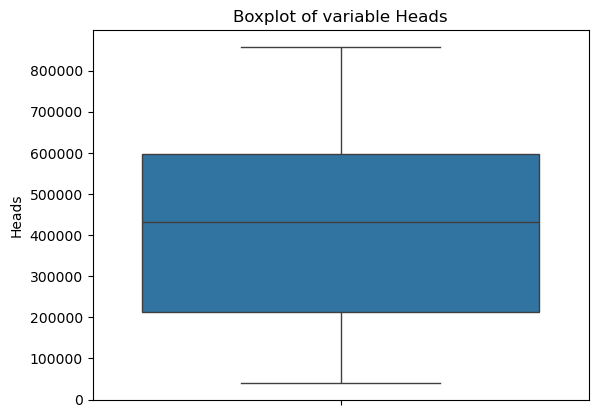

In [109]:
# creating boxplot for variable Heads
sns.boxplot(y = "Heads", data = df_cattle_exports)
plt.title("Boxplot of variable Heads")
plt.ylabel("Heads")
plt.show()

In [110]:
# calculating number of outliers
Q1 = df_cattle_exports["Heads"].quantile(0.25)
Q3 = df_cattle_exports["Heads"].quantile(0.75)
IQR = Q3 - Q1
outliers = df_cattle_exports[(df_cattle_exports["Heads"] < (Q1 - 1.5 * IQR)) | (df_cattle_exports["Heads"] > (Q3 + 1.5 * IQR))]
all_outliers = outliers.shape[0]
print("Total number of outliers:", all_outliers)

Total number of outliers: 0


This is finalised df_cattle_exports dataframe. Next same steps repeated to separate beef export data, measured in tonnes.

In [112]:
df_beef_exports = df_beef[df_beef["STATISTIC"] == "TSA04C2"]

In [113]:
df_beef_exports.head()

,STATISTIC,Statistic Label,Year,UNIT,VALUE
94,TSA04C2,Exports of Beef,1930,000 Tonnes,1.3
95,TSA04C2,Exports of Beef,1931,000 Tonnes,0.4
96,TSA04C2,Exports of Beef,1932,000 Tonnes,0.2
97,TSA04C2,Exports of Beef,1933,000 Tonnes,2.0
98,TSA04C2,Exports of Beef,1934,000 Tonnes,0.0


In [114]:
df_beef_exports["VALUE"] = df_beef_exports["VALUE"] * 1000

In [115]:
df_beef_exports.head()

,STATISTIC,Statistic Label,Year,UNIT,VALUE
94,TSA04C2,Exports of Beef,1930,000 Tonnes,1300.0
95,TSA04C2,Exports of Beef,1931,000 Tonnes,400.0
96,TSA04C2,Exports of Beef,1932,000 Tonnes,200.0
97,TSA04C2,Exports of Beef,1933,000 Tonnes,2000.0
98,TSA04C2,Exports of Beef,1934,000 Tonnes,0.0


In [116]:
df_beef_exports = df_beef_exports.drop(columns=["UNIT", "STATISTIC"])

In [117]:
# renaming the columns 
df_beef_exports.rename(columns={"VALUE": "Tonnes"}, inplace=True)

In [118]:
df_beef_exports["Tonnes"] = df_beef_exports["Tonnes"].astype(int)

In [119]:
df_beef_exports.head()

,Statistic Label,Year,Tonnes
94,Exports of Beef,1930,1300
95,Exports of Beef,1931,400
96,Exports of Beef,1932,200
97,Exports of Beef,1933,2000
98,Exports of Beef,1934,0


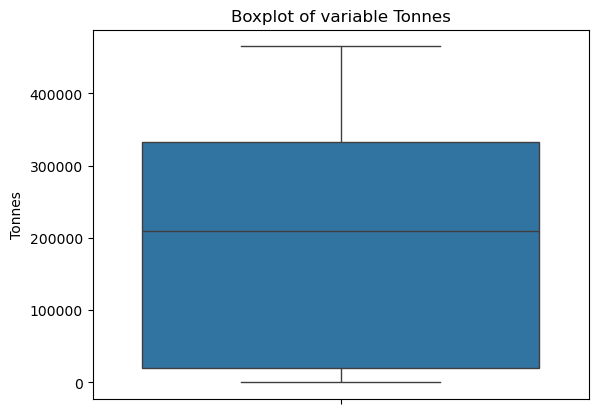

In [120]:
# creating boxplot for variable Tonnes
sns.boxplot(y = "Tonnes", data= df_beef_exports)
plt.title("Boxplot of variable Tonnes")
plt.ylabel("Tonnes")
plt.show()

In [121]:
# calculating number of outliers
Q1 = df_beef_exports["Tonnes"].quantile(0.25)
Q3 = df_beef_exports["Tonnes"].quantile(0.75)
IQR = Q3 - Q1
outliers = df_beef_exports[(df_beef_exports["Tonnes"] < (Q1 - 1.5 * IQR)) | (df_cattle_exports["Heads"] > (Q3 + 1.5 * IQR))]
all_outliers = outliers.shape[0]
print("Total number of outliers:", all_outliers)

Total number of outliers: 0


### Cleaning of df_EU_beef_exports dataframe

In [123]:
df_EU_beef_exports.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,TCL,Crops and livestock products,40,Austria,5922,Export value,21111.02,"Meat of cattle boneless, fresh or chilled",1961,1961,1000 USD,0,A,Official figure,NaN
1,TCL,Crops and livestock products,40,Austria,5922,Export value,21111.02,"Meat of cattle boneless, fresh or chilled",1962,1962,1000 USD,0,A,Official figure,NaN
2,TCL,Crops and livestock products,40,Austria,5922,Export value,21111.02,"Meat of cattle boneless, fresh or chilled",1963,1963,1000 USD,0,A,Official figure,NaN
3,TCL,Crops and livestock products,40,Austria,5922,Export value,21111.02,"Meat of cattle boneless, fresh or chilled",1964,1964,1000 USD,0,A,Official figure,NaN
4,TCL,Crops and livestock products,40,Austria,5922,Export value,21111.02,"Meat of cattle boneless, fresh or chilled",1965,1965,1000 USD,0,A,Official figure,NaN


In [124]:
df_EU_beef_exports.nunique()

Domain Code            1
Domain                 1
Area Code (M49)       27
Area                  27
Element Code           1
Element                1
Item Code (CPC)        1
Item                   1
Year Code             63
Year                  63
Unit                   1
Value               1015
Flag                   4
Flag Description       4
Note                   1
dtype: int64

In [125]:
df_EU_beef_exports["Area"].value_counts()

Area
Austria                         63
Germany                         63
Spain                           63
Romania                         63
Portugal                        63
Netherlands (Kingdom of the)    63
Malta                           63
Italy                           63
Hungary                         63
Greece                          63
Ireland                         63
France                          63
Finland                         63
Denmark                         63
Sweden                          63
Cyprus                          62
Latvia                          32
Poland                          32
Croatia                         32
Slovenia                        32
Estonia                         31
Czechia                         31
Slovakia                        31
Bulgaria                        31
Lithuania                       30
Belgium                         24
Luxembourg                      24
Name: count, dtype: int64

In [126]:
df_EU_beef_exports["Area"] = df_EU_beef_exports["Area"].replace(
    "Netherlands (Kingdom of the)", "Netherlands")


In [127]:
df_EU_beef_exports["Area"].value_counts()

Area
Austria        63
Germany        63
Spain          63
Romania        63
Portugal       63
Netherlands    63
Malta          63
Italy          63
Hungary        63
Greece         63
Ireland        63
France         63
Finland        63
Denmark        63
Sweden         63
Cyprus         62
Latvia         32
Poland         32
Croatia        32
Slovenia       32
Estonia        31
Czechia        31
Slovakia       31
Bulgaria       31
Lithuania      30
Belgium        24
Luxembourg     24
Name: count, dtype: int64

In [128]:
df_EU_beef_exports.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,TCL,Crops and livestock products,40,Austria,5922,Export value,21111.02,"Meat of cattle boneless, fresh or chilled",1961,1961,1000 USD,0,A,Official figure,NaN
1,TCL,Crops and livestock products,40,Austria,5922,Export value,21111.02,"Meat of cattle boneless, fresh or chilled",1962,1962,1000 USD,0,A,Official figure,NaN
2,TCL,Crops and livestock products,40,Austria,5922,Export value,21111.02,"Meat of cattle boneless, fresh or chilled",1963,1963,1000 USD,0,A,Official figure,NaN
3,TCL,Crops and livestock products,40,Austria,5922,Export value,21111.02,"Meat of cattle boneless, fresh or chilled",1964,1964,1000 USD,0,A,Official figure,NaN
4,TCL,Crops and livestock products,40,Austria,5922,Export value,21111.02,"Meat of cattle boneless, fresh or chilled",1965,1965,1000 USD,0,A,Official figure,NaN


In [129]:
df_EU_beef_exports["Value"] = df_EU_beef_exports["Value"] * 1000

In [130]:
df_EU_beef_exports = df_EU_beef_exports.drop(columns=["Domain Code", "Domain", "Unit", "Item Code (CPC)", "Element Code", "Element", "Year Code", "Note"])

In [131]:
df_EU_beef_exports.head()

,Area Code (M49),Area,Item,Year,Value,Flag,Flag Description
0,40,Austria,"Meat of cattle boneless, fresh or chilled",1961,0,A,Official figure
1,40,Austria,"Meat of cattle boneless, fresh or chilled",1962,0,A,Official figure
2,40,Austria,"Meat of cattle boneless, fresh or chilled",1963,0,A,Official figure
3,40,Austria,"Meat of cattle boneless, fresh or chilled",1964,0,A,Official figure
4,40,Austria,"Meat of cattle boneless, fresh or chilled",1965,0,A,Official figure


In [132]:
# renaming the columns 
df_EU_beef_exports.rename(columns={"Value": "Value (In USD)"}, inplace=True)

In [133]:
df_EU_beef_exports.nunique()

Area Code (M49)       27
Area                  27
Item                   1
Year                  63
Value (In USD)      1015
Flag                   4
Flag Description       4
dtype: int64

In [134]:
df_EU_beef_exports["Flag"].value_counts()

Flag
A    1323
E       7
I       4
X       3
Name: count, dtype: int64

In [135]:
df_EU_beef_exports["Flag Description"].value_counts()

Flag Description
Official figure                            1323
Estimated value                               7
Imputed value                                 4
Figure from international organizations       3
Name: count, dtype: int64

In [136]:
df_EU_beef_exports["Area"].value_counts()

Area
Austria        63
Germany        63
Spain          63
Romania        63
Portugal       63
Netherlands    63
Malta          63
Italy          63
Hungary        63
Greece         63
Ireland        63
France         63
Finland        63
Denmark        63
Sweden         63
Cyprus         62
Latvia         32
Poland         32
Croatia        32
Slovenia       32
Estonia        31
Czechia        31
Slovakia       31
Bulgaria       31
Lithuania      30
Belgium        24
Luxembourg     24
Name: count, dtype: int64

In [137]:
df_EU_beef_export_volumes.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,TCL,Crops and livestock products,40,Austria,5910,Export quantity,21111.02,"Meat of cattle boneless, fresh or chilled",1961,1961,t,0.0,A,Official figure,NaN
1,TCL,Crops and livestock products,40,Austria,5910,Export quantity,21111.02,"Meat of cattle boneless, fresh or chilled",1962,1962,t,0.0,A,Official figure,NaN
2,TCL,Crops and livestock products,40,Austria,5910,Export quantity,21111.02,"Meat of cattle boneless, fresh or chilled",1963,1963,t,0.0,A,Official figure,NaN
3,TCL,Crops and livestock products,40,Austria,5910,Export quantity,21111.02,"Meat of cattle boneless, fresh or chilled",1964,1964,t,0.0,A,Official figure,NaN
4,TCL,Crops and livestock products,40,Austria,5910,Export quantity,21111.02,"Meat of cattle boneless, fresh or chilled",1965,1965,t,0.0,A,Official figure,NaN


In [138]:
# renaming the columns 
df_EU_beef_export_volumes.rename(columns={"Value": "Tonnes"}, inplace=True)

In [139]:
df_EU_beef_export_volumes = df_EU_beef_export_volumes.drop(columns=["Domain Code", "Domain", "Unit", "Item Code (CPC)", "Element Code", "Element", "Year Code", "Note"])

In [140]:
df_EU_beef_export_volumes.head()

,Area Code (M49),Area,Item,Year,Tonnes,Flag,Flag Description
0,40,Austria,"Meat of cattle boneless, fresh or chilled",1961,0.0,A,Official figure
1,40,Austria,"Meat of cattle boneless, fresh or chilled",1962,0.0,A,Official figure
2,40,Austria,"Meat of cattle boneless, fresh or chilled",1963,0.0,A,Official figure
3,40,Austria,"Meat of cattle boneless, fresh or chilled",1964,0.0,A,Official figure
4,40,Austria,"Meat of cattle boneless, fresh or chilled",1965,0.0,A,Official figure


In [141]:
df_EU_beef_export_volumes["Area"] = df_EU_beef_export_volumes["Area"].replace(
    "Netherlands (Kingdom of the)", "Netherlands")

### Cleaning of df_population dataframe

In [143]:
df_population.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,58694.0,58990.0,59069.0,59052.0,58950.0,58781.0,58047.0,58299.0,58349.0,58295.0,58368.0,58580.0,58776.0,59191.0,59909.0,60563.0,61276.0,62228.0,62901.0,61728.0,59931.0,59159.0,59331.0,60443.0,62753.0,65896.0,69005.0,73685.0,77595.0,79805.0,83021.0,86301.0,88451.0,89659.0,90588.0,91439.0,92074.0,93128.0,95138.0,97635.0,99405.0,100150.0,100917.0,101604.0,101838.0,102591.0,104110.0,105675.0,106807.0,107906.0,108727.0,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130072080.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,153281203.0,157704381.0,162329396.0,167088245.0,171984985.0,177022314.0,182126556.0,187524135.0,193186642.0,198914573.0,204802976.0,210680842.0,217074286.0,223974122.0,230792729.0,238043099.0,245822010.0,253644643.0,261458202.0,269450407.0,277621771.0,286067346.0,294498625.0,302939121.0,311748681.0,320442961.0,329082707.0,338324002.0,347441809.0,356580375.0,366138524.0,375646235.0,385505757.0,395750933.0,406156661.0,416807868.0,427820358.0,439173286.0,450928044.0,463076637.0,475606210.0,488580707.0,502070763.0,516003448.0,530308387.0,544737983.0,559609961.0,575202699.0,590968990.0,607123269.0,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750503764.0
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,10266395.0,10505959.0,10756922.0,11017409.0,11290128.0,11567667.0,11853696.0,12157999.0,12469127.0,12773954.0,13059851.0,13340756.0,13611441.0,13655567.0,13169311.0,11937581.0,10991378.0,10917982.0,11190221.0,11426852.0,11420074.0,11387818.0,11523298.0,11874088.0,12045660.0,12238879.0,13278974.0,14943172.0,16250794.0,17065836.0,17763266.0,18452091.0,19159996.0,19887785.0,20130327.0,20284307.0,21378117.0,22733049.0,23560654.0,24404567.0,25424094.0,25909852.0,26482622.0,27466101.0,28284089.0,29347708.0,30560034.0,31622704.0,32792523.0,33831764.0,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,111246953.0,113795019.0,116444636.0,119203521.0,122086536.0,125072948.0,128176494.0,131449942.0,134911581.0,138569918.0,142337272.0,146258576.0,150402616.0,154721711.0,159166518.0,163762473.0,168585118.0,173255157.0,177880746.0,182811038.0,187889141.0,193104347.0,198485027.0,204062274.0,209566031.0,215178709.0,221191375.0,227246778.0,233360104.0,239801875.0,246415446.0,253207584.0,260297834.0,267506298.0,274968446.0,282780717.0,290841795.0,299142845.0,307725100.0,316588476.0,325663158.0,334984176.0,344586109.0,354343844.0,364358270.0,374790143.0,385360349.0,396030207.0,406992047.0,418127845.0,429454743.0,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,5581386.0,5641807.0,5702699.0,5763685.0,5852788.0,5991102.0,6174262.0,6388528.0,6613367.0,6842947.0,7074664.0,7317829.0,7576734.0,7847207.0,8133872.0,8435607.0,8751648.0,9082983.0,9425917.0,9779120.0,10139450.0,10497858.0,10861291.0,11238562.0,11626360.0,12023529.0,12423712.0,12827135.0,13249764.0,13699778.0,14170973.0,14660413.0,15159370.0,15667235.0,16194869.0,16747208.0,17327699.0,17943712.0,18600423.0,19291161.0,20015279.0,20778561.0,21578655.0,22414773.0,23294825.0,24218352.0,25177394.0,26165620.0,27160769.0,28157798.0,2

In [144]:
df_population.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023'],
      dtype='object')

In [145]:
df_population.shape

(266, 68)

In [146]:
eu_countries = [
    "Austria", "Belgium", "Bulgaria", "Croatia", "Cyprus", "Czechia", 
    "Denmark", "Estonia", "Finland", "France", "Germany", "Greece", "Hungary", 
    "Ireland", "Italy", "Latvia", "Lithuania", "Luxembourg", "Malta", 
    "Netherlands", "Poland", "Portugal", "Romania", "Slovak Republic", 
    "Slovenia", "Spain", "Sweden"
]

In [147]:
df_EU_population = df_population[df_population["Country Name"].isin(eu_countries)]

In [148]:
df_EU_population.head(27)

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
14,Austria,AUT,"Population, total",SP.POP.TOTL,7047539.0,7086299.0,7129864.0,7175811.0,7223801.0,7270889.0,7322066.0,7376998.0,7415403.0,7441055.0,7467086.0,7500482.0,7544201.0,7586115.0,7599038.0,7578903.0,7565525.0,7568430.0,7562305.0,7549425.0,7549433.0,7568710.0,7574140.0,7561910.0,7561434.0,7564985.0,7569794.0,7574586.0,7585317.0,7619567.0,7677850.0,7754891.0,7840709.0,7905633.0,7936118.0,7948278.0,7959017.0,7968041.0,7976789.0,7992324.0,8011566.0,8042293.0,8081957.0,8121423.0,8171966.0,8227829.0,8268641.0,8295487.0,8321496.0,8343323.0,8363404.0,8391643.0,8429991.0,8479823.0,8546356.0,8642699.0,8736668.0,8797566.0,8840521.0,8879920.0,8916864.0,8955797.0,9041851.0,9131761.0
17,Belgium,BEL,"Population, total",SP.POP.TOTL,9153489.0,9183948.0,9220578.0,9289770.0,9378113.0,9463667.0,9527807.0,9580991.0,9618756.0,9646032.0,9655549.0,9673162.0,9711115.0,9741720.0,9772419.0,9800700.0,9818227.0,9830358.0,9839534.0,9848382.0,9859242.0,9858982.0,9856303.0,9855520.0,9855372.0,9858308.0,9861823.0,9870234.0,9901664.0,9937697.0,9967379.0,10004486.0,10045158.0,10084475.0,10115603.0,10136811.0,10156637.0,10181245.0,10203008.0,10226419.0,10251250.0,10286570.0,10332785.0,10376133.0,10421137.0,10478617.0,10547958.0,10625700.0,10709973.0,10796493.0,10895586.0,11038264.0,11106932.0,11159407.0,11209057.0,11274196.0,11331422.0,11375158.0,11427054.0,11488980.0,11538604.0,11586195.0,11680210.0,11787423.0
21,Bulgaria,BGR,"Population, total",SP.POP.TOTL,7867374.0,7943118.0,8012946.0,8078145.0,8144340.0,8204168.0,8258057.0,8310226.0,8369603.0,8434172.0,8489574.0,8536395.0,8576200.0,8620967.0,8678745.0,8720742.0,8758599.0,8804183.0,8814032.0,8825940.0,8861535.0,8891117.0,8917457.0,8939738.0,8960679.0,8960547.0,8958171.0,8971359.0,8981446.0,8876972.0,8718289.0,8632367.0,8540164.0,8472313.0,8443591.0,8406067.0,8362826.0,8312068.0,8256786.0,8210624.0,8170172.0,8009142.0,7837161.0,7775327.0,7716860.0,7658972.0,7601022.0,7545338.0,7492561.0,7444443.0,7395599.0,7348328.0,7305888.0,7265115.0,7223938.0,7177991.0,7127822.0,7075947.0,7025037.0,6975761.0,6934015.0,6877743.0,6643324.0,6446596.0
53,Cyprus,CYP,"Population, total",SP.POP.TOTL,586490.0,595514.0,601466.0,607252.0,612521.0,617736.0,623390.0,629251.0,635157.0,641189.0,647446.0,654050.0,661063.0,665937.0,663254.0,659405.0,662032.0,667101.0,672249.0,677549.0,683076.0,688893.0,696497.0,707225.0,719334.0,731277.0,743105.0,754785.0,766235.0,777420.0,788351.0,798944.0,810341.0,826034.0,844667.0,862695.0,880290.0,897568.0,914548.0,931234.0,947667.0,964127.0,981440.0,999590.0,1017875.0,1036151.0,1054418.0,1072714.0,1091026.0,1109371.0,1127816.0,1146493.0,1165397.0,1183895.0,1201801.0,1219502.0,1237112.0,1254275.0,1270737.0,1286671.0,1302247.0,1317309.0,1331370.0,1344976.0
54,Czechia,CZE,"Population, total",SP.POP.TOTL,9602006.0,9586651.0,9624660.0,9670685.0,9727804.0,9779358.0,9821040.0,9852899.0,9876346.0,9896580.0,9858071.0,9826815.0,9867632.0,9922266.0,9988459.0,10058620.0,10125939.0,10186755.0,10242098.0,10292341.0,10304193.0,10300591.0,10314826.0,10323856.0,10330213.0,10337118.0,10342227.0,10347318.0,10355276.0,10361068.0,10333355.0,10308578.0,10319123.0,10329855.0,10333587.0,10327253.0,10315241.0,10304131.0,10294373.0,10283860.0,10255063.0,10216605.0,10196916.0,10193998.0,10197101.0,10211216.0,10238905.0,10298828.0,10384603.0,10443936.0,10474410.0,10496088.0,10510785.0,10514272.0,10525347.0,10546059.0,10566332.0,10594438.0,10629928.0,10671870.0,10697858.0,10505772.0,10672118.0,10864042.0
55,Germany,DEU,"Population, total",SP.POP.TOTL,72814900.0,73377632.0,74025784.0,74714353.0,75318337.0,75963695.0,76600311.0,76951336.0,77294314.0,7790

### Cleaning of df_wordwide dataframe

In [150]:
df_worldwide.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,TCL,Crops and livestock products,4,Afghanistan,5910,Export quantity,21111.02,"Meat of cattle boneless, fresh or chilled",2020,2020,t,0.13,X,Figure from international organizations,Estimated data using trading partners database
1,TCL,Crops and livestock products,4,Afghanistan,5910,Export quantity,21111.02,"Meat of cattle boneless, fresh or chilled",2021,2021,t,12.96,X,Figure from international organizations,Estimated data using trading partners database
2,TCL,Crops and livestock products,4,Afghanistan,5910,Export quantity,21111.02,"Meat of cattle boneless, fresh or chilled",2023,2023,t,0.47,X,Figure from international organizations,Estimated data using trading partners database
3,TCL,Crops and livestock products,4,Afghanistan,5910,Export quantity,21111.01,"Meat of cattle with the bone, fresh or chilled",2021,2021,t,0.05,X,Figure from international organizations,Estimated data using trading partners database
4,TCL,Crops and livestock products,4,Afghanistan,5910,Export quantity,21111.01,"Meat of cattle with the bone, fresh or chilled",2023,2023,t,0.22,X,Figure from international organizations,Estimated data using trading partners database


In [151]:
df_worldwide["Value"] = df_worldwide["Value"] * 1000

In [152]:
df_worldwide.columns

Index(['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code',
       'Element', 'Item Code (CPC)', 'Item', 'Year Code', 'Year', 'Unit',
       'Value', 'Flag', 'Flag Description', 'Note'],
      dtype='object')

In [153]:
# renaming the columns 
df_worldwide.rename(columns={"Value": "Tonnes"}, inplace=True)

In [154]:
df_worldwide = df_worldwide.drop(columns=["Domain Code", "Domain", "Area Code (M49)", "Unit", "Item Code (CPC)", "Item", 
                                                                    "Element Code", "Flag", "Flag Description", "Element", "Year Code", "Note"])

In [155]:
df_worldwide.head()

,Area,Year,Tonnes
0,Afghanistan,2020,130.0
1,Afghanistan,2021,12960.0
2,Afghanistan,2023,470.0
3,Afghanistan,2021,50.0
4,Afghanistan,2023,220.0


In [156]:
df_worldwide_value.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,TCL,Crops and livestock products,4,Afghanistan,5922,Export value,21111.02,"Meat of cattle boneless, fresh or chilled",2020,2020,1000 USD,1,X,Figure from international organizations,Estimated data using trading partners database
1,TCL,Crops and livestock products,4,Afghanistan,5922,Export value,21111.02,"Meat of cattle boneless, fresh or chilled",2021,2021,1000 USD,41,X,Figure from international organizations,Estimated data using trading partners database
2,TCL,Crops and livestock products,4,Afghanistan,5922,Export value,21111.02,"Meat of cattle boneless, fresh or chilled",2023,2023,1000 USD,2,X,Figure from international organizations,Estimated data using trading partners database
3,TCL,Crops and livestock products,4,Afghanistan,5922,Export value,21111.01,"Meat of cattle with the bone, fresh or chilled",2021,2021,1000 USD,4,X,Figure from international organizations,Estimated data using trading partners database
4,TCL,Crops and livestock products,4,Afghanistan,5922,Export value,21111.01,"Meat of cattle with the bone, fresh or chilled",2023,2023,1000 USD,1,X,Figure from international organizations,Estimated data using trading partners database


In [157]:
df_worldwide_value["Value"] = df_worldwide_value["Value"] * 1000

In [158]:
# renaming the columns 
df_worldwide_value.rename(columns={"Value": "Value in USD"}, inplace=True)

In [159]:
# dropping unnessesary columns
df_worldwide_value = df_worldwide_value.drop(columns=["Domain Code", "Domain", "Area Code (M49)", "Unit", "Item Code (CPC)", "Item", 
                                                                    "Element Code", "Flag", "Flag Description", "Element", "Year Code", "Note"])

In [160]:
# calling the dataframe
df_worldwide_value.head()

,Area,Year,Value in USD
0,Afghanistan,2020,1000
1,Afghanistan,2021,41000
2,Afghanistan,2023,2000
3,Afghanistan,2021,4000
4,Afghanistan,2023,1000


### Cleaning of df_reddit dataframe

In [162]:
df_reddit.head()

,Author,Comment
0,AutoModerator,"**Please help keep AskUK welcoming!**\n\n- Top-level comments to the OP must contain **genuine efforts to answer the question**. No jokes, judgements, etc.\n\n- **Don't be a dick** to each other. If getting heated, just block and move on.\n\n- This is a strictly **no-politics** subreddit!\n \nPlease help us by reporting comments that break these rules.\n\n*I am a bot, and this action was performed automatically. Please [contact the moderators of this subreddit](/message/compose/?to=/r/AskUK) if you have any questions or concerns.*"
1,boldstrategy,"One is from Britain, and one is from Ireland"
2,BrunniFlat7,Before they are slaughtered the British Beef makes a Mooing sound the Irish Beef cows make a distinctive Mo'Oing sound.
3,YchYFi,"These 🐄 🇬🇧 are small, but those 🐄 🇮🇪 are far away... Small, far away."
4,Tennents-Shagger,Depends what you mean by historical beef


As allready determined by EDA, dataset contains missing values in Author variable, but this variable won't be needed for Sentiment Analysis, therefore can be dropped altogether.

In [164]:
df_reddit = df_reddit.drop(columns=["Author"])

In [165]:
df_reddit.head()

,Comment
0,"**Please help keep AskUK welcoming!**\n\n- Top-level comments to the OP must contain **genuine efforts to answer the question**. No jokes, judgements, etc.\n\n- **Don't be a dick** to each other. If getting heated, just block and move on.\n\n- This is a strictly **no-politics** subreddit!\n \nPlease help us by reporting comments that break these rules.\n\n*I am a bot, and this action was performed automatically. Please [contact the moderators of this subreddit](/message/compose/?to=/r/AskUK) if you have any questions or concerns.*"
1,"One is from Britain, and one is from Ireland"
2,Before they are slaughtered the British Beef makes a Mooing sound the Irish Beef cows make a distinctive Mo'Oing sound.
3,"These 🐄 🇬🇧 are small, but those 🐄 🇮🇪 are far away... Small, far away."
4,Depends what you mean by historical beef


Although variable Column contains no missing values, so comment are removed from discussion, therefore provide no value to the dataframe. These rows can be deleted from the dataframe.

In [167]:
df_reddit.head()

,Comment
0,"**Please help keep AskUK welcoming!**\n\n- Top-level comments to the OP must contain **genuine efforts to answer the question**. No jokes, judgements, etc.\n\n- **Don't be a dick** to each other. If getting heated, just block and move on.\n\n- This is a strictly **no-politics** subreddit!\n \nPlease help us by reporting comments that break these rules.\n\n*I am a bot, and this action was performed automatically. Please [contact the moderators of this subreddit](/message/compose/?to=/r/AskUK) if you have any questions or concerns.*"
1,"One is from Britain, and one is from Ireland"
2,Before they are slaughtered the British Beef makes a Mooing sound the Irish Beef cows make a distinctive Mo'Oing sound.
3,"These 🐄 🇬🇧 are small, but those 🐄 🇮🇪 are far away... Small, far away."
4,Depends what you mean by historical beef


In [168]:
df_reddit.shape

(160, 1)

In [169]:
df_reddit.tail()

,Comment
155,[removed]
156,[removed]
157,[deleted]
158,[removed]
159,"On a shelf alongside Welsh beef, Scottish beef, English beef - sure: I could understand why beef from Northern Ireland was labelled Northern Irish beef. Otherwise I'd wonder why the producers were claiming it had been reared to different set of standards and under a different legislature than it really was."


There are URL's in the text. Before proceding they also are removed.

In [171]:
# function to remove URLs from text
def remove_urls(text):
    url_pattern = re.compile(r"http\S+|www\.\S+")  
    return url_pattern.sub(r"", str(text))  
df_reddit["Comment"] = df_reddit["Comment"].apply(remove_urls)

In [172]:
df_reddit.tail()

,Comment
155,[removed]
156,[removed]
157,[deleted]
158,[removed]
159,"On a shelf alongside Welsh beef, Scottish beef, English beef - sure: I could understand why beef from Northern Ireland was labelled Northern Irish beef. Otherwise I'd wonder why the producers were claiming it had been reared to different set of standards and under a different legislature than it really was."


In [173]:
df_reddit = df_reddit[df_reddit["Comment"].str.strip() != ""]
df_reddit = df_reddit[df_reddit["Comment"] != "[removed]"]
df_reddit = df_reddit[df_reddit["Comment"] != "[deleted]"]
df_reddit = df_reddit.drop(index=0)

In [174]:
df_reddit.tail()

,Comment
151,🤣
152,Tell that to English football fans.
153,"No hate here dude, just facts. It's called British because it's British. Whether it should be British, or will remain British in the future is a whole other conversation.\n\nAnyway, my ancestors didn't colonise anything, and I've not claimed anywhere that it is somehow ""mine"" - besides: you have literally no idea where I grew up.\n\n>But to think that you imagined\n\nThe only imagination running here is yours, but I agree: thinking something in someone else's head is very strange."
154,Yep absolutely… I was trying to make a pun from mouthful but obviously didn’t land! :)
159,"On a shelf alongside Welsh beef, Scottish beef, English beef - sure: I could understand why beef from Northern Ireland was labelled Northern Irish beef. Otherwise I'd wonder why the producers were claiming it had been reared to different set of standards and under a different legislature than it really was."


<span style="color: blue;">

## 2.3. Data Wrangling and Feature Engineering <a class="anchor" id="ninth-bullet"></a>
    
</span>

For the next steps, 3 dataframes will be taken - df_EU_beef_exports, df_EU_beef_export_volumes and df_population and merged together. Unnessesary columns will be deleted

In [177]:
df_EU_beef_exports.head()

,Area Code (M49),Area,Item,Year,Value (In USD),Flag,Flag Description
0,40,Austria,"Meat of cattle boneless, fresh or chilled",1961,0,A,Official figure
1,40,Austria,"Meat of cattle boneless, fresh or chilled",1962,0,A,Official figure
2,40,Austria,"Meat of cattle boneless, fresh or chilled",1963,0,A,Official figure
3,40,Austria,"Meat of cattle boneless, fresh or chilled",1964,0,A,Official figure
4,40,Austria,"Meat of cattle boneless, fresh or chilled",1965,0,A,Official figure


In [178]:
df_EU_beef_export_volumes.head()

,Area Code (M49),Area,Item,Year,Tonnes,Flag,Flag Description
0,40,Austria,"Meat of cattle boneless, fresh or chilled",1961,0.0,A,Official figure
1,40,Austria,"Meat of cattle boneless, fresh or chilled",1962,0.0,A,Official figure
2,40,Austria,"Meat of cattle boneless, fresh or chilled",1963,0.0,A,Official figure
3,40,Austria,"Meat of cattle boneless, fresh or chilled",1964,0.0,A,Official figure
4,40,Austria,"Meat of cattle boneless, fresh or chilled",1965,0.0,A,Official figure


In [179]:
# merging the dataframes on suited columns
df_EU_exports_merged = pd.merge(
    df_EU_beef_exports, 
    df_EU_beef_export_volumes, 
    on=["Area Code (M49)", "Area", "Item", "Year", "Flag", "Flag Description"], 
    how="inner"
)

In [180]:
# checking how it merged
df_EU_exports_merged.head()

,Area Code (M49),Area,Item,Year,Value (In USD),Flag,Flag Description,Tonnes
0,40,Austria,"Meat of cattle boneless, fresh or chilled",1961,0,A,Official figure,0.0
1,40,Austria,"Meat of cattle boneless, fresh or chilled",1962,0,A,Official figure,0.0
2,40,Austria,"Meat of cattle boneless, fresh or chilled",1963,0,A,Official figure,0.0
3,40,Austria,"Meat of cattle boneless, fresh or chilled",1964,0,A,Official figure,0.0
4,40,Austria,"Meat of cattle boneless, fresh or chilled",1965,0,A,Official figure,0.0


As there are variables Value (In USD) and Tonnes in the dataframe, it enable to create new variable Price per Tonne. 

In [182]:
# creatting new variable
df_EU_exports_merged[("Price per Tonne")] = df_EU_exports_merged[("Value (In USD)")] / df_EU_exports_merged[("Tonnes")]

In [183]:
# changing the columns order
new_order = ["Area Code (M49)", "Area", "Item", "Year", "Value (In USD)", "Tonnes", "Price per Tonne", "Flag", "Flag Description"]

df_EU_exports_merged = df_EU_exports_merged[new_order]

In [184]:
df_EU_exports_merged.head()

,Area Code (M49),Area,Item,Year,Value (In USD),Tonnes,Price per Tonne,Flag,Flag Description
0,40,Austria,"Meat of cattle boneless, fresh or chilled",1961,0,0.0,NaN,A,Official figure
1,40,Austria,"Meat of cattle boneless, fresh or chilled",1962,0,0.0,NaN,A,Official figure
2,40,Austria,"Meat of cattle boneless, fresh or chilled",1963,0,0.0,NaN,A,Official figure
3,40,Austria,"Meat of cattle boneless, fresh or chilled",1964,0,0.0,NaN,A,Official figure
4,40,Austria,"Meat of cattle boneless, fresh or chilled",1965,0,0.0,NaN,A,Official figure


In [185]:
df_EU_population.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
14,Austria,AUT,"Population, total",SP.POP.TOTL,7047539.0,7086299.0,7129864.0,7175811.0,7223801.0,7270889.0,7322066.0,7376998.0,7415403.0,7441055.0,7467086.0,7500482.0,7544201.0,7586115.0,7599038.0,7578903.0,7565525.0,7568430.0,7562305.0,7549425.0,7549433.0,7568710.0,7574140.0,7561910.0,7561434.0,7564985.0,7569794.0,7574586.0,7585317.0,7619567.0,7677850.0,7754891.0,7840709.0,7905633.0,7936118.0,7948278.0,7959017.0,7968041.0,7976789.0,7992324.0,8011566.0,8042293.0,8081957.0,8121423.0,8171966.0,8227829.0,8268641.0,8295487.0,8321496.0,8343323.0,8363404.0,8391643.0,8429991.0,8479823.0,8546356.0,8642699.0,8736668.0,8797566.0,8840521.0,8879920.0,8916864.0,8955797.0,9041851.0,9131761.0
17,Belgium,BEL,"Population, total",SP.POP.TOTL,9153489.0,9183948.0,9220578.0,9289770.0,9378113.0,9463667.0,9527807.0,9580991.0,9618756.0,9646032.0,9655549.0,9673162.0,9711115.0,9741720.0,9772419.0,9800700.0,9818227.0,9830358.0,9839534.0,9848382.0,9859242.0,9858982.0,9856303.0,9855520.0,9855372.0,9858308.0,9861823.0,9870234.0,9901664.0,9937697.0,9967379.0,10004486.0,10045158.0,10084475.0,10115603.0,10136811.0,10156637.0,10181245.0,10203008.0,10226419.0,10251250.0,10286570.0,10332785.0,10376133.0,10421137.0,10478617.0,10547958.0,10625700.0,10709973.0,10796493.0,10895586.0,11038264.0,11106932.0,11159407.0,11209057.0,11274196.0,11331422.0,11375158.0,11427054.0,11488980.0,11538604.0,11586195.0,11680210.0,11787423.0
21,Bulgaria,BGR,"Population, total",SP.POP.TOTL,7867374.0,7943118.0,8012946.0,8078145.0,8144340.0,8204168.0,8258057.0,8310226.0,8369603.0,8434172.0,8489574.0,8536395.0,8576200.0,8620967.0,8678745.0,8720742.0,8758599.0,8804183.0,8814032.0,8825940.0,8861535.0,8891117.0,8917457.0,8939738.0,8960679.0,8960547.0,8958171.0,8971359.0,8981446.0,8876972.0,8718289.0,8632367.0,8540164.0,8472313.0,8443591.0,8406067.0,8362826.0,8312068.0,8256786.0,8210624.0,8170172.0,8009142.0,7837161.0,7775327.0,7716860.0,7658972.0,7601022.0,7545338.0,7492561.0,7444443.0,7395599.0,7348328.0,7305888.0,7265115.0,7223938.0,7177991.0,7127822.0,7075947.0,7025037.0,6975761.0,6934015.0,6877743.0,6643324.0,6446596.0
53,Cyprus,CYP,"Population, total",SP.POP.TOTL,586490.0,595514.0,601466.0,607252.0,612521.0,617736.0,623390.0,629251.0,635157.0,641189.0,647446.0,654050.0,661063.0,665937.0,663254.0,659405.0,662032.0,667101.0,672249.0,677549.0,683076.0,688893.0,696497.0,707225.0,719334.0,731277.0,743105.0,754785.0,766235.0,777420.0,788351.0,798944.0,810341.0,826034.0,844667.0,862695.0,880290.0,897568.0,914548.0,931234.0,947667.0,964127.0,981440.0,999590.0,1017875.0,1036151.0,1054418.0,1072714.0,1091026.0,1109371.0,1127816.0,1146493.0,1165397.0,1183895.0,1201801.0,1219502.0,1237112.0,1254275.0,1270737.0,1286671.0,1302247.0,1317309.0,1331370.0,1344976.0
54,Czechia,CZE,"Population, total",SP.POP.TOTL,9602006.0,9586651.0,9624660.0,9670685.0,9727804.0,9779358.0,9821040.0,9852899.0,9876346.0,9896580.0,9858071.0,9826815.0,9867632.0,9922266.0,9988459.0,10058620.0,10125939.0,10186755.0,10242098.0,10292341.0,10304193.0,10300591.0,10314826.0,10323856.0,10330213.0,10337118.0,10342227.0,10347318.0,10355276.0,10361068.0,10333355.0,10308578.0,10319123.0,10329855.0,10333587.0,10327253.0,10315241.0,10304131.0,10294373.0,10283860.0,10255063.0,10216605.0,10196916.0,10193998.0,10197101.0,10211216.0,10238905.0,10298828.0,10384603.0,10443936.0,10474410.0,10496088.0,10510785.0,10514272.0,10525347.0,10546059.0,10566332.0,10594438.0,10629928.0,10671870.0,10697858.0,10505772.0,10672118.0,10864042.0


In [186]:
# changing the value for Slovakia, so they can be merged
df_EU_population["Country Name"] = df_EU_population["Country Name"].replace(
    "Slovak Republic", "Slovakia")

In [187]:
# dropping unnesessary columns
df_EU_population = df_EU_population.drop(columns=["Country Code", "Indicator Name", "Indicator Code"])
df_EU_exports_merged = df_EU_exports_merged.drop(columns=["Area Code (M49)"])

In [188]:
# renaming the columns 
df_EU_population.rename(columns={"Country Name": "Area"}, inplace=True)

Calling again two dataframes before merging them.

In [190]:
df_EU_population.head()

,Area,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
14,Austria,7047539.0,7086299.0,7129864.0,7175811.0,7223801.0,7270889.0,7322066.0,7376998.0,7415403.0,7441055.0,7467086.0,7500482.0,7544201.0,7586115.0,7599038.0,7578903.0,7565525.0,7568430.0,7562305.0,7549425.0,7549433.0,7568710.0,7574140.0,7561910.0,7561434.0,7564985.0,7569794.0,7574586.0,7585317.0,7619567.0,7677850.0,7754891.0,7840709.0,7905633.0,7936118.0,7948278.0,7959017.0,7968041.0,7976789.0,7992324.0,8011566.0,8042293.0,8081957.0,8121423.0,8171966.0,8227829.0,8268641.0,8295487.0,8321496.0,8343323.0,8363404.0,8391643.0,8429991.0,8479823.0,8546356.0,8642699.0,8736668.0,8797566.0,8840521.0,8879920.0,8916864.0,8955797.0,9041851.0,9131761.0
17,Belgium,9153489.0,9183948.0,9220578.0,9289770.0,9378113.0,9463667.0,9527807.0,9580991.0,9618756.0,9646032.0,9655549.0,9673162.0,9711115.0,9741720.0,9772419.0,9800700.0,9818227.0,9830358.0,9839534.0,9848382.0,9859242.0,9858982.0,9856303.0,9855520.0,9855372.0,9858308.0,9861823.0,9870234.0,9901664.0,9937697.0,9967379.0,10004486.0,10045158.0,10084475.0,10115603.0,10136811.0,10156637.0,10181245.0,10203008.0,10226419.0,10251250.0,10286570.0,10332785.0,10376133.0,10421137.0,10478617.0,10547958.0,10625700.0,10709973.0,10796493.0,10895586.0,11038264.0,11106932.0,11159407.0,11209057.0,11274196.0,11331422.0,11375158.0,11427054.0,11488980.0,11538604.0,11586195.0,11680210.0,11787423.0
21,Bulgaria,7867374.0,7943118.0,8012946.0,8078145.0,8144340.0,8204168.0,8258057.0,8310226.0,8369603.0,8434172.0,8489574.0,8536395.0,8576200.0,8620967.0,8678745.0,8720742.0,8758599.0,8804183.0,8814032.0,8825940.0,8861535.0,8891117.0,8917457.0,8939738.0,8960679.0,8960547.0,8958171.0,8971359.0,8981446.0,8876972.0,8718289.0,8632367.0,8540164.0,8472313.0,8443591.0,8406067.0,8362826.0,8312068.0,8256786.0,8210624.0,8170172.0,8009142.0,7837161.0,7775327.0,7716860.0,7658972.0,7601022.0,7545338.0,7492561.0,7444443.0,7395599.0,7348328.0,7305888.0,7265115.0,7223938.0,7177991.0,7127822.0,7075947.0,7025037.0,6975761.0,6934015.0,6877743.0,6643324.0,6446596.0
53,Cyprus,586490.0,595514.0,601466.0,607252.0,612521.0,617736.0,623390.0,629251.0,635157.0,641189.0,647446.0,654050.0,661063.0,665937.0,663254.0,659405.0,662032.0,667101.0,672249.0,677549.0,683076.0,688893.0,696497.0,707225.0,719334.0,731277.0,743105.0,754785.0,766235.0,777420.0,788351.0,798944.0,810341.0,826034.0,844667.0,862695.0,880290.0,897568.0,914548.0,931234.0,947667.0,964127.0,981440.0,999590.0,1017875.0,1036151.0,1054418.0,1072714.0,1091026.0,1109371.0,1127816.0,1146493.0,1165397.0,1183895.0,1201801.0,1219502.0,1237112.0,1254275.0,1270737.0,1286671.0,1302247.0,1317309.0,1331370.0,1344976.0
54,Czechia,9602006.0,9586651.0,9624660.0,9670685.0,9727804.0,9779358.0,9821040.0,9852899.0,9876346.0,9896580.0,9858071.0,9826815.0,9867632.0,9922266.0,9988459.0,10058620.0,10125939.0,10186755.0,10242098.0,10292341.0,10304193.0,10300591.0,10314826.0,10323856.0,10330213.0,10337118.0,10342227.0,10347318.0,10355276.0,10361068.0,10333355.0,10308578.0,10319123.0,10329855.0,10333587.0,10327253.0,10315241.0,10304131.0,10294373.0,10283860.0,10255063.0,10216605.0,10196916.0,10193998.0,10197101.0,10211216.0,10238905.0,10298828.0,10384603.0,10443936.0,10474410.0,10496088.0,10510785.0,10514272.0,10525347.0,10546059.0,10566332.0,10594438.0,10629928.0,10671870.0,10697858.0,10505772.0,10672118.0,10864042.0


In [191]:
df_EU_exports_merged.head()

,Area,Item,Year,Value (In USD),Tonnes,Price per Tonne,Flag,Flag Description
0,Austria,"Meat of cattle boneless, fresh or chilled",1961,0,0.0,NaN,A,Official figure
1,Austria,"Meat of cattle boneless, fresh or chilled",1962,0,0.0,NaN,A,Official figure
2,Austria,"Meat of cattle boneless, fresh or chilled",1963,0,0.0,NaN,A,Official figure
3,Austria,"Meat of cattle boneless, fresh or chilled",1964,0,0.0,NaN,A,Official figure
4,Austria,"Meat of cattle boneless, fresh or chilled",1965,0,0.0,NaN,A,Official figure


In [192]:
# melting dataframe for easier merging
df_population_melted = df_EU_population.melt(
    id_vars = ["Area"],  
    var_name = "Year",
    value_name = "Population")

In [193]:
# checking the type of variable Year
df_population_melted["Year"].dtypes

dtype('O')

As the type of variable Year is an object, it needs to be changed in order to merge two dtaframes.

In [195]:
# changing Year to integer type
df_population_melted["Year"] = df_population_melted["Year"].astype(int)

In [196]:
# merging the dataframes
df_merged = df_EU_exports_merged.merge(
    df_population_melted,
    on=["Area", "Year"],  
    how="left")

In [197]:
# giving the previous name to the dataset
df_EU_exports_merged = df_merged

In [198]:
# changing the type of newly created variable Population
df_EU_exports_merged["Population"] = df_EU_exports_merged["Population"].astype(int)

In [199]:
df_EU_exports_merged.head()

,Area,Item,Year,Value (In USD),Tonnes,Price per Tonne,Flag,Flag Description,Population
0,Austria,"Meat of cattle boneless, fresh or chilled",1961,0,0.0,NaN,A,Official figure,7086299
1,Austria,"Meat of cattle boneless, fresh or chilled",1962,0,0.0,NaN,A,Official figure,7129864
2,Austria,"Meat of cattle boneless, fresh or chilled",1963,0,0.0,NaN,A,Official figure,7175811
3,Austria,"Meat of cattle boneless, fresh or chilled",1964,0,0.0,NaN,A,Official figure,7223801
4,Austria,"Meat of cattle boneless, fresh or chilled",1965,0,0.0,NaN,A,Official figure,7270889


In [200]:
df_EU_exports_merged["Population"].describe()

count    1.310000e+03
mean     1.789506e+07
std      2.207448e+07
min      3.019960e+05
25%      4.275349e+06
50%      8.848518e+06
75%      2.000278e+07
max      8.379798e+07
Name: Population, dtype: float64

In [201]:
# creating new variable Per Capita
df_EU_exports_merged["Per Capita"] = df_EU_exports_merged["Value (In USD)"] / df_EU_exports_merged["Population"]

# looking at the new dataset
df_EU_exports_merged.head()

,Area,Item,Year,Value (In USD),Tonnes,Price per Tonne,Flag,Flag Description,Population,Per Capita
0,Austria,"Meat of cattle boneless, fresh or chilled",1961,0,0.0,NaN,A,Official figure,7086299,0.0
1,Austria,"Meat of cattle boneless, fresh or chilled",1962,0,0.0,NaN,A,Official figure,7129864,0.0
2,Austria,"Meat of cattle boneless, fresh or chilled",1963,0,0.0,NaN,A,Official figure,7175811,0.0
3,Austria,"Meat of cattle boneless, fresh or chilled",1964,0,0.0,NaN,A,Official figure,7223801,0.0
4,Austria,"Meat of cattle boneless, fresh or chilled",1965,0,0.0,NaN,A,Official figure,7270889,0.0


In [202]:
# changing the column order
new_order = ["Area", "Population", "Item", "Year", "Value (In USD)", "Per Capita", "Tonnes", "Price per Tonne", "Flag", "Flag Description"]

df_EU_exports_merged = df_EU_exports_merged[new_order]

# looking at the changed dataframe
df_EU_exports_merged.head()

,Area,Population,Item,Year,Value (In USD),Per Capita,Tonnes,Price per Tonne,Flag,Flag Description
0,Austria,7086299,"Meat of cattle boneless, fresh or chilled",1961,0,0.0,0.0,NaN,A,Official figure
1,Austria,7129864,"Meat of cattle boneless, fresh or chilled",1962,0,0.0,0.0,NaN,A,Official figure
2,Austria,7175811,"Meat of cattle boneless, fresh or chilled",1963,0,0.0,0.0,NaN,A,Official figure
3,Austria,7223801,"Meat of cattle boneless, fresh or chilled",1964,0,0.0,0.0,NaN,A,Official figure
4,Austria,7270889,"Meat of cattle boneless, fresh or chilled",1965,0,0.0,0.0,NaN,A,Official figure


As this is now totally new dataframe, it is worth to do EDA on it.

### EDA of df_EU_exports_merged dataframe

In [205]:
# checking missing values
df_EU_exports_merged.isnull().sum()

Area                  0
Population            0
Item                  0
Year                  0
Value (In USD)        0
Per Capita            0
Tonnes                0
Price per Tonne     279
Flag                  0
Flag Description      0
dtype: int64

In [206]:
df_EU_exports_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1310 entries, 0 to 1309
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Area              1310 non-null   object 
 1   Population        1310 non-null   int32  
 2   Item              1310 non-null   object 
 3   Year              1310 non-null   int64  
 4   Value (In USD)    1310 non-null   int64  
 5   Per Capita        1310 non-null   float64
 6   Tonnes            1310 non-null   float64
 7   Price per Tonne   1031 non-null   float64
 8   Flag              1310 non-null   object 
 9   Flag Description  1310 non-null   object 
dtypes: float64(3), int32(1), int64(2), object(4)
memory usage: 97.4+ KB


In [207]:
df_EU_exports_merged.describe()

,Population,Year,Value (In USD),Per Capita,Tonnes,Price per Tonne
count,1.310000e+03,1310.000000,1.310000e+03,1310.000000,1310.000000,1031.000000
mean,1.789506e+07,1995.790076,1.427199e+08,15.033967,30384.733244,4436.838182
std,2.207448e+07,17.930501,3.639415e+08,53.146563,63887.783453,2579.735608
min,3.019960e+05,1961.000000,0.000000e+00,0.000000,0.000000,375.000000
25%,4.275349e+06,1981.000000,6.200000e+04,0.016540,14.250000,2595.475734
50%,8.848518e+06,1998.000000,5.788000e+06,0.724668,1391.550000,4098.114811
75%,2.000278e+07,2011.000000,1.005210e+08,5.531613,33625.000000,5786.863786
max,8.379798e+07,2023.000000,2.910679e+09,485.001258,365746.000000,25592.417062


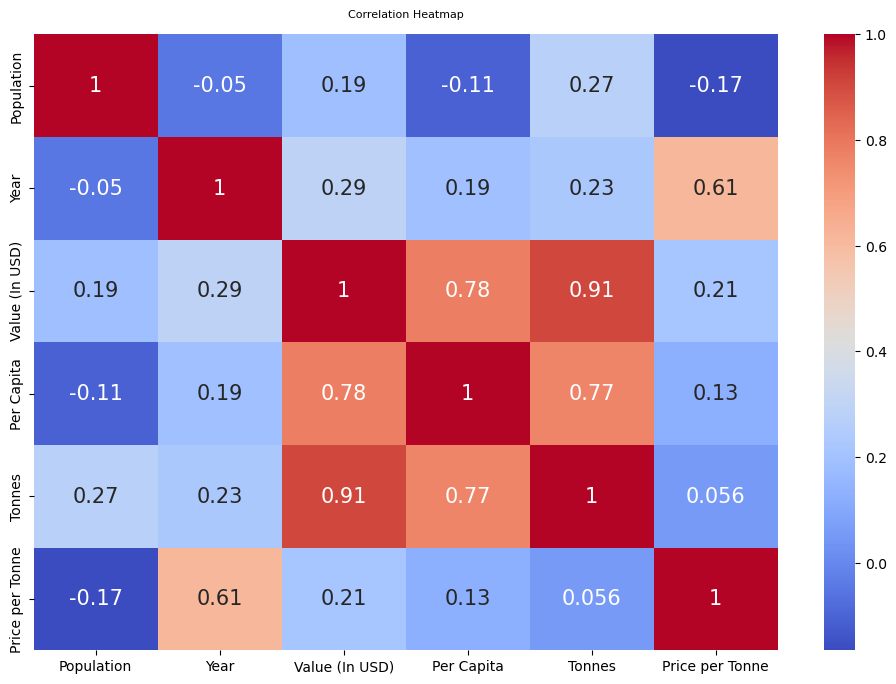

In [208]:
# creating dataframe that only includes numerical values
df_heatmap = df_EU_exports_merged.select_dtypes(["int32", "int64","float64"])
plt.figure(figsize=(12, 8))
# creating heatmap
heatmap = sns.heatmap(df_heatmap.corr(), cmap="coolwarm", annot_kws={"size": 15},annot=True)
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':8}, pad=12)
plt.show();

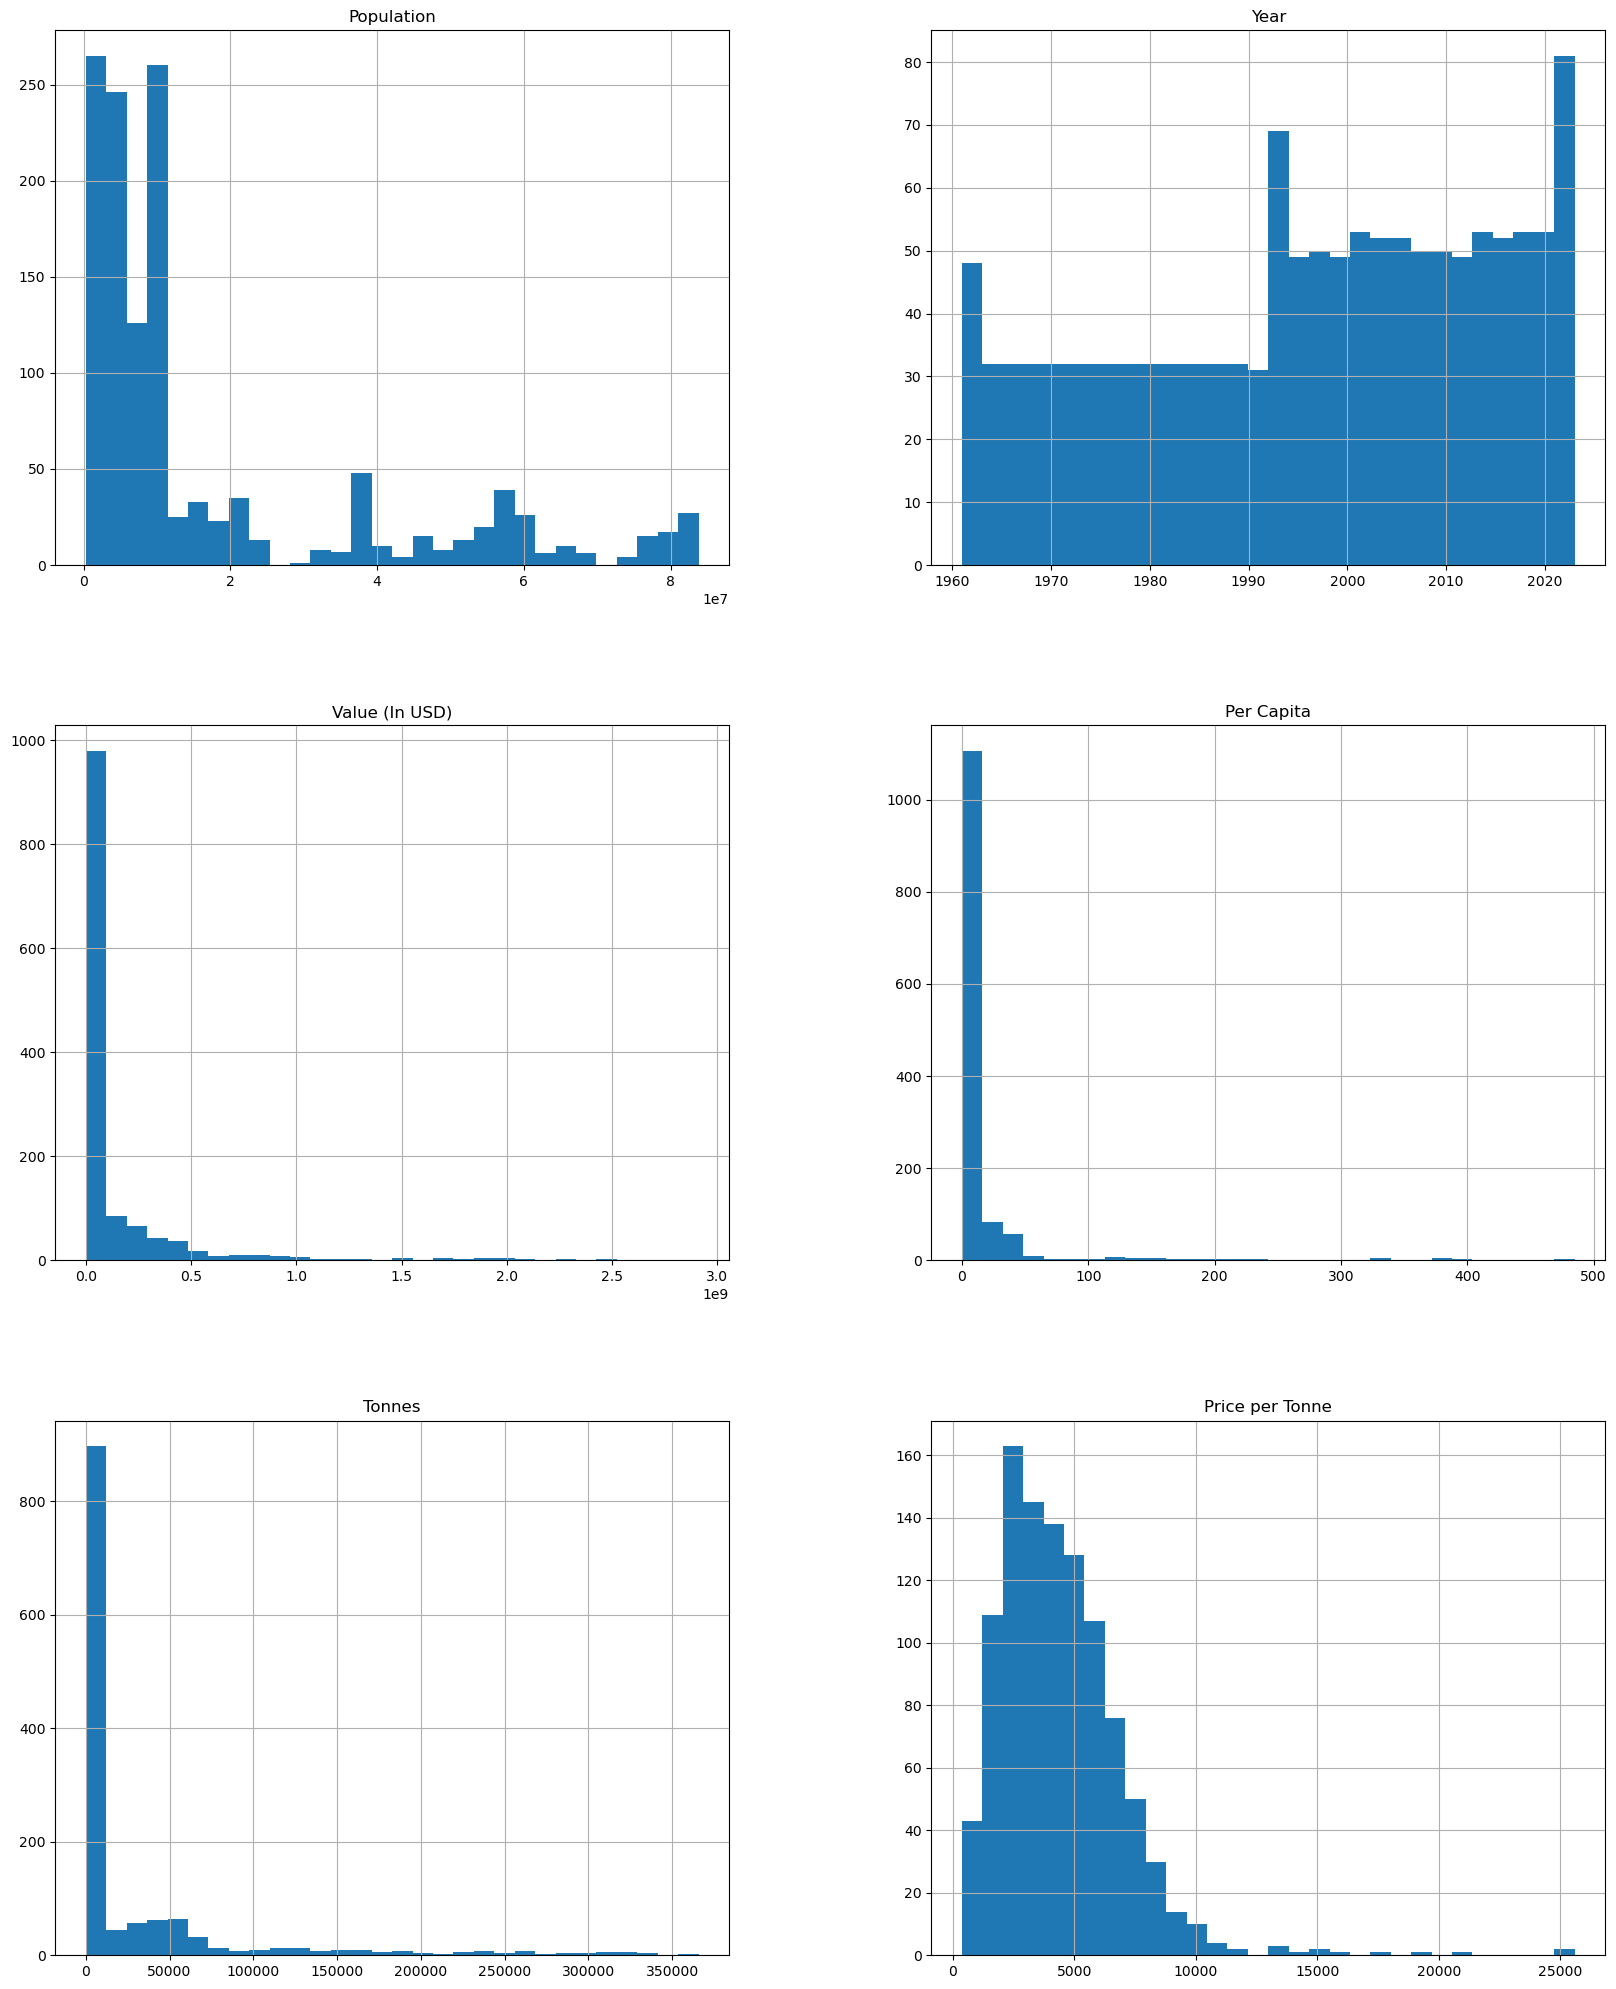

In [209]:
# plotting histograms of numerical variables
df_EU_exports_merged.hist(figsize=(20, 25), bins = 30);

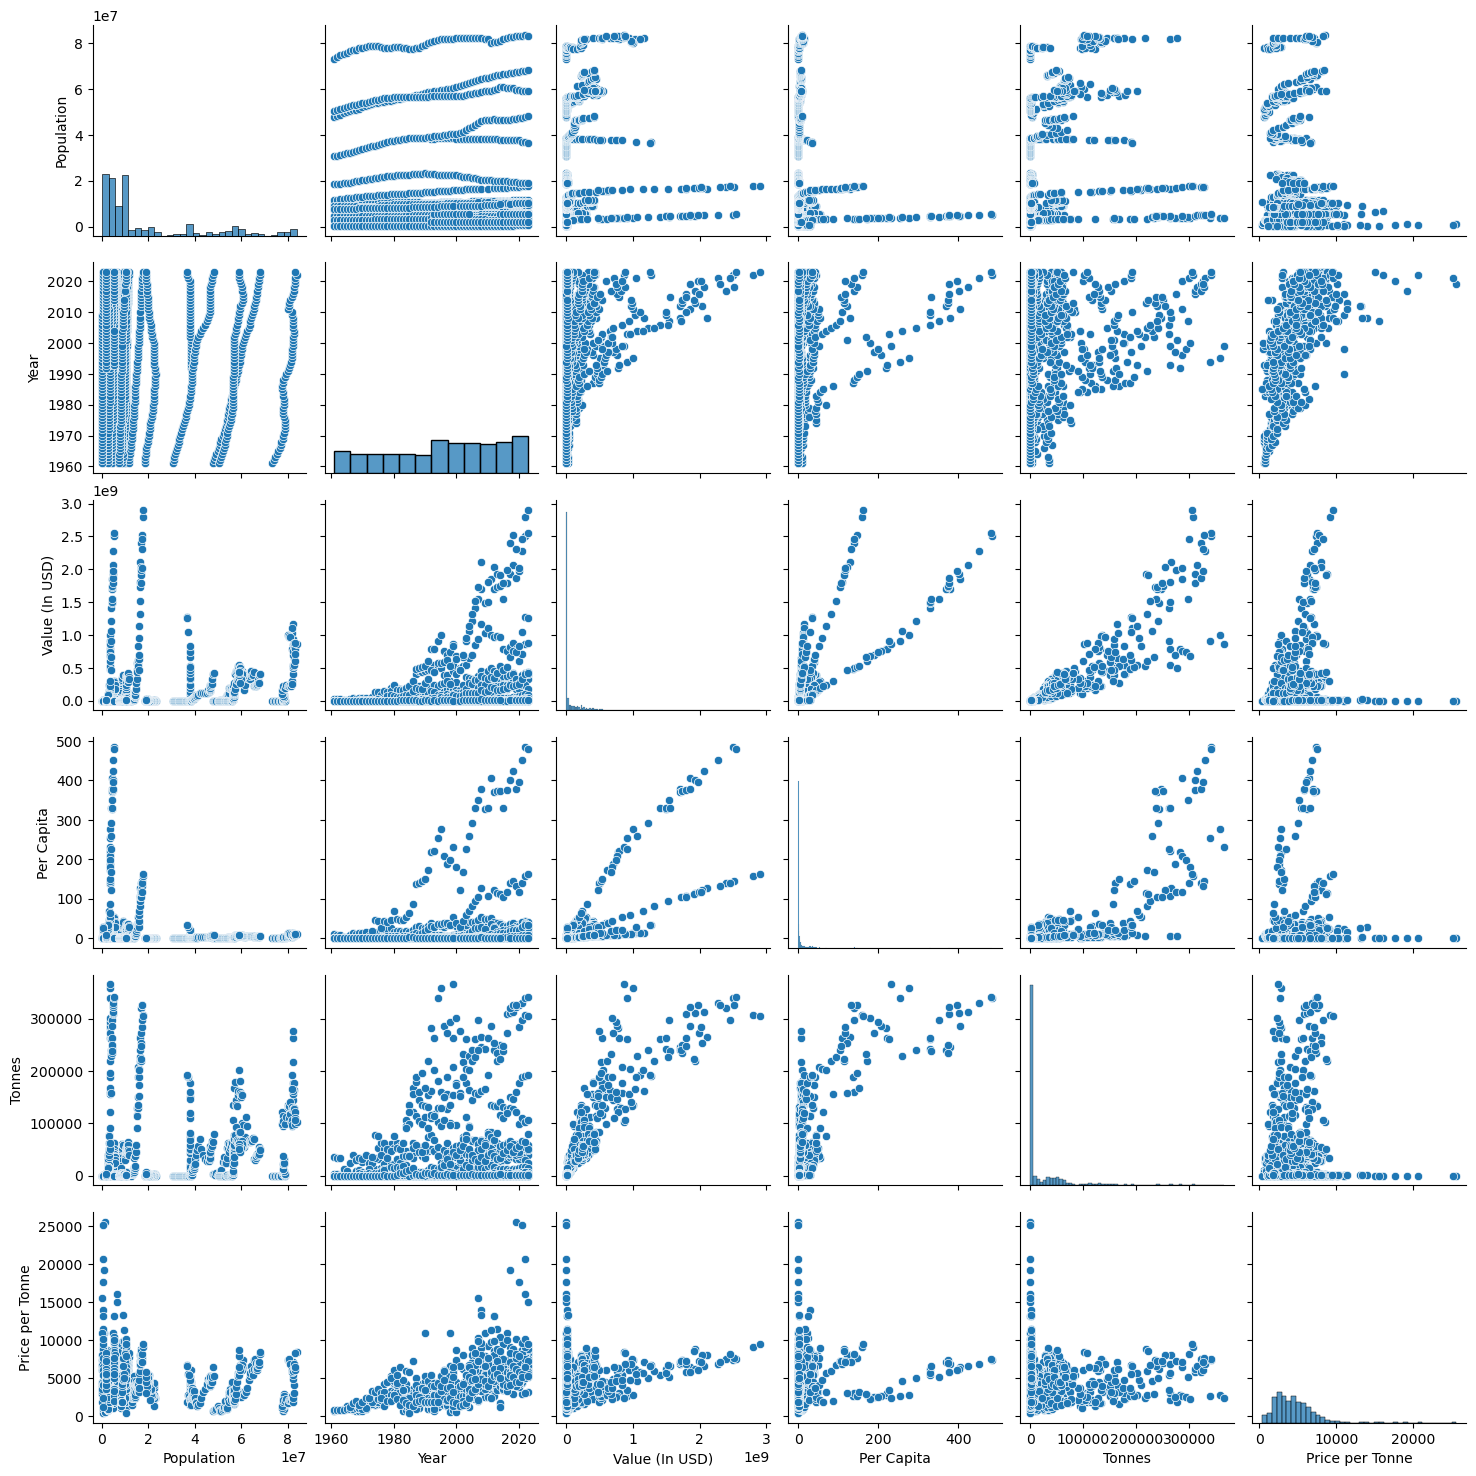

In [210]:
# plotting pairplot
sns.pairplot(df_EU_exports_merged)

This completes EDA of df_EU_exports_merged

The next dataframe is being created specifically to perform Anova test. Dataframe is filtered to contain export data just for the last 15 years.

In [213]:
# filtering dataframe to include data since 2008
df_EU_exports_last15years = df_EU_exports_merged[df_EU_exports_merged["Year"] >= 2008]

In [214]:
# checking for missing values
df_EU_exports_last15years.isnull().sum()

Area                0
Population          0
Item                0
Year                0
Value (In USD)      0
Per Capita          0
Tonnes              0
Price per Tonne     0
Flag                0
Flag Description    0
dtype: int64

In [215]:
df_EU_exports_last15years.head()

,Area,Population,Item,Year,Value (In USD),Per Capita,Tonnes,Price per Tonne,Flag,Flag Description
47,Austria,8321496,"Meat of cattle boneless, fresh or chilled",2008,239008000,28.721759,43334.0,5515.484377,A,Official figure
48,Austria,8343323,"Meat of cattle boneless, fresh or chilled",2009,268603000,32.193767,50620.0,5306.262347,A,Official figure
49,Austria,8363404,"Meat of cattle boneless, fresh or chilled",2010,271714000,32.488446,56182.0,4836.317682,A,Official figure
50,Austria,8391643,"Meat of cattle boneless, fresh or chilled",2011,276857000,32.991990,49443.0,5599.518638,A,Official figure
51,Austria,8429991,"Meat of cattle boneless, fresh or chilled",2012,294911000,34.983549,50222.0,5872.147664,A,Official figure


Dataframe is now ready for Anova test.

### df_worldwide dataframe

In [218]:
df_worldwide.head()

,Area,Year,Tonnes
0,Afghanistan,2020,130.0
1,Afghanistan,2021,12960.0
2,Afghanistan,2023,470.0
3,Afghanistan,2021,50.0
4,Afghanistan,2023,220.0


In [219]:
df_worldwide_value.head()

,Area,Year,Value in USD
0,Afghanistan,2020,1000
1,Afghanistan,2021,41000
2,Afghanistan,2023,2000
3,Afghanistan,2021,4000
4,Afghanistan,2023,1000


In [220]:
# Merge the DataFrames on common columns
df_world_exports_merged = pd.merge(
    df_worldwide, 
    df_worldwide_value, 
    on=["Area", "Year"], 
    how="inner")

In [221]:
df_world_exports_merged.head()

,Area,Year,Tonnes,Value in USD
0,Afghanistan,2020,130.0,1000
1,Afghanistan,2021,12960.0,41000
2,Afghanistan,2021,12960.0,4000
3,Afghanistan,2023,470.0,2000
4,Afghanistan,2023,470.0,1000


In [222]:
# merging two dataframes
df_worldwide_last5years = df_world_exports_merged.groupby("Area", as_index=False).agg({"Tonnes": "sum", "Value in USD": "sum"})

In [223]:
df_worldwide_last5years.head()

,Area,Tonnes,Value in USD
0,Afghanistan,27530.0,97000
1,Albania,2750.0,19000
2,Algeria,83120.0,222000
3,Angola,3370.0,6000
4,Antigua and Barbuda,11820.0,21000


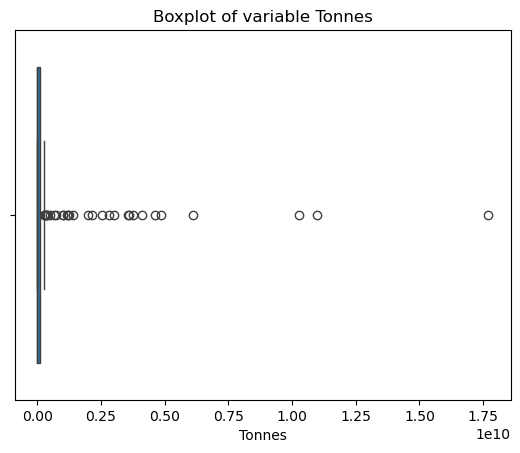

In [224]:
# creating boxplot for variable Tonnes
sns.boxplot(x="Tonnes", data=df_worldwide_last5years)
plt.title("Boxplot of variable Tonnes")
plt.xlabel("Tonnes")
plt.show()

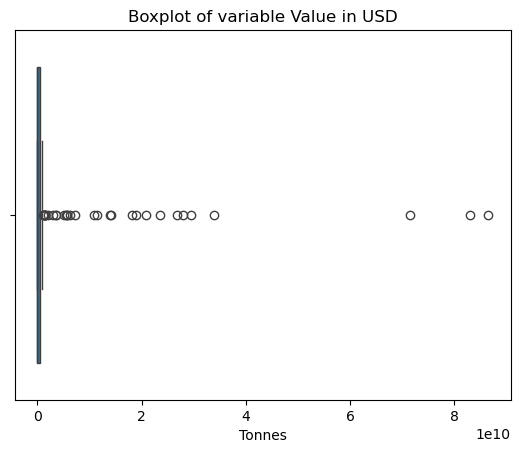

In [225]:
# creating boxplot for variable Tonnes
sns.boxplot(x="Value in USD", data=df_worldwide_last5years)
plt.title("Boxplot of variable Value in USD")
plt.xlabel("Tonnes")
plt.show()

In [226]:
df_worldwide_last5years.describe()

,Tonnes,Value in USD
count,1.610000e+02,1.610000e+02
mean,5.938567e+08,3.467807e+09
std,2.037240e+09,1.215710e+10
min,0.000000e+00,0.000000e+00
25%,4.460000e+04,2.270000e+05
50%,1.859540e+06,7.550000e+06
75%,1.084734e+08,4.452080e+08
max,1.770276e+10,8.652379e+10


Boxplots and .describe function from pandas confirmed that variables contain outliers and aren't normally distributed. MinMax scaler is picked for scaling.

In [228]:
df_worldwide__last5years_scaled = df_worldwide_last5years

In [229]:
# scaling the variables
df_worldwide__last5years_scaled["Tonnes"]=preproc.minmax_scale(df_worldwide__last5years_scaled[["Tonnes"]])
df_worldwide__last5years_scaled["Value in USD"]=preproc.minmax_scale(df_worldwide__last5years_scaled[["Value in USD"]])

In [230]:
df_worldwide__last5years_scaled.head()

,Area,Tonnes,Value in USD
0,Afghanistan,1.555125e-06,1.121079e-06
1,Albania,1.553430e-07,2.195928e-07
2,Algeria,4.695313e-06,2.565768e-06
3,Angola,1.903658e-07,6.934509e-08
4,Antigua and Barbuda,6.676925e-07,2.427078e-07


<span style="color: blue;">

## 3. Visualisations <a class="anchor" id="25th-bullet"></a>
    
</span>

To start overview irish agriculture sector, it makes sense to take a look at the sector as a whole and then analyse beef comodity separately.

In [233]:
df_overview_value["Grand Total"] = df_overview_value["Grand Total"].str.replace(",", "").astype(float)

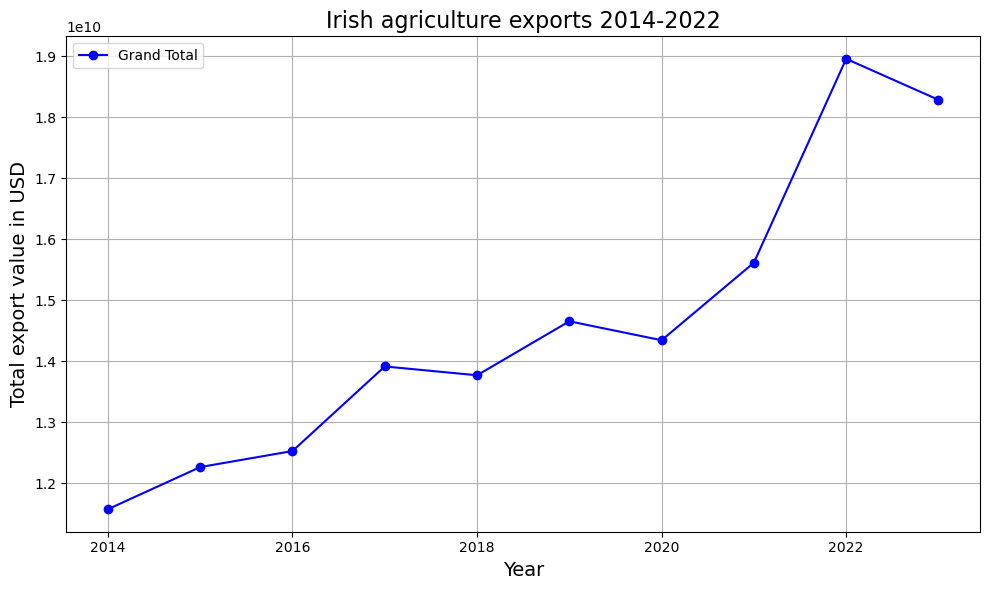

In [234]:
# creating temporary dataframe including total data of irish exports
grand_total = df_overview_value[["Year", "Grand Total"]]

# creating  line plot
fig_agri_total = plt.figure(figsize=(10, 6))
plt.plot(grand_total['Year'], grand_total["Grand Total"], marker="o", color="blue", label= "Grand Total")

# adding titles and labels
plt.title("Irish agriculture exports 2014-2022", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Total export value in USD", fontsize=14)
plt.grid(True)
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()

Next let's have a look at total tonnage of the exports in the same years.

In [236]:
df_overview_tonnes["Grand Total"] = df_overview_tonnes["Grand Total"].str.replace(",", "").astype(float)

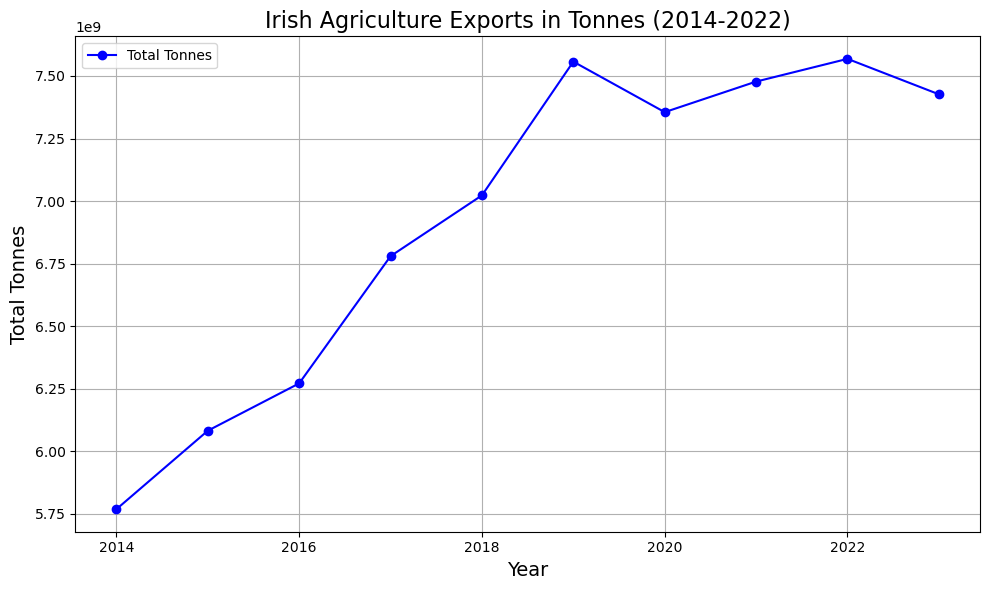

In [237]:
fig_agri_total_tonnes = plt.figure(figsize=(10, 6))
plt.plot(df_overview_tonnes["Year"], df_overview_tonnes["Grand Total"], marker="o", color="blue", label="Total Tonnes")

# Adding titles and labels
plt.title("Irish Agriculture Exports in Tonnes (2014-2022)", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Total Tonnes", fontsize=14)
plt.grid(True)
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()

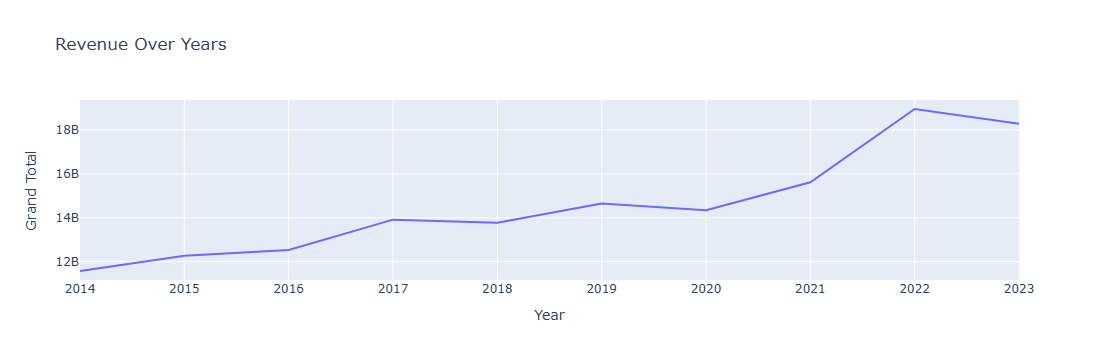

In [238]:
categories = ["Grand Total"]

fig2 = px.line(grand_total, x="Year", y="Grand Total", title="Revenue Over Years")
fig2_dashboard = px.line(grand_total, x="Year", y="Grand Total", title="Revenue Over Years", width=1900, height=500)

fig2.show()

Next graph is to visualise all agriculturual comodities, to see how their exports changed over the years. 

In [240]:
# grand total is allready plotted, so this
columns_to_plot = [col for col in df_overview_value.columns if col not in ["Year", "Grand Total"]]

# changing the format of the dataframe for easier plotting
df_melted = df_overview_value.melt(id_vars='Year', value_vars=columns_to_plot, 
                                   var_name = "Comodity", value_name = "Value")

In [241]:
# checking if the dataframe was transformed
df_melted.head()

,Year,Comodity,Value
0,2014,Animal Feed,"275,833,946"
1,2015,Animal Feed,"357,959,685"
2,2016,Animal Feed,"321,174,450"
3,2017,Animal Feed,"360,734,374"
4,2018,Animal Feed,"385,330,749"


In [242]:
df_melted["Value"] = df_melted["Value"].str.replace(",", "").astype(float)

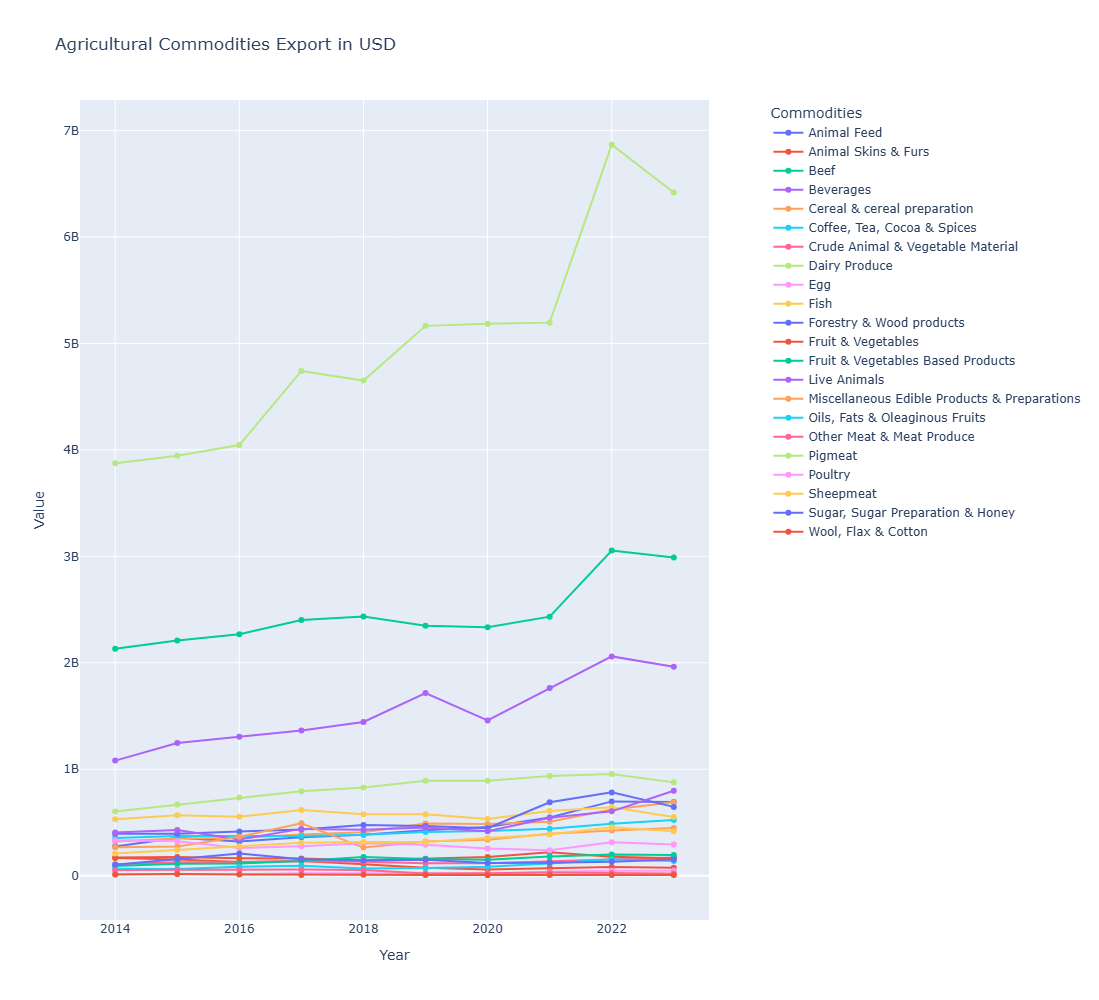

In [243]:
# creating interactive chart to display lineplot for all comodities
fig = px.line(
    df_melted,
    x='Year',
    y='Value',
    color="Comodity",  # Each variable gets its own line color
    hover_data={"Comodity": True, "Value": True},  # Show variable and value on hover
    title="Agricultural Commodities Export in USD"
)

# updating layout to improve interactivity
fig.update_traces(
    hovertemplate="<b>Comodity:</b> %{customdata[0]}<br><b>Year:</b> %{x}<br><b>Value in USD:</b> %{y}<extra></extra>",
    mode="lines+markers",  # Make lines easier to hover over by including markers
)

fig.update_layout(
    hovermode="closest",  # Ensure hover only applies to the closest line/point
    legend=dict(
        title="Commodities",
        yanchor="top",
        y=1,
        xanchor="right",
        x=1.6
    ),
    width=1000,
    height=1000
)

fig.show()

This graph is accurate, but overcrowded and not easily interpretable. To improve readability, next graph will only show top 5 comodities.

In [245]:
# grouping comodities to find top5 comodities
top_5_commodities = (
    df_melted.groupby("Comodity")["Value"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index)

In [246]:
# creating dataframe that only includes top5 comodities
df_top5 = df_melted[df_melted["Comodity"].isin(top_5_commodities)]

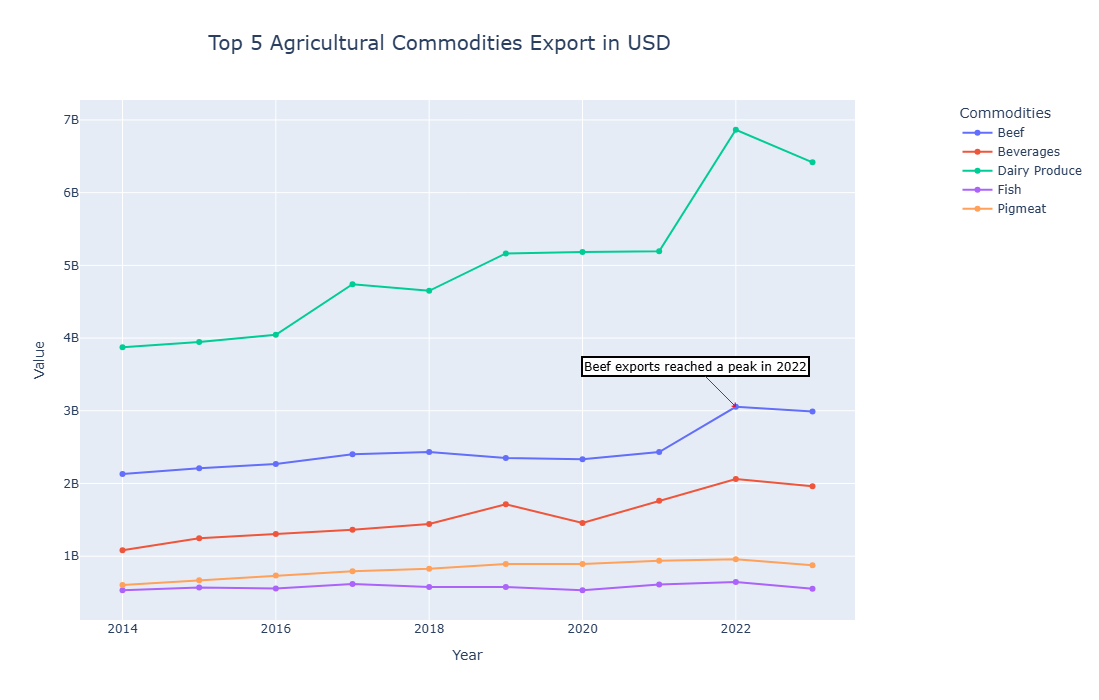

In [247]:
# creating an interactive chart to display lineplot for all commodities
all_comodities = px.line(
    df_top5,  
    x ='Year',
    y = 'Value',
    color = "Comodity",  
    hover_data = {"Comodity": True, "Value": True},  
    title = "Top 5 Agricultural Commodities Export in USD"
)

# updating layout to improve interactivity and center the title
all_comodities.update_layout(
    title=dict(
        text="Top 5 Agricultural Commodities Export in USD",  
        x=0.4,  
        xanchor='center',  
        font=dict(size=20)  
    ),
    hovermode="closest",  
    legend=dict(
        title="Commodities",
        yanchor="top",
        y=1,
        xanchor="right",
        x=1.3
    ),
    width=1000,
    height=700  
)

# adding annotation for Beef chart, according to Tufte's principles
beef_data = df_top5[df_top5["Comodity"] == "Beef"]  
annotation_year = beef_data["Year"].iloc[-2]  
annotation_value = beef_data["Value"].iloc[-2]  
# styling the annotation box
all_comodities.add_annotation(
    x = annotation_year,
    y = annotation_value,
    text = "Beef exports reached a peak in 2022",  
    showarrow = True,  
    arrowhead = 4,  
    ax = -40,  
    ay = -40,  
    arrowcolor = "red",  
    font = dict(size=12, color="black"), 
    bgcolor = "white",  
    bordercolor = "black",  
    borderwidth = 2  )

# updating traces to improve hover interactivity
all_comodities.update_traces(
    hovertemplate = "<b>Comodity:</b> %{customdata[0]}<br><b>Year:</b> %{x}<br><b>Value in USD:</b> %{y}<extra></extra>",
    mode = "lines+markers"  
)

# displaying the chart
all_comodities.show()

Next visualisation is created to have a look how Ireland is doing comparing to the rest of EU countries. To be specific there is talk here about specifically boneless meat of cattle.

In [249]:
df_EU_exports_last15years.head()

,Area,Population,Item,Year,Value (In USD),Per Capita,Tonnes,Price per Tonne,Flag,Flag Description
47,Austria,8321496,"Meat of cattle boneless, fresh or chilled",2008,239008000,28.721759,43334.0,5515.484377,A,Official figure
48,Austria,8343323,"Meat of cattle boneless, fresh or chilled",2009,268603000,32.193767,50620.0,5306.262347,A,Official figure
49,Austria,8363404,"Meat of cattle boneless, fresh or chilled",2010,271714000,32.488446,56182.0,4836.317682,A,Official figure
50,Austria,8391643,"Meat of cattle boneless, fresh or chilled",2011,276857000,32.991990,49443.0,5599.518638,A,Official figure
51,Austria,8429991,"Meat of cattle boneless, fresh or chilled",2012,294911000,34.983549,50222.0,5872.147664,A,Official figure


In [250]:
# grouping data by the Area
grouped_data = df_EU_exports_last15years.groupby("Area")["Tonnes"].sum().sort_values()

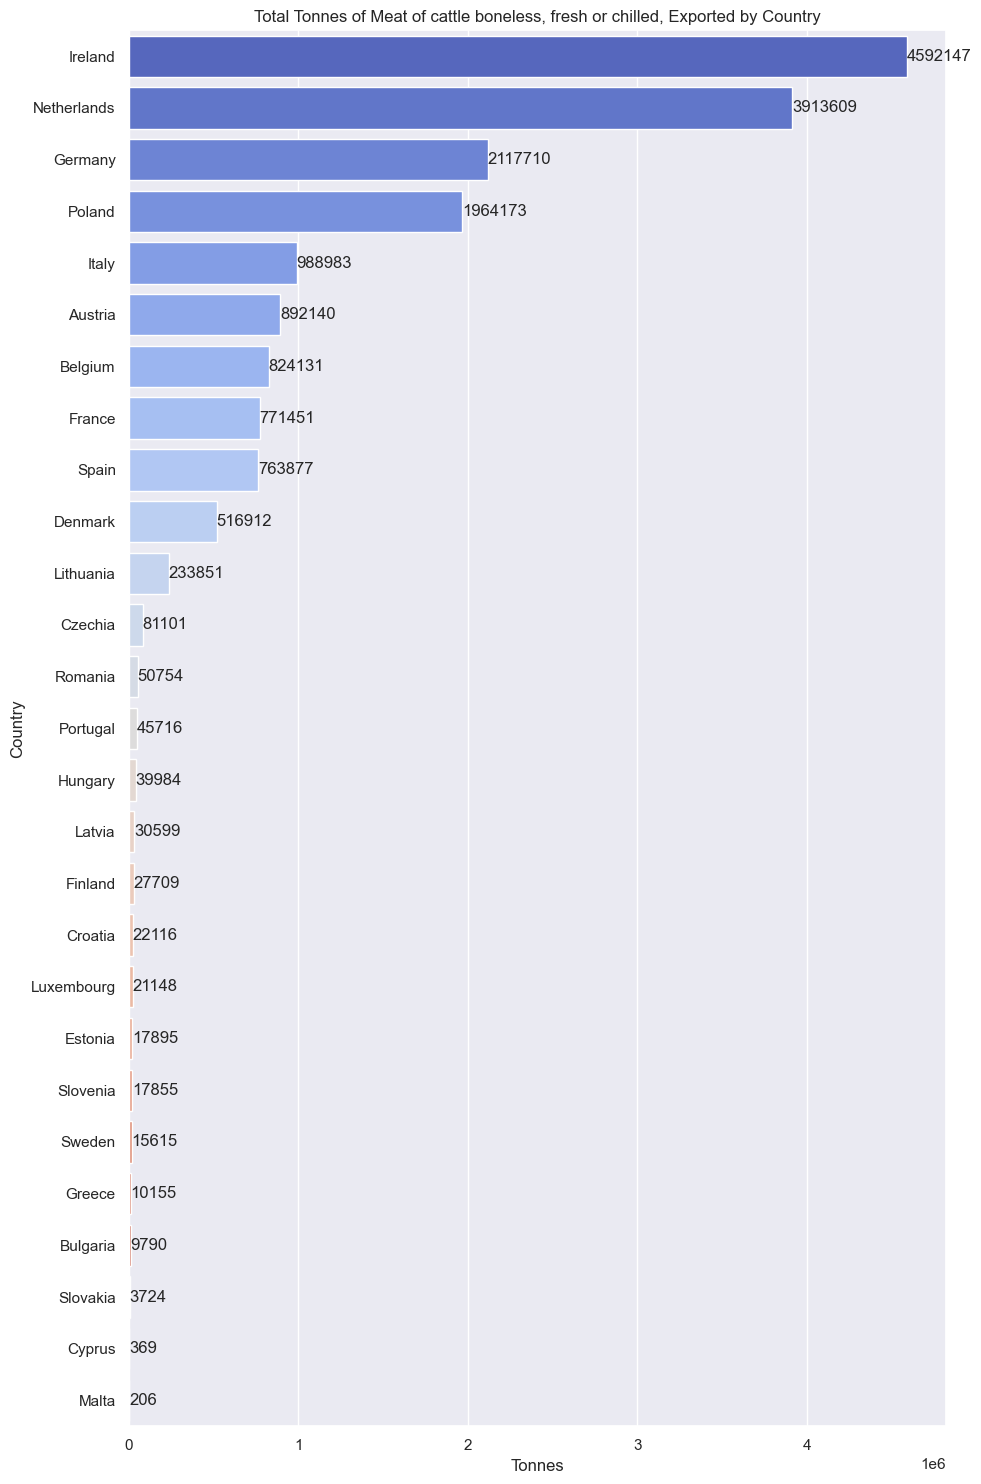

In [251]:
# grouping data by the area
grouped_data = df_EU_exports_last15years.groupby("Area")["Tonnes"].sum().sort_values(ascending=False).reset_index()

# adjusting the size
sns.set(rc={"figure.figsize": (10, 15)})

# plotting the barchart 
ax = sns.barplot(data = grouped_data, y = "Area", x = "Tonnes", palette = "coolwarm")
ax.set(title = "Total Tonnes of Meat of cattle boneless, fresh or chilled, Exported by Country", xlabel = "Tonnes", ylabel = "Country")

# styling the bars
for p in ax.patches:
    width = p.get_width()  
    height = p.get_height()  
    ax.text(x = width + 5,  
            y = p.get_y() + (height / 2),  
            s = f"{width:.0f}",  
            va = "center")  

# displaying the plot
plt.tight_layout()
plt.show()

This graph shows all the exporters, many of them are insignifant. To make the graph more relevant, and available for the dashboard, exporters are limited to the top10

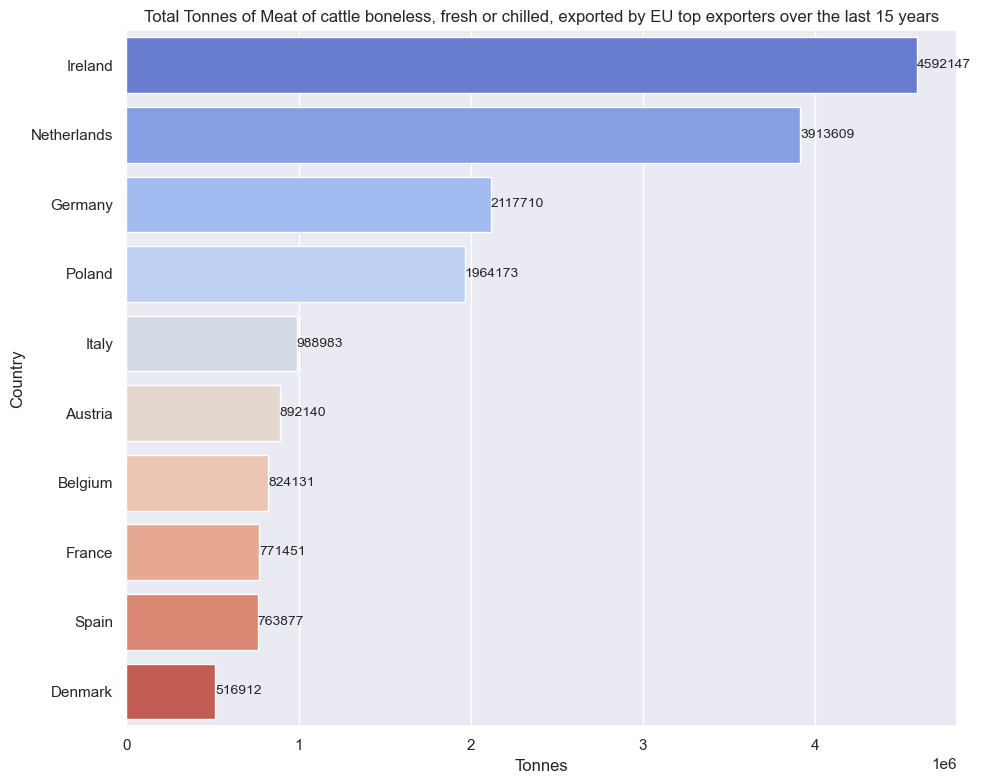

In [253]:
# grouping data and setting head at 10, to show only top10 exporters
grouped_data = (
    df_EU_exports_last15years.groupby("Area")["Tonnes"]
    .sum()
    .sort_values(ascending=False)
    .head(10)  #
    .reset_index())

# adjusting the size
sns.set(rc={"figure.figsize": (10, 8)})

# creating a bar chart
ax = sns.barplot(data=grouped_data, y="Area", x="Tonnes", palette="coolwarm")
ax.set(title="Total Tonnes of Meat of cattle boneless, fresh or chilled, exported by EU top exporters over the last 15 years", xlabel="Tonnes", ylabel="Country")

# styling bars
for p in ax.patches:
    width = p.get_width()  
    height = p.get_height()  
    ax.text(
        x=width + 5, 
        y=p.get_y() + (height / 2),  
        s=f"{width:.0f}",  
        va="center",  
        fontsize=10
    )

# displaying the plot
plt.tight_layout()
plt.show()



In [254]:
# creating figure to use it on dashboard
fig_top10 = plt.gcf()  

# giving the separate name for Dashboard
EU_top10_panel = pn.pane.Matplotlib(fig_top10, tight=True, width=800, height=600)

<Figure size 1000x800 with 0 Axes>

Next graph compares irish boneless beef exports with all other EU countries just for the year 2023

In [256]:
df_EU_beef_exports.head()

,Area Code (M49),Area,Item,Year,Value (In USD),Flag,Flag Description
0,40,Austria,"Meat of cattle boneless, fresh or chilled",1961,0,A,Official figure
1,40,Austria,"Meat of cattle boneless, fresh or chilled",1962,0,A,Official figure
2,40,Austria,"Meat of cattle boneless, fresh or chilled",1963,0,A,Official figure
3,40,Austria,"Meat of cattle boneless, fresh or chilled",1964,0,A,Official figure
4,40,Austria,"Meat of cattle boneless, fresh or chilled",1965,0,A,Official figure


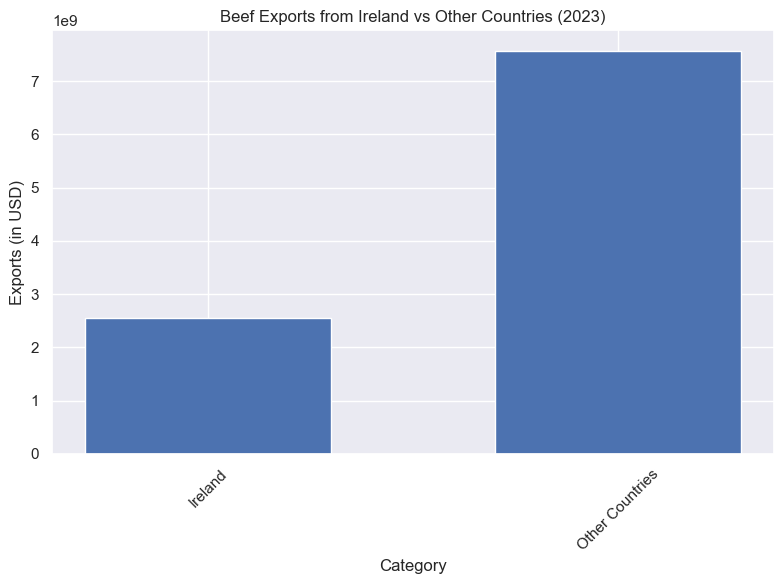

In [257]:
# filtering the data for 2023
df_2023 = df_EU_beef_exports[df_EU_beef_exports["Year"] == 2023]

# grouping into 2 groups - Ireland and other countries
df_2023["Category"] = df_2023["Area"].apply(lambda x: "Ireland" if x == "Ireland" else "Other Countries")

# summing data
summary = df_2023.groupby("Category")["Value (In USD)"].sum().reset_index()

# plotting the graph
plt.figure(figsize=(8, 6))
plt.bar(summary["Category"], summary["Value (In USD)"], width=0.6)
plt.title("Beef Exports from Ireland vs Other Countries (2023)")
plt.ylabel("Exports (in USD)")
plt.xlabel("Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Next graph is animated  graph exploring how the boneless beef exports changed over the years across the EU states.

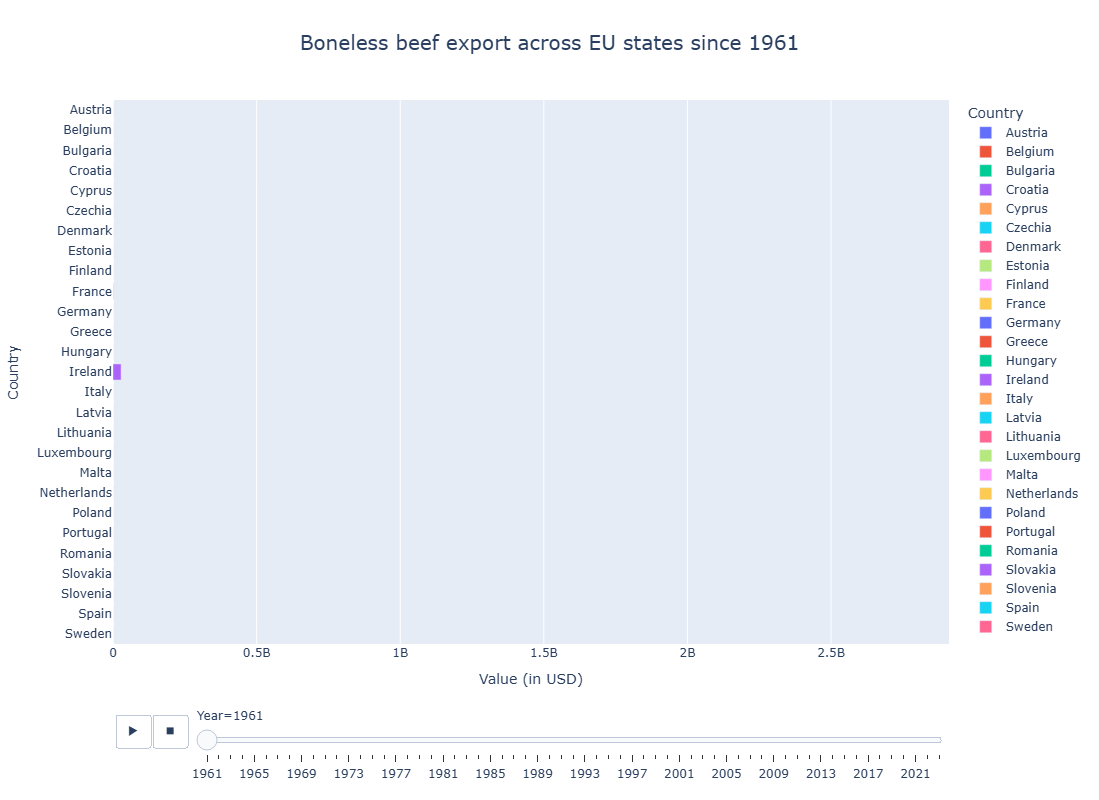

In [259]:
# ensuring all the EU countries exist
all_years = df_EU_beef_exports["Year"].unique()
all_countries = df_EU_beef_exports["Area"].unique()
full_index = pd.MultiIndex.from_product([all_years, all_countries], names=["Year", "Area"])

# reindexing the DataFrame to include all combinations, filling missing values with 0
df_complete = df_EU_beef_exports.set_index(["Year", "Area"]).reindex(full_index, fill_value=0).reset_index()

# plotting the graph
export_change_through_the_years = px.bar(
    df_complete,
    x="Value (In USD)",
    y="Area",
    color="Area",
    animation_frame = "Year",
    range_x = [0, df_complete["Value (In USD)"].max() + 200],
    title = "Beef Exports from Ireland vs Other Countries Over the Years",
    labels = {"Value": "Exports (in tons)", "Area": "Country"}
)

# adjusting size and centering the title
export_change_through_the_years.update_layout(
    title={
        "text": "Boneless beef export across EU states since 1961",
        "x": 0.5, 
        "xanchor": "center",  
        "font": {"size": 20}   },
    yaxis_title = "Country",
    xaxis_title = "Value (in USD)",
    width = 1000,
    height = 800)

<span style="color: blue;">

## 2. Statistical Techniques <a class="anchor" id="twelfth-bullet"></a>
    
</span>

In this chapter dataframes are analised from statistics point of view. Distributions analised, and hypothesis tests performed.

Datasets of this project are used to perform different statistical tests. Therefore it makes sense to have a look at the variables involved in these tests.

<span style="color: blue;">

### 2.1. Descriptive statistics <a class="anchor" id="12th-bullet"></a>
    
</span>

Datasets of this project are used to perform different statistical tests. Therefore it makes sense to have a look at the variables involved in these tests.

In [265]:
df_EU_exports_last15years.head()

,Area,Population,Item,Year,Value (In USD),Per Capita,Tonnes,Price per Tonne,Flag,Flag Description
47,Austria,8321496,"Meat of cattle boneless, fresh or chilled",2008,239008000,28.721759,43334.0,5515.484377,A,Official figure
48,Austria,8343323,"Meat of cattle boneless, fresh or chilled",2009,268603000,32.193767,50620.0,5306.262347,A,Official figure
49,Austria,8363404,"Meat of cattle boneless, fresh or chilled",2010,271714000,32.488446,56182.0,4836.317682,A,Official figure
50,Austria,8391643,"Meat of cattle boneless, fresh or chilled",2011,276857000,32.991990,49443.0,5599.518638,A,Official figure
51,Austria,8429991,"Meat of cattle boneless, fresh or chilled",2012,294911000,34.983549,50222.0,5872.147664,A,Official figure


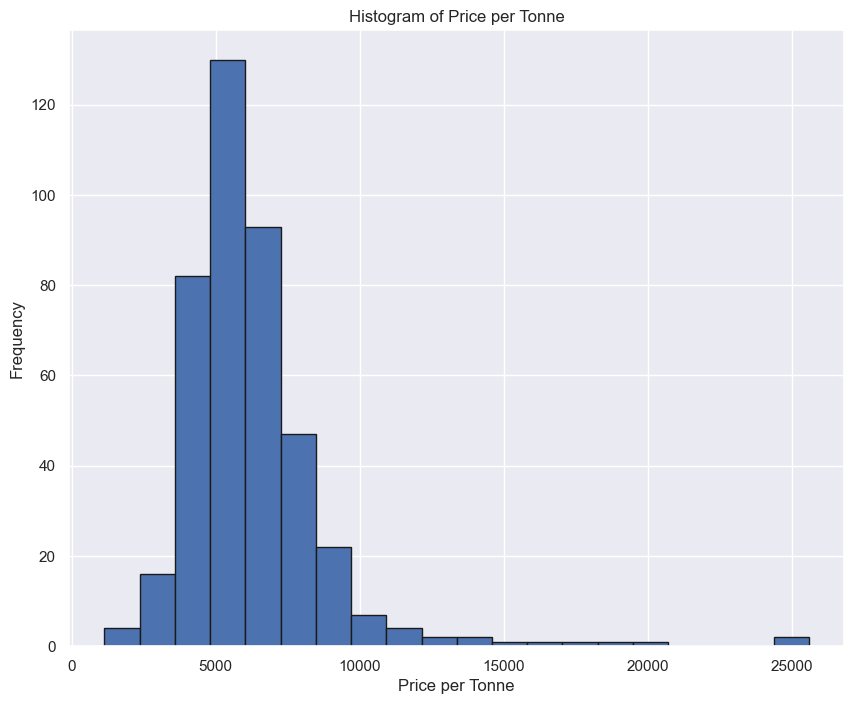

In [266]:
# Plot histogram
plt.hist(df_EU_exports_last15years['Price per Tonne'], bins=20, edgecolor='k')
plt.title('Histogram of Price per Tonne')
plt.xlabel('Price per Tonne')
plt.ylabel('Frequency')
plt.show()

First glance at the graph suggests, that data is heavily positively skewed.

In [268]:
# calculating skewedness of variable price
df_EU_exports_last15years["Price per Tonne"].skew()

3.349784901290569

In [269]:
# calculating skewedness of variable price
df_EU_exports_last15years["Price per Tonne"].kurtosis()

18.687804042582478

The variable Price per Tonnes currently doesn't meet Anova conditions, and it's distribution need to be transformed.

<span style="color: blue;">

### 2.2. Inferential Statistics <a class="anchor" id="13th-bullet"></a>
    
</span>

Starting with transforming Price per Tonne variable of df_EU_exports_last15years dataframe for Anova test.

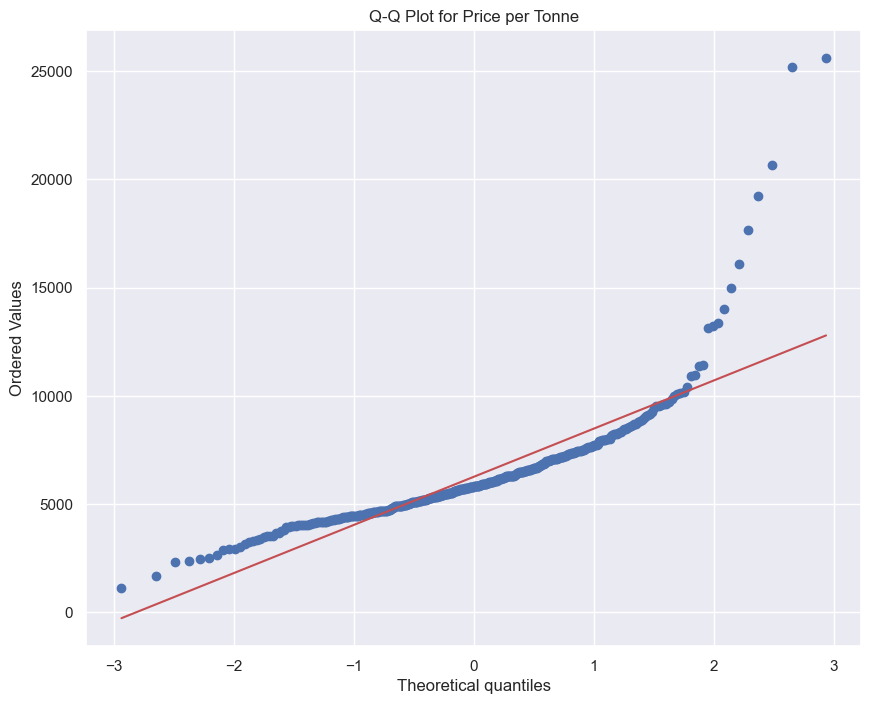

In [273]:
# plotting Q-Q plot
stats.probplot(df_EU_exports_last15years["Price per Tonne"], dist="norm", plot=plt)
plt.title("Q-Q Plot for Price per Tonne")
plt.show()

Preparing variable suitable for Anova test using normalisation technique.

In [275]:
# giving new name specifically to Anova testing
df_anova = df_EU_exports_last15years

In [276]:
# applying Log transformation
df_anova["Log Price per Tonne"] = np.log(df_anova["Price per Tonne"])

In [277]:
df_anova.head()

,Area,Population,Item,Year,Value (In USD),Per Capita,Tonnes,Price per Tonne,Flag,Flag Description,Log Price per Tonne
47,Austria,8321496,"Meat of cattle boneless, fresh or chilled",2008,239008000,28.721759,43334.0,5515.484377,A,Official figure,8.615315
48,Austria,8343323,"Meat of cattle boneless, fresh or chilled",2009,268603000,32.193767,50620.0,5306.262347,A,Official figure,8.576643
49,Austria,8363404,"Meat of cattle boneless, fresh or chilled",2010,271714000,32.488446,56182.0,4836.317682,A,Official figure,8.483909
50,Austria,8391643,"Meat of cattle boneless, fresh or chilled",2011,276857000,32.991990,49443.0,5599.518638,A,Official figure,8.630436
51,Austria,8429991,"Meat of cattle boneless, fresh or chilled",2012,294911000,34.983549,50222.0,5872.147664,A,Official figure,8.677976


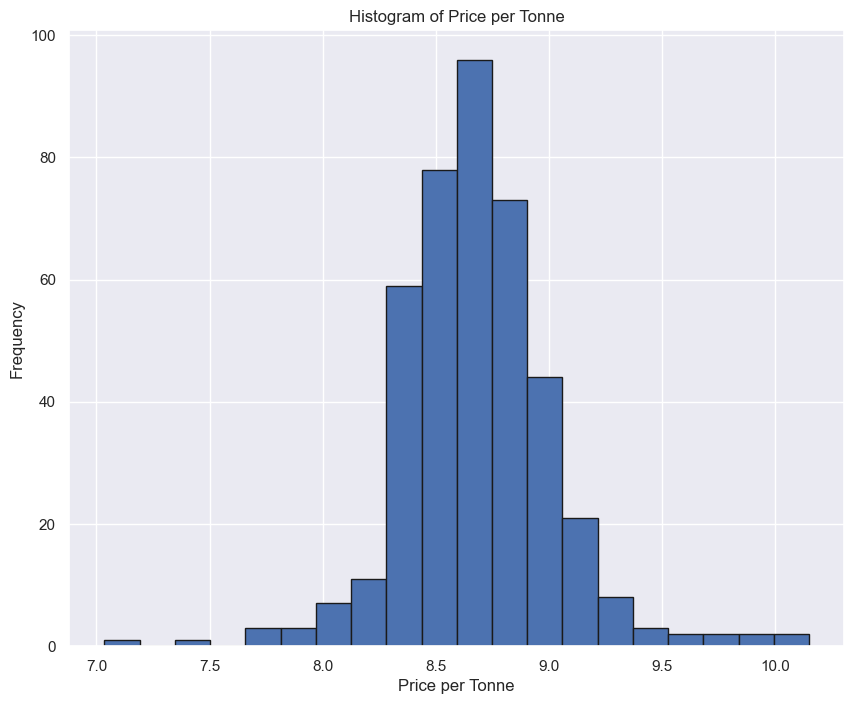

In [278]:
# Plot histogram
plt.hist(df_anova['Log Price per Tonne'], bins=20, edgecolor='k')
plt.title('Histogram of Price per Tonne')
plt.xlabel('Price per Tonne')
plt.ylabel('Frequency')
plt.show()

In [279]:
# calculating skewness of variable price
df_anova["Log Price per Tonne"].skew()

0.29972814715485174

In [280]:
# calculating kurtosis of variable price
df_anova["Log Price per Tonne"].kurtosis()

3.7157917224081256

This dataframe is now ready for ANOVA test.

Next hypothesesis is to check if EU's top exporters of boneless beef Ireland and Netherlands are getting the same price for their beef. As it’s only two groups (Ireland and Netherlands) T-test is suitable in this case. The requirement for normal distributions for both groups still remains.

First data for Netherlands and Ireland is separated from the dataset.

In [284]:
# filter rows for Netherlands and Ireland
netherlands_data = df_EU_exports_last15years[df_EU_exports_last15years["Area"] == "Netherlands"]
ireland_data = df_EU_exports_last15years[df_EU_exports_last15years["Area"] == "Ireland"]

# extract "Price per Tonne" values
netherlands_prices = netherlands_data["Price per Tonne"]
ireland_prices = ireland_data["Price per Tonne"]

Before the actual test can be done, few tests need to be performed to double check if the data is suitable for T-Test at all.
One of the methods is Levene test. Levene test evaluates equality of variances between two (or more) groups. 


In [286]:
# testing with Levene method
stat, p_value = levene(ireland_prices, netherlands_prices)
print(f"Levene's Test Statistic: {stat}, p-value: {p_value}")

if p_value > 0.05:
    print("Variances are equal (assumption of standard t-test is valid).")
else:
    print("Variances are not equal (use Welch's t-test).")

Levene's Test Statistic: 1.8637462919978944, p-value: 0.18306238571686761
Variances are equal (assumption of standard t-test is valid).


In [287]:
stat_ireland, p_ireland = shapiro(ireland_prices)
stat_netherlands, p_netherlands = shapiro(netherlands_prices)

print(f"Ireland: Test Statistic = {stat_ireland}, p-value = {p_ireland}")
print(f"Netherlands: Test Statistic = {stat_netherlands}, p-value = {p_netherlands}")

if p_ireland > 0.05:
    print("Ireland's data is approximately normal.")
else:
    print("Ireland's data is not normal.")

if p_netherlands > 0.05:
    print("Netherlands' data is approximately normal.")
else:
    print("Netherlands' data is not normal.")

Ireland: Test Statistic = 0.9410794913231977, p-value = 0.3624476304741727
Netherlands: Test Statistic = 0.9355521629720641, p-value = 0.3643074145215761
Ireland's data is approximately normal.
Netherlands' data is approximately normal.


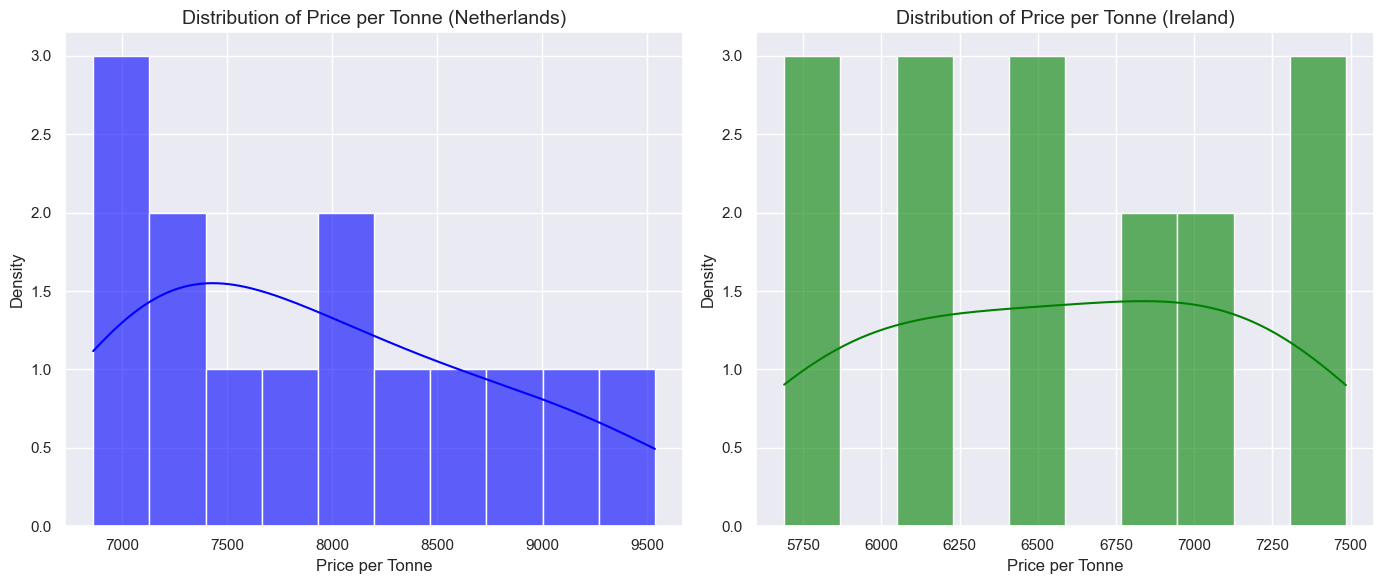

In [288]:

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(netherlands_prices, kde=True, bins=10, color="blue", alpha=0.6)
plt.title("Distribution of Price per Tonne (Netherlands)", fontsize=14)
plt.xlabel("Price per Tonne", fontsize=12)
plt.ylabel("Density", fontsize=12)

plt.subplot(1, 2, 2)
sns.histplot(ireland_prices, kde=True, bins=10, color="green", alpha=0.6)
plt.title("Distribution of Price per Tonne (Ireland)", fontsize=14)
plt.xlabel("Price per Tonne", fontsize=12)
plt.ylabel("Density", fontsize=12)


plt.tight_layout()
plt.show()

<span style="color: blue;">

### 2.3. Inferential Statistical Techniques <a class="anchor" id="19th-bullet"></a>
    
</span>

<span style="color: blue;">

#### 2.3.1. Difference in Differences statistical significance test <a class="anchor" id="24th-bullet"></a>
    
</span>

In [291]:
df_EU_beef_exports.head()

,Area Code (M49),Area,Item,Year,Value (In USD),Flag,Flag Description
0,40,Austria,"Meat of cattle boneless, fresh or chilled",1961,0,A,Official figure
1,40,Austria,"Meat of cattle boneless, fresh or chilled",1962,0,A,Official figure
2,40,Austria,"Meat of cattle boneless, fresh or chilled",1963,0,A,Official figure
3,40,Austria,"Meat of cattle boneless, fresh or chilled",1964,0,A,Official figure
4,40,Austria,"Meat of cattle boneless, fresh or chilled",1965,0,A,Official figure


__Null Hypothesis (H₀)__: Brexit had bigger impact on Ireland than the rest of EU.

__Alternative Hypothesis (H₁)__: Brexit didn’t have bigger impact on Ireland than the rest of EU.


In [293]:
# creatting dataframe for DiD analysis
df_DiD = pd.DataFrame(df_EU_beef_exports)

In [294]:
# creating Treatment variable (1 denotes Ireland, 0 - others)
df_DiD["Treatment"] = df_EU_beef_exports["Area"].apply(lambda x: 1 if x == "Ireland" else 0)

# creating Post-Event variable (1 for post-Brexit years, 0 for pre-Brexit years)
df_DiD["Post_Event"] = df_EU_beef_exports["Year"].apply(lambda x: 1 if x >= 2020 else 0)

# creating Interaction variable
df_DiD["Interaction"] = df_DiD["Treatment"] * df_DiD["Post_Event"]

# calling the newly created dataframe
df_DiD.head()

,Area Code (M49),Area,Item,Year,Value (In USD),Flag,Flag Description,Treatment,Post_Event,Interaction
0,40,Austria,"Meat of cattle boneless, fresh or chilled",1961,0,A,Official figure,0,0,0
1,40,Austria,"Meat of cattle boneless, fresh or chilled",1962,0,A,Official figure,0,0,0
2,40,Austria,"Meat of cattle boneless, fresh or chilled",1963,0,A,Official figure,0,0,0
3,40,Austria,"Meat of cattle boneless, fresh or chilled",1964,0,A,Official figure,0,0,0
4,40,Austria,"Meat of cattle boneless, fresh or chilled",1965,0,A,Official figure,0,0,0


In [295]:
# renaming the variable so it's understood by the model
df_DiD.rename(columns={"Value (In USD)": "Value"}, inplace=True)

In [296]:
# Fit the DiD regression model
model = smf.ols("Value  ~ Treatment + Post_Event + Interaction", data=df_DiD).fit()

In [297]:
# model results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       0.224
Model:                            OLS   Adj. R-squared:                  0.223
Method:                 Least Squares   F-statistic:                     128.6
Date:                Sun, 29 Dec 2024   Prob (F-statistic):           3.68e-73
Time:                        23:35:35   Log-Likelihood:                -28097.
No. Observations:                1337   AIC:                         5.620e+04
Df Residuals:                    1333   BIC:                         5.622e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    9.747e+07   9.48e+06     10.285      

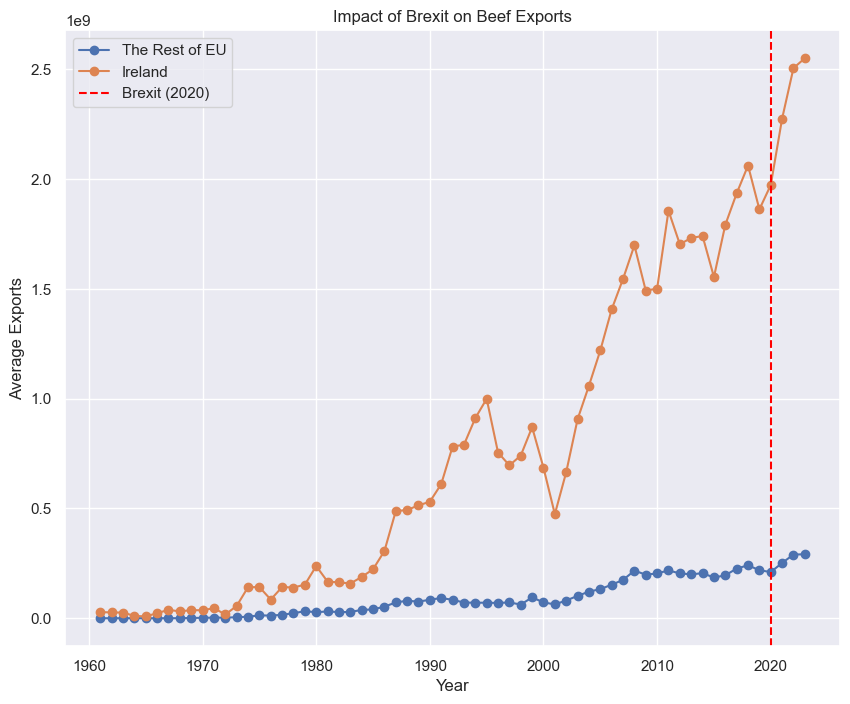

In [298]:
# grouping exports value
avg_exports = df_DiD.groupby(["Year", "Treatment"])["Value"].mean().reset_index()

# Plot the trends
for treatment in [0, 1]:
    subset = avg_exports[avg_exports["Treatment"] == treatment]
    label = "Ireland" if treatment == 1 else "The Rest of EU"
    plt.plot(subset["Year"], subset["Value"], marker="o", label=label)

# adding legends and labels
plt.axvline(x=2020, color='red', linestyle='--', label='Brexit (2020)')
plt.title('Impact of Brexit on Beef Exports')
plt.xlabel("Year")
plt.ylabel("Average Exports")
plt.legend()
plt.show()

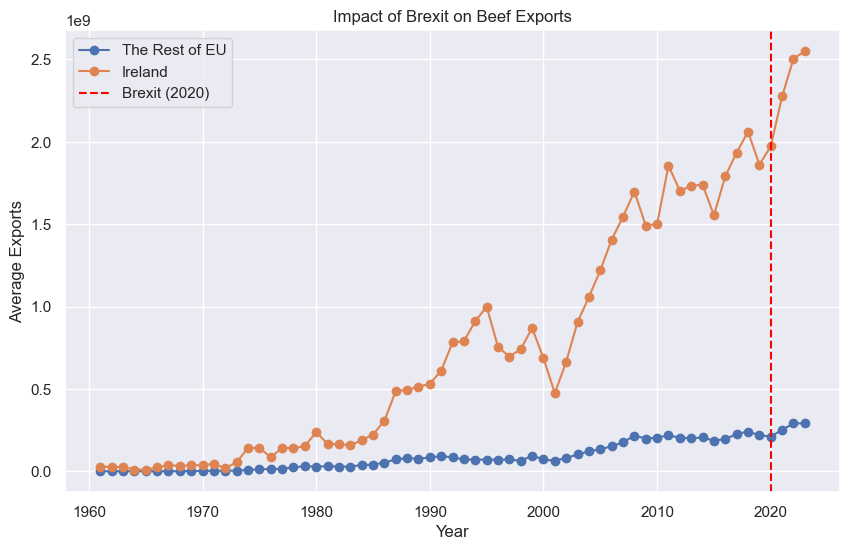

In [299]:
# grouping exports value
avg_exports = df_DiD.groupby(["Year", "Treatment"])["Value"].mean().reset_index()

# Plot the trends
def create_export_plot():
    fig, ax = plt.subplots(figsize=(10, 6))
    for treatment in [0, 1]:
        subset = avg_exports[avg_exports["Treatment"] == treatment]
        label = "Ireland" if treatment == 1 else "The Rest of EU"
        ax.plot(subset["Year"], subset["Value"], marker="o", label=label)

    # adding legends and labels
    ax.axvline(x=2020, color='red', linestyle='--', label='Brexit (2020)')
    ax.set_title('Impact of Brexit on Beef Exports')
    ax.set_xlabel("Year")
    ax.set_ylabel("Average Exports")
    ax.legend()
    return fig

# getting graph ready for dashboard
graph_for_dashboard = create_export_plot()

# giving the name for dashboard
brexit_impact = pn.pane.Matplotlib(graph_for_dashboard, name="Impact of Brexit on Beef Exports")

<span style="color: blue;">

#### 2.3.2. Augmented Dickey-Fuller test <a class="anchor" id="15th-bullet"></a>
    
</span>

Augmented Dickey-Fuller test is an important statistical test to determine whether datasets data is stationary or not. To know stationarity is very important, as it enables picking the correct Box-Jenkins model to make forecast predictions. Fox example ARIMA model cannot forecast on non-stationary data. So ADF test if that dataset contains the unit root. The null hypothesis is that the dataset does contain the unit root and test results will determine if null hypothesis should be accepted or rejected.

For this test df_beef_exports dataset is used, as this dataset is used for Time Series Analysis.

In [303]:
# reminding of the dataset
df_beef_exports.head()

,Statistic Label,Year,Tonnes
94,Exports of Beef,1930,1300
95,Exports of Beef,1931,400
96,Exports of Beef,1932,200
97,Exports of Beef,1933,2000
98,Exports of Beef,1934,0


In [304]:
# calculating adfuller tests metrics
adfuller(df_beef_exports["Tonnes"])

(-0.44263227757705403,
 0.9027336981191291,
 4,
 89,
 {'1%': -3.506057133647011,
  '5%': -2.8946066061911946,
  '10%': -2.5844100201994697},
 1947.4773688036385)

In [305]:
# presenting the results in a nicer format
adf_statistic = -0.44263227757705403
p_value = 0.9027336981191291
num_lags_used = 4
num_observations_used = 89
critical_values = {'1%': -3.506057133647011, '5%': -2.8946066061911946, '10%': -2.5844100201994697}
aic = 21947.4773688036385

print("Augmented Dickey-Fuller Test Results")
print("-------------------------------------")
print(f"ADF Statistic:               {adf_statistic}")
print(f"p-value:                     {p_value}")
print(f"Number of Lags Used:         {num_lags_used}")
print(f"Number of Observations Used: {num_observations_used}")
print("Critical Values:")
for significance, value in critical_values.items():
    print(f"                             {significance}: {value}")
print(f"Maximized Information Criterion (AIC): {aic}")

Augmented Dickey-Fuller Test Results
-------------------------------------
ADF Statistic:               -0.44263227757705403
p-value:                     0.9027336981191291
Number of Lags Used:         4
Number of Observations Used: 89
Critical Values:
                             1%: -3.506057133647011
                             5%: -2.8946066061911946
                             10%: -2.5844100201994697
Maximized Information Criterion (AIC): 21947.47736880364


The ADF Statistic is the first indicator of the presence of unit root, and as the ADF statistic value is more negative as more unlikely unit root exists. 
p-value has to be below significance level of 0.05 for null-hypothesis to be rejected. And in this case p-value is 0.044, or less than 0.05.
The next two components show that 16 lags (delayed observations) and 1207 observations were used during the test.
Next three parameters are significance levels, and they need to be checked against ADF Statistic. If ADF Statistic is lower than critical value, null hypotheses can be rejected. In this case null-hypothesis can be rejected with 99% confidence. 
Lastly Maximised Information Criterion indicates how good machine learning model will fit the dataset. As lower is AIC as better. While on its own, it’s difficult to judge AIC parameter, it becomes useful when comparing few combinations of dataset, few differently filtered datasets, to find the lowest AIC for better fitting model. 
On the balance ADF test determined that dataset is stationary, and the Box-Jenkins model picked for further analysis is ARIMA.


<span style="color: blue;">

### 2.3.3. One-Way Anova test <a class="anchor" id="18th-bullet"></a>
    
</span>

Earlier dataframe was creating to meet ANOVA contidions. One Way ANOVA is performed as only one target variable is involved.

In [309]:
# creating list of numpay arrays for f_oneway function
grouped_log_data = [
    df_anova[df_anova["Area"] == country]["Log Price per Tonne"].values
    for country in df_anova["Area"].unique()]

In [310]:
# perform One-Way ANOVA
f_stat, p_value = f_oneway(*grouped_log_data)

# printing results
print("ANOVA Results:")
print(f"F-statistic: {f_stat}")
print(f"p-value: {p_value}")

# printing hypothesis test outcome
if p_value > 0.05:
    print("Fail to reject the null hypothesis: The mean log-transformed price per tonne is the same across all countries.")
else:
    print("Reject the null hypothesis: At least one country has a significantly different mean log-transformed price per tonne.")

ANOVA Results:
F-statistic: 7.62754834945638
p-value: 3.5784121063026057e-22
Reject the null hypothesis: At least one country has a significantly different mean log-transformed price per tonne.


<span style="color: blue;">

### 2.3.4. T-test  <a class="anchor" id="seventh-bullet"></a>
    
</span>

All the nesessary work was done prior t-test. Levene and Shapiro-Wilk test confirmed that data is compatible for T-Test.

__Null Hypothesis (H₀)__: The mean beef export price (Price per Tonne) is similar between two countries.
    
__Alternative Hypothesis (H₁)__: One country has a mean beef export price that is significantly different.


In [314]:
# performing T-Test
stat, p_value = ttest_ind(netherlands_prices, ireland_prices, equal_var=True)  # Set equal_var=False if variances are unequal
print(f"t-test Statistic: {stat}, p-value: {p_value}")

if p_value > 0.05:
    print("Fail to reject the null hypothesis: The mean prices are similar for the Netherlands and Ireland.")
else:
    print("Reject the null hypothesis: The mean prices are significantly different.")

t-test Statistic: 5.085859221956171, p-value: 2.193087989090156e-05
Reject the null hypothesis: The mean prices are significantly different.


<span style="color: blue;">

### 2.3.4. Welsh T-Test <a class="anchor" id="23rd-bullet"></a>
    
</span>

Even though variances of data used for T-Test are equal, Welsh T-Test still can be used as it is a robust to variances even though is can produce slightly different results. So let’s double check the results. Hypotheses are the same.

__Null Hypothesis (H₀)__: The mean beef export price (Price per Tonne) is similar between two countries.
    
__Alternative Hypothesis (H₁)__: One country has a mean beef export price that is significantly different.

In [318]:
# running Welsh T-Test
stat, p_value = ttest_ind(netherlands_prices, ireland_prices, equal_var=False)  # Specify unequal variances
print(f"Welch’s t-test Statistic: {stat}, p-value: {p_value}")

if p_value > 0.05:
    print("Fail to reject the null hypothesis: The mean prices are similar for the Netherlands and Ireland.")
else:
    print("Reject the null hypothesis: The mean prices are significantly different.")

Welch’s t-test Statistic: 4.9705199346170525, p-value: 4.980183521659758e-05
Reject the null hypothesis: The mean prices are significantly different.


<span style="color: blue;">

## 5. Machine Learning <a class="anchor" id="sixth-bullet"></a>
    
</span>

<span style="color: blue;">

### 5.1. Time Series Analysis <a class="anchor" id="21st-bullet"></a>
    
</span>

Augmented Dickey-Fuller statistical test was performed earlier proving that data is stationary and ARIMA model was picked for the analysis.

In [322]:
df_beef_exports.head()

,Statistic Label,Year,Tonnes
94,Exports of Beef,1930,1300
95,Exports of Beef,1931,400
96,Exports of Beef,1932,200
97,Exports of Beef,1933,2000
98,Exports of Beef,1934,0


Text(0.5, 1.0, 'Lineplot of variable Tonnes')

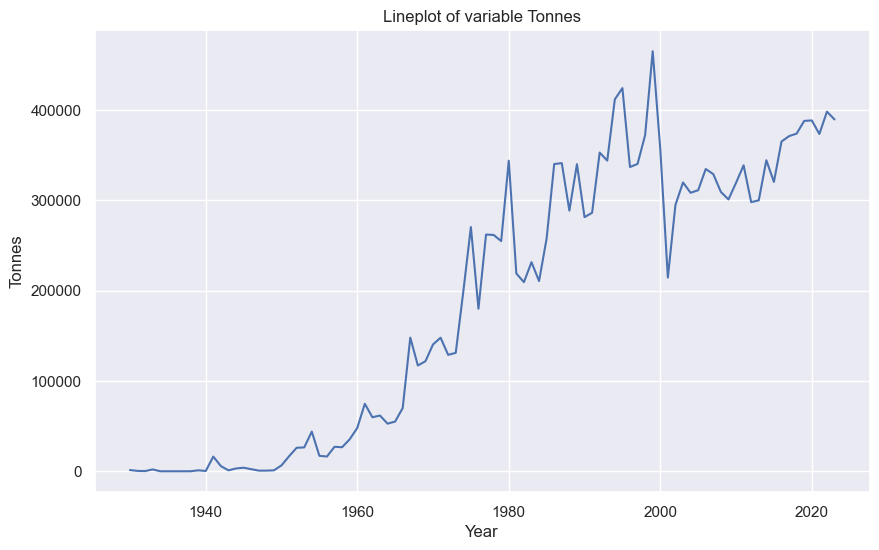

In [323]:
# plotting lineplot of variable "Tonnes"
plt.figure(figsize=(10, 6))
sns.lineplot(data = df_beef_exports, x = "Year", y = "Tonnes")
plt.ylabel ("Tonnes")
plt.title("Lineplot of variable Tonnes")

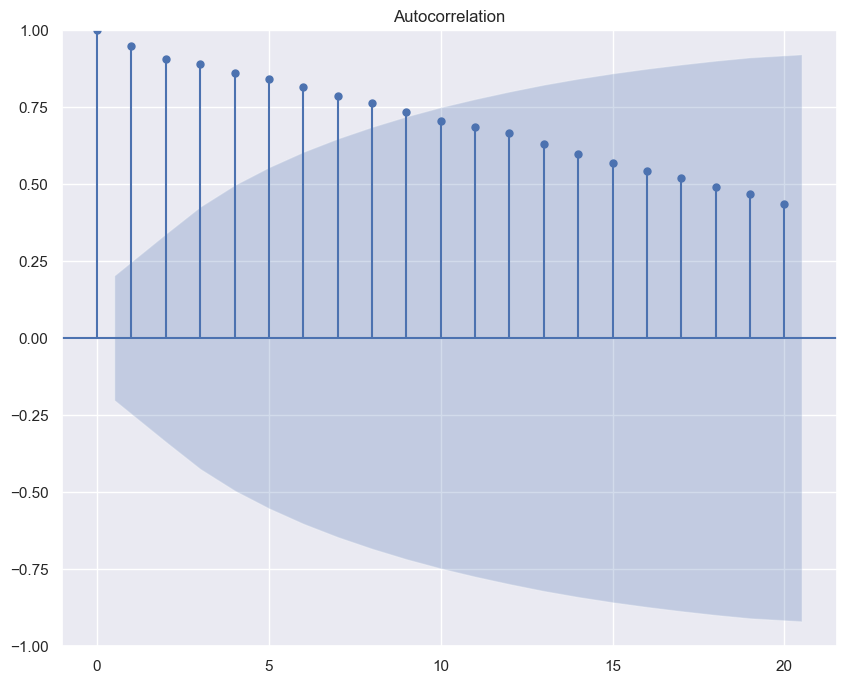

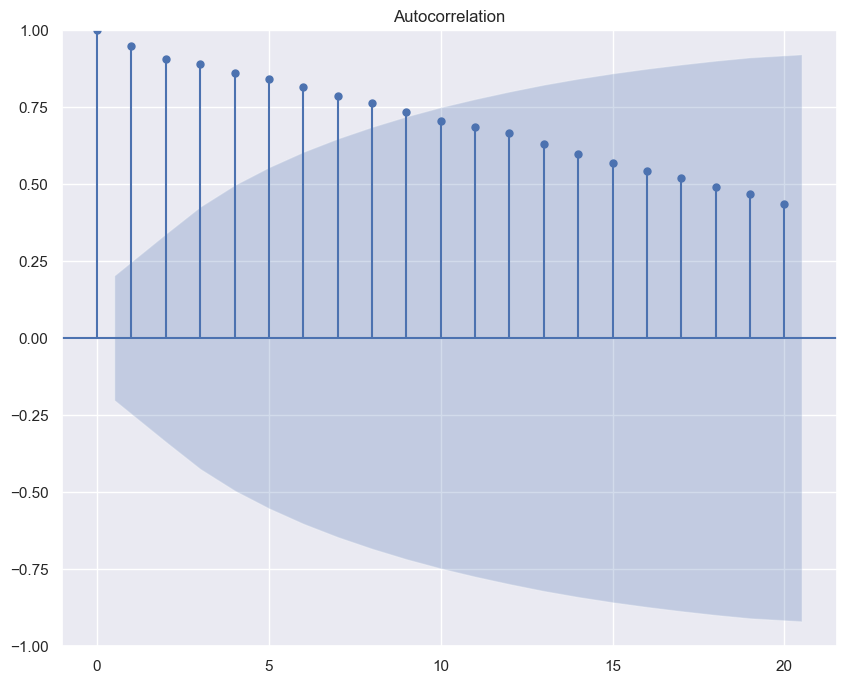

In [324]:
plot_acf(df_beef_exports["Tonnes"])

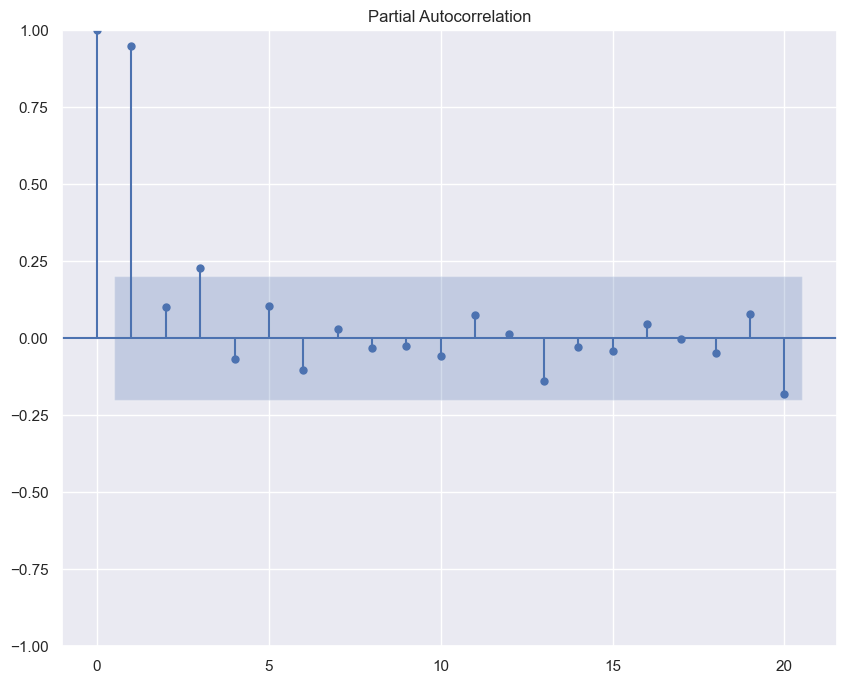

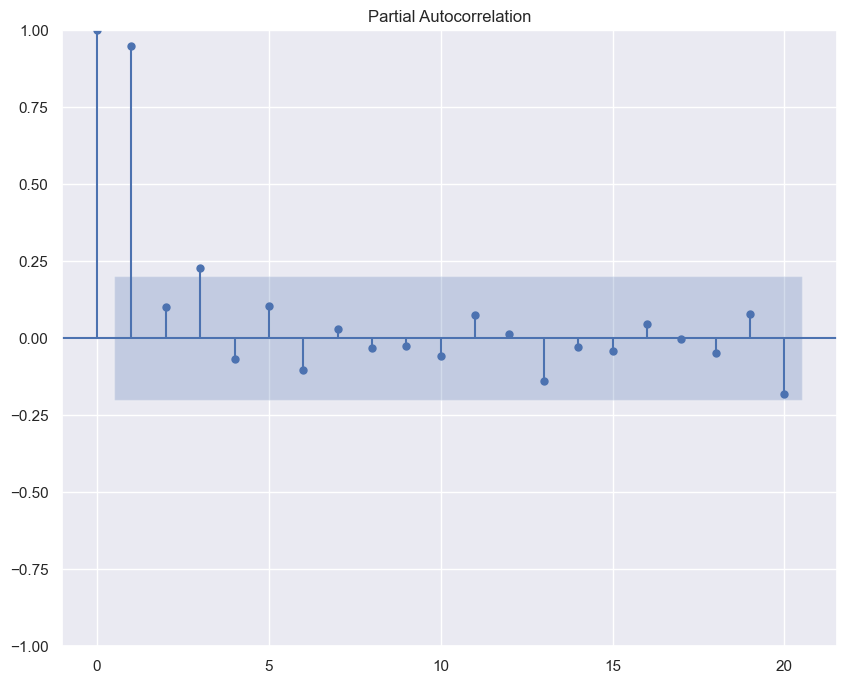

In [325]:
plot_pacf(df_beef_exports["Tonnes"])

In [326]:
model = ARIMA(df_beef_exports["Tonnes"], order=(1, 1, 1))

C:\Users\zygis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\zygis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\zygis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.



In [327]:
model_fit = model.fit()

In [328]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                 Tonnes   No. Observations:                   94
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1113.131
Date:                Sun, 29 Dec 2024   AIC                           2232.262
Time:                        23:35:38   BIC                           2239.860
Sample:                             0   HQIC                          2235.330
                                 - 94                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2687      0.178      1.507      0.132      -0.081       0.618
ma.L1         -0.6219      0.150     -4.157      0.000      -0.915      -0.329
sigma2      1.608e+09   1.35e-10    1.2e+19      0.000    1.61e+09    1.61e+09
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                73.71
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):              19.88   Skew:                            -0.54
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.22
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.69e+34. Standard errors may be unstable.
"""

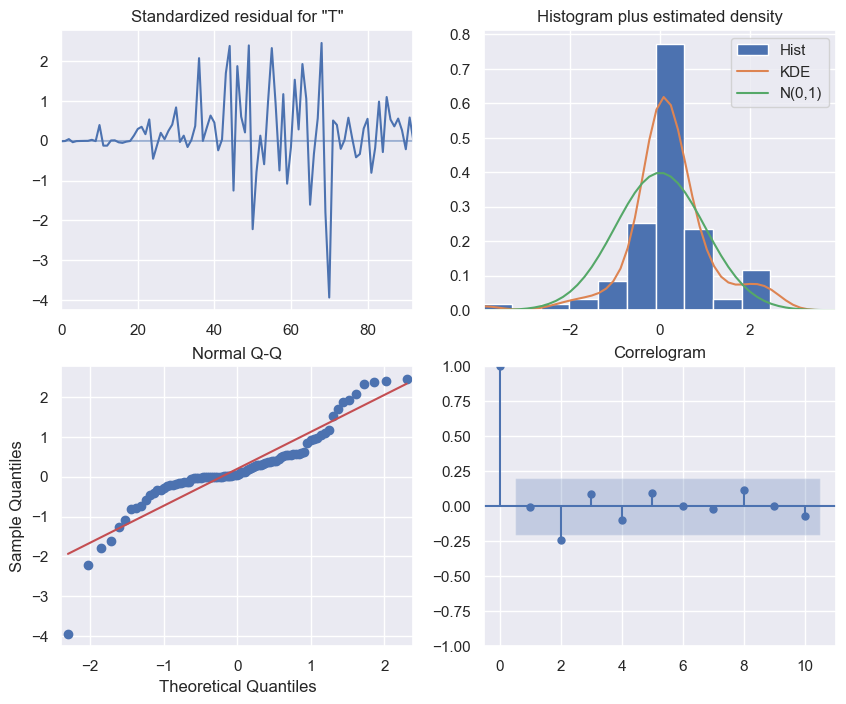

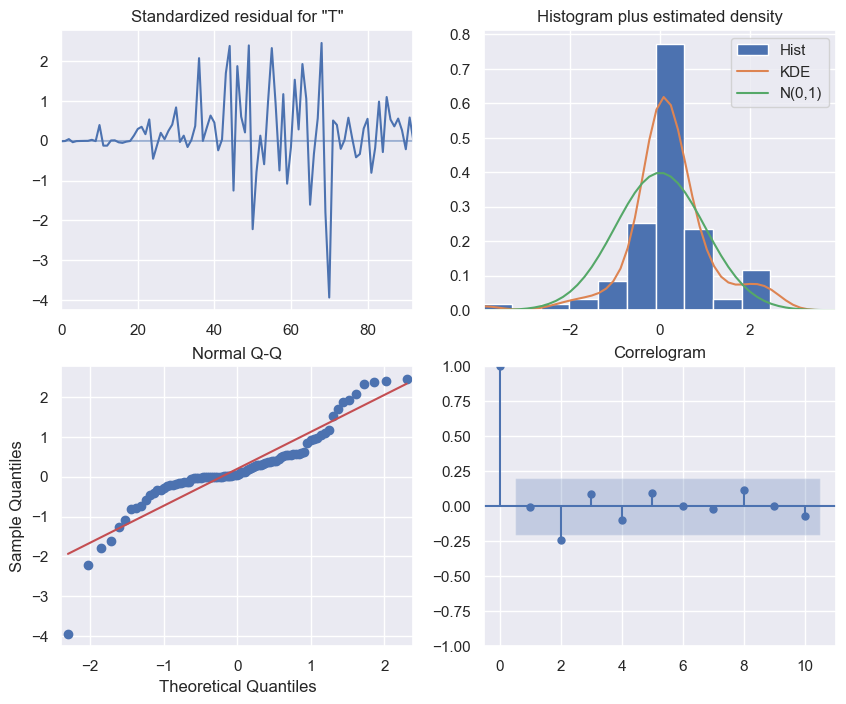

In [329]:
model_fit.plot_diagnostics(figsize=(10, 8))

With model built, forecasting is next.

In [331]:
# setting 1 step forecast as condition
forecast_values = model_fit.get_forecast(steps=1)  

C:\Users\zygis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.



In [332]:
# accessing last 10th observation
df_beef_exports.iloc[-10]

Statistic Label    Exports of Beef
Year                          2014
Tonnes                      344400
Name: 178, dtype: object

In [333]:
# extracting forecasted values
forecast_values.predicted_mean

94    387706.149482
dtype: float64

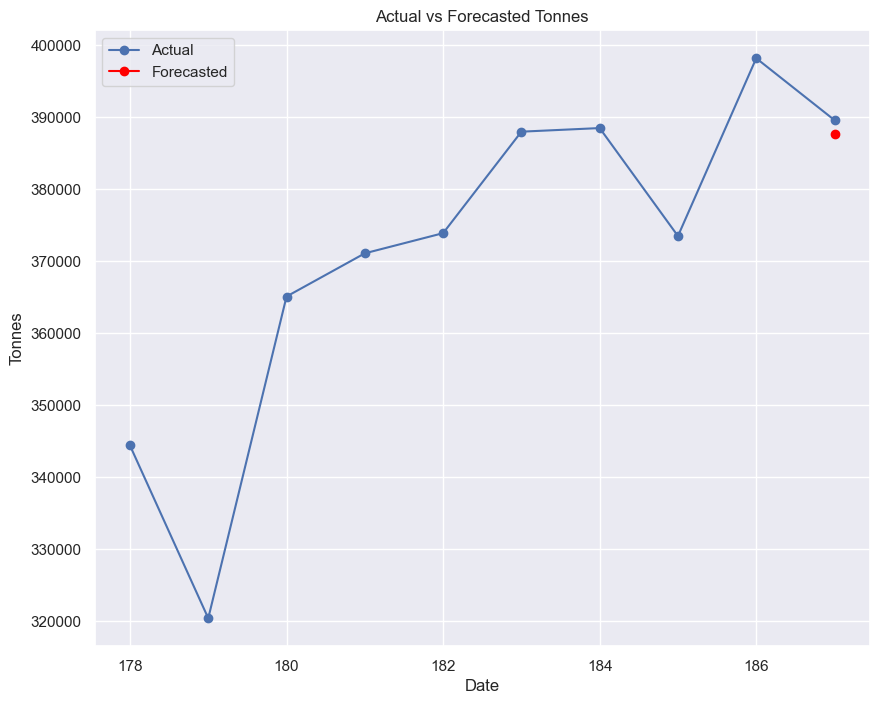

In [334]:
# plotting Actual vs Forecasted values
df_beef_exports.iloc[-10:].plot(y="Tonnes", marker="o", linestyle="-", label="Actual")

plt.plot(df_beef_exports.index[-1], forecast_values.predicted_mean, marker="o", color="red", label="Forecasted")


plt.xlabel("Date")
plt.ylabel("Tonnes")
plt.title("Actual vs Forecasted Tonnes")
plt.legend()

plt.show()

In [335]:
# calculating mean absolute error
forecasted_value = forecast_values.predicted_mean

actual_value = df_beef_exports.iloc[-1]["Tonnes"]

mae = mean_absolute_error([actual_value], [forecasted_value])

print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 1893.850518033083


<span style="color: blue;">

### 5.2. K-Means Clustering <a class="anchor" id="17th-bullet"></a>
    
</span>

In [337]:
# reminding of the dataframe used for clustering
df_worldwide__last5years_scaled.head()

,Area,Tonnes,Value in USD
0,Afghanistan,1.555125e-06,1.121079e-06
1,Albania,1.553430e-07,2.195928e-07
2,Algeria,4.695313e-06,2.565768e-06
3,Angola,1.903658e-07,6.934509e-08
4,Antigua and Barbuda,6.676925e-07,2.427078e-07


In [338]:
# picking target variables
features = df_worldwide__last5years_scaled[["Tonnes", "Value in USD"]]

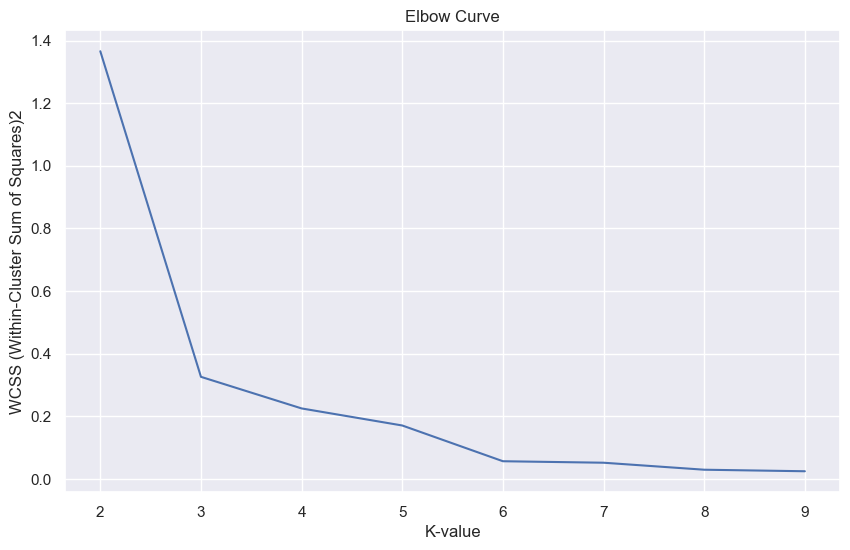

In [339]:
# plotting Elbow curve
wcss = []

plt.figure(figsize=(10, 6))
for k in range(2, 10):
    kmeans = KMeans(n_clusters = k, random_state=42)
    kmeans.fit(features)
    wcss.append(kmeans.inertia_)
    
plt.plot(range(2,10), wcss)
plt.title("Elbow Curve")
plt.xlabel("K-value")
plt.ylabel("WCSS (Within-Cluster Sum of Squares)2")
plt.show();

In [340]:
# calculating silhouette scores
silhouette_scores = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    y_kmeans = kmeans.fit_predict(features)
    score = silhouette_score(features, y_kmeans)
    silhouette_scores.append(score)
    print(f"The silhouette score for {k} clusters is: {score}")

The silhouette score for 2 clusters is: 0.940585576508479
The silhouette score for 3 clusters is: 0.9113650814664237
The silhouette score for 4 clusters is: 0.8970586903309787
The silhouette score for 5 clusters is: 0.8728086767081457
The silhouette score for 6 clusters is: 0.8705977728373814
The silhouette score for 7 clusters is: 0.8567207481167576
The silhouette score for 8 clusters is: 0.8570859910365055
The silhouette score for 9 clusters is: 0.850737334434165


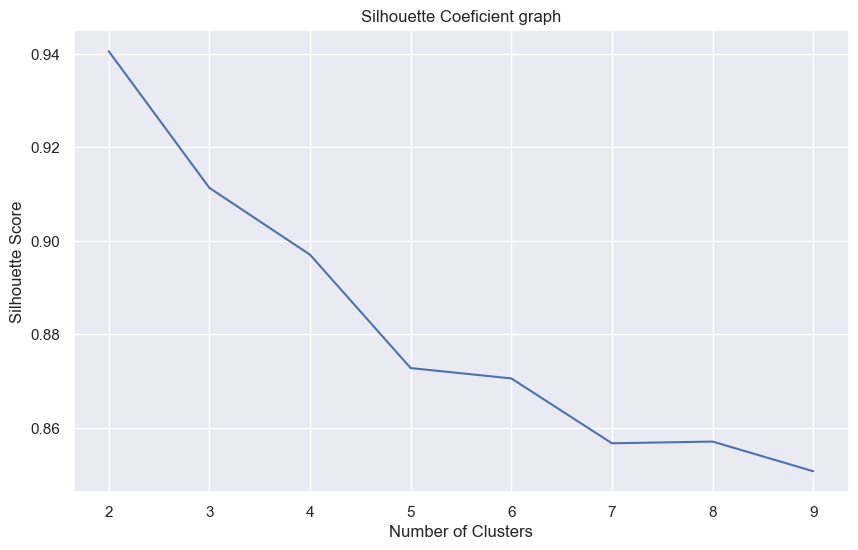

In [341]:
# plotting silhouette Coeficient graph
plt.figure(figsize=(10, 6))
plt.plot(range(2, 10), silhouette_scores)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Coeficient graph")
plt.show()

Number of ideal clusters is now set at 2

In [343]:
# fitting K-Means algorithm with 2 clusters
kmeans = KMeans(n_clusters = 2, random_state=42)
y_kmeans = kmeans.fit_predict(features)
df_worldwide__last5years_scaled["Cluster"] = y_kmeans
df_worldwide__last5years_scaled.head()

,Area,Tonnes,Value in USD,Cluster
0,Afghanistan,1.555125e-06,1.121079e-06,0
1,Albania,1.553430e-07,2.195928e-07,0
2,Algeria,4.695313e-06,2.565768e-06,0
3,Angola,1.903658e-07,6.934509e-08,0
4,Antigua and Barbuda,6.676925e-07,2.427078e-07,0


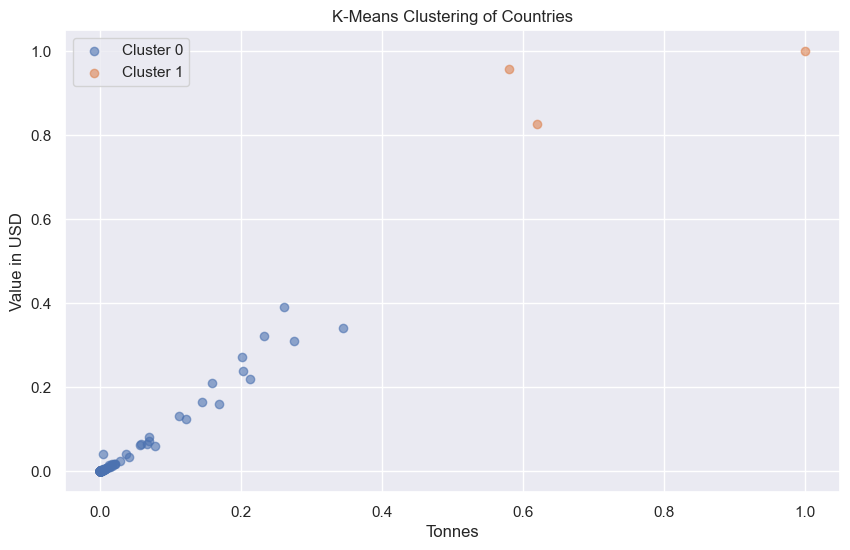

In [344]:
# visualising clusters using scatterplot
plt.figure(figsize=(10, 6))

for cluster in sorted(df_worldwide__last5years_scaled["Cluster"].unique()):
    plt.scatter(df_worldwide__last5years_scaled.loc[df_worldwide__last5years_scaled["Cluster"] == cluster, "Tonnes"],
                df_worldwide__last5years_scaled.loc[df_worldwide__last5years_scaled["Cluster"] == cluster, "Value in USD"],
                label=f'Cluster {cluster}', alpha=0.6)

# adding axis labels and title
plt.xlabel("Tonnes")
plt.ylabel("Value in USD")
plt.title("K-Means Clustering of Countries")
plt.legend()
plt.grid(True)
plt.show()

Next graph is to have a look, where Ireland is, how far from the leaders.

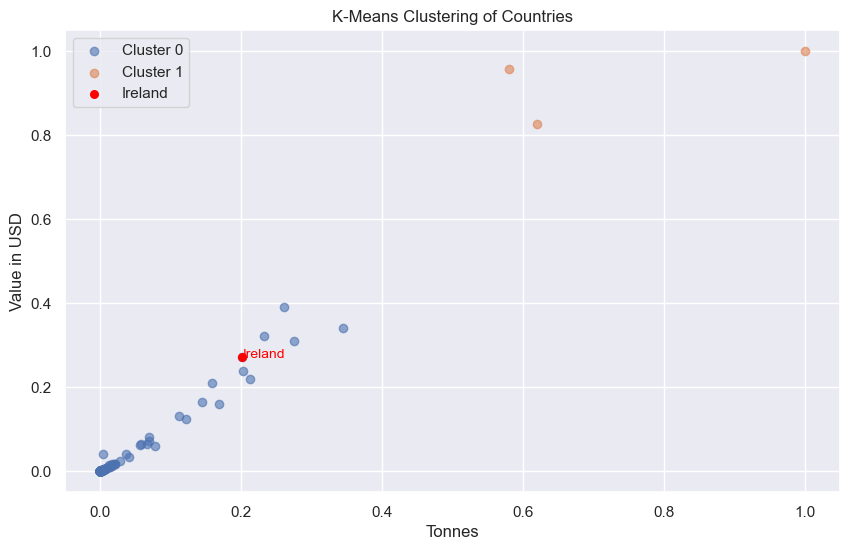

In [346]:
# plotting the graph
plt.figure(figsize=(10, 6))

for cluster in sorted(df_worldwide__last5years_scaled["Cluster"].unique()):
    plt.scatter(df_worldwide__last5years_scaled.loc[df_worldwide__last5years_scaled["Cluster"] == cluster, "Tonnes"],
                df_worldwide__last5years_scaled.loc[df_worldwide__last5years_scaled["Cluster"] == cluster, "Value in USD"],
                label=f'Cluster {cluster}', alpha=0.6)

# highlighting Ireland
ireland_row = df_worldwide__last5years_scaled[df_worldwide__last5years_scaled["Area"] == "Ireland"]
if not ireland_row.empty:
    plt.scatter(ireland_row["Tonnes"], ireland_row["Value in USD"], color="red", s=30, label="Ireland")
    plt.text(ireland_row["Tonnes"].values[0], ireland_row["Value in USD"].values[0], "Ireland", fontsize=10, color="red")

# adding axis labels and title
plt.xlabel("Tonnes")
plt.ylabel("Value in USD")
plt.title("K-Means Clustering of Countries")
plt.legend()
plt.grid(True)
plt.show()

In [347]:
# finding out who the leaders are in global beef market
leaders = df_worldwide__last5years_scaled[df_worldwide__last5years_scaled["Cluster"] == 1]
print(leaders)

                         Area    Tonnes  Value in USD  Cluster
7                   Australia  0.620490      0.827295        1
22                     Brazil  1.000000      1.000000        1
153  United States of America  0.580099      0.958852        1


<span style="color: blue;">

### 5.2.1. Grid Search and Hyperparameter tuning <a class="anchor" id="20th-bullet"></a>
    
</span>

In [349]:
# define the hyperparameter grid
param_grid = {
    'n_clusters': range(2, 11),         
    'init': ['k-means++', 'random'],    
    'max_iter': [100, 300, 500]        }

In [350]:
# initialize storage for results
results = []

# perform Grid Search
for n_clusters in param_grid['n_clusters']:
    for init in param_grid['init']:
        for max_iter in param_grid['max_iter']:
            # fit KMeans with the current set of parameters
            kmeans = KMeans(n_clusters=n_clusters, init=init, max_iter=max_iter, random_state=42)
            labels = kmeans.fit_predict(features)
            
            # calculate silhouette score
            score = silhouette_score(features, labels)
            
            # store results
            results.append({
                'n_clusters': n_clusters,
                'init': init,
                'max_iter': max_iter,
                'silhouette_score': score
            })

In [351]:
# converting results to DataFrame for analysis
results_df = pd.DataFrame(results)

# displaying the results
print("Grid Search Results:")
print(results_df)

Grid Search Results:
    n_clusters       init  max_iter  silhouette_score
0            2  k-means++       100          0.940586
1            2  k-means++       300          0.940586
2            2  k-means++       500          0.940586
3            2     random       100          0.940586
4            2     random       300          0.940586
5            2     random       500          0.940586
6            3  k-means++       100          0.911365
7            3  k-means++       300          0.911365
8            3  k-means++       500          0.911365
9            3     random       100          0.912280
10           3     random       300          0.912280
11           3     random       500          0.912280
12           4  k-means++       100          0.897059
13           4  k-means++       300          0.897059
14           4  k-means++       500          0.897059
15           4     random       100          0.883652
16           4     random       300          0.883652
17     

In [352]:
# Find the best combination of hyperparameters
best_params = results_df.loc[results_df['silhouette_score'].idxmax()]
print(f"Best Parameters:\n{best_params}")

Best Parameters:
n_clusters                  2
init                k-means++
max_iter                  100
silhouette_score     0.940586
Name: 0, dtype: object


In [353]:
# Apply KMeans with the best parameters
optimal_kmeans = KMeans(
    n_clusters=int(best_params['n_clusters']),
    init=best_params['init'],
    max_iter=int(best_params['max_iter']),
    random_state=42
)
df_worldwide__last5years_scaled['Cluster'] = optimal_kmeans.fit_predict(features)


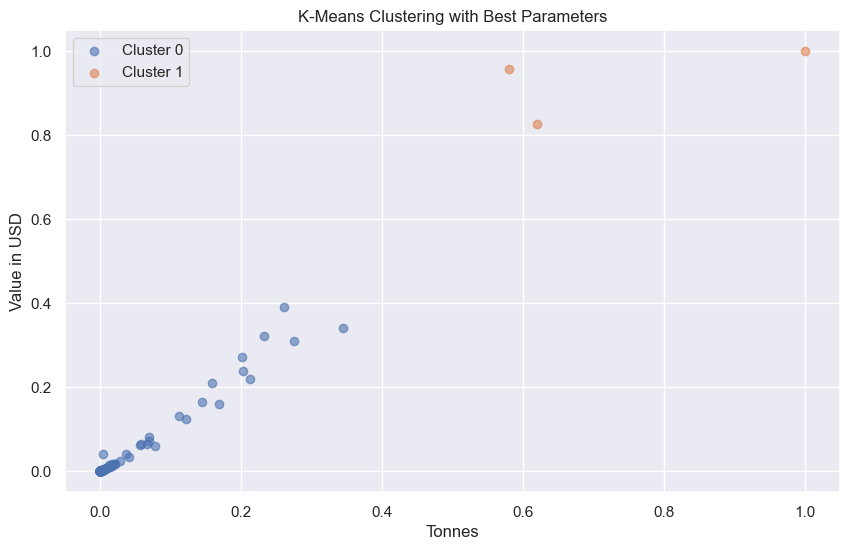

In [354]:
plt.figure(figsize=(10, 6))
for cluster in sorted(df_worldwide__last5years_scaled['Cluster'].unique()):
    plt.scatter(df_worldwide__last5years_scaled.loc[df_worldwide__last5years_scaled['Cluster'] == cluster, 'Tonnes'],
                df_worldwide__last5years_scaled.loc[df_worldwide__last5years_scaled['Cluster'] == cluster, 'Value in USD'],
                label=f'Cluster {cluster}', alpha=0.6)

plt.xlabel("Tonnes")
plt.ylabel("Value in USD")
plt.title(f"K-Means Clustering with Best Parameters")
plt.legend()
plt.grid(True)
plt.show()

<span style="color: blue;">

### 5.3. Sentiment Analysis <a class="anchor" id="16th-bullet"></a>
    
</span>

In [356]:
df_reddit.head()

,Comment
1,"One is from Britain, and one is from Ireland"
2,Before they are slaughtered the British Beef makes a Mooing sound the Irish Beef cows make a distinctive Mo'Oing sound.
3,"These 🐄 🇬🇧 are small, but those 🐄 🇮🇪 are far away... Small, far away."
4,Depends what you mean by historical beef
5,"One is reared by the shore, the other is reared by the sure to be sure"


Text contains emojis. To find all the emojis within the text .findall function from regular expressions module is used.

In [358]:
# defining function to go through the comments
def extract_emojis(text):
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"  
        "\U0001F300-\U0001F5FF"  
        "\U0001F680-\U0001F6FF"  
        "\U0001F1E0-\U0001F1FF"  
        "\U00002600-\U000026FF"  
        "\U00002700-\U000027BF"  
        "\U0001F900-\U0001F9FF"  
        "\U0001FA70-\U0001FAFF"  
        "\U0001F100-\U0001F1FF"  
        "]+",
        flags=re.UNICODE,
    )
    return emoji_pattern.findall(str(text))

# extracting emojis from all comments
emoji_list = []
for comment in df_reddit["Comment"]:
    emojis = extract_emojis(comment)
    emoji_list.extend(emojis)

# unique emojis
unique_emojis = set(emoji_list)

# printing the unique emojis
print("Unique emojis in the dataset:")
print(unique_emojis)

Unique emojis in the dataset:
{'🇮🇪', '🙂', '🤣', '😉', '🇬🇧', '🐄'}


In [359]:
def remove_emojis(text):
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"  
        "\U0001F300-\U0001F5FF"  
        "\U0001F680-\U0001F6FF"  
        "\U0001F1E0-\U0001F1FF"  
        "\U00002600-\U000026FF"  
        "\U00002700-\U000027BF"  
        "\U0001F900-\U0001F9FF"  
        "\U0001FA70-\U0001FAFF"  
        "\U0001F100-\U0001F1FF"  
        "]+",
        flags=re.UNICODE,
    )
    return emoji_pattern.sub(r"", str(text))  

# applying the function
df_reddit["Comment"] = df_reddit["Comment"].apply(remove_emojis)

In [360]:
df_reddit["Word Count Before"] = df_reddit["Comment"].apply(lambda x: len(str(x).split(" ")))

In [361]:
df_reddit.head()

,Comment,Word Count Before
1,"One is from Britain, and one is from Ireland",9
2,Before they are slaughtered the British Beef makes a Mooing sound the Irish Beef cows make a distinctive Mo'Oing sound.,20
3,"These are small, but those are far away... Small, far away.",15
4,Depends what you mean by historical beef,7
5,"One is reared by the shore, the other is reared by the sure to be sure",16


In [362]:
stop = stopwords.words("english")
df_reddit["Comment"] = df_reddit["Comment"].apply(lambda x: " ".join(x for x in x.split() if x not in stop))
df_reddit.head()

,Comment,Word Count Before
1,"One Britain, one Ireland",9
2,Before slaughtered British Beef makes Mooing sound Irish Beef cows make distinctive Mo'Oing sound.,20
3,"These small, far away... Small, far away.",15
4,Depends mean historical beef,7
5,"One reared shore, reared sure sure",16


In [363]:
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stop]
    return ' '.join(filtered_words)
df_reddit["Without_stopwords"] = df_reddit["Comment"].apply(remove_stopwords)

In [364]:
df_reddit.head()

,Comment,Word Count Before,Without_stopwords
1,"One Britain, one Ireland",9,"One Britain, one Ireland"
2,Before slaughtered British Beef makes Mooing sound Irish Beef cows make distinctive Mo'Oing sound.,20,slaughtered British Beef makes Mooing sound Irish Beef cows make distinctive Mo'Oing sound.
3,"These small, far away... Small, far away.",15,"small, far away... Small, far away."
4,Depends mean historical beef,7,Depends mean historical beef
5,"One reared shore, reared sure sure",16,"One reared shore, reared sure sure"


In [365]:
df_reddit["Word Count After"] = df_reddit["Without_stopwords"].apply(lambda x: len(str(x).split(" ")))

In [366]:
df_reddit.head()

,Comment,Word Count Before,Without_stopwords,Word Count After
1,"One Britain, one Ireland",9,"One Britain, one Ireland",4
2,Before slaughtered British Beef makes Mooing sound Irish Beef cows make distinctive Mo'Oing sound.,20,slaughtered British Beef makes Mooing sound Irish Beef cows make distinctive Mo'Oing sound.,13
3,"These small, far away... Small, far away.",15,"small, far away... Small, far away.",6
4,Depends mean historical beef,7,Depends mean historical beef,4
5,"One reared shore, reared sure sure",16,"One reared shore, reared sure sure",6


This is how the table looks with stopwords remowed. Lemmatisation next. Lemmatisation involves tokenising the whole text into individual words, then lemmatising each word and finally joining lemmatised words back into sentences.

In [368]:
lemmatizer = WordNetLemmatizer()


def get_wordnet_pos(tag):
    if tag.startswith("J"):
        return wordnet.ADJ  
    elif tag.startswith("V"):
        return wordnet.VERB  
    elif tag.startswith("N"):
        return wordnet.NOUN  
    elif tag.startswith("R"):
        return wordnet.ADV  
    else:
        return wordnet.NOUN  


def lemmatize_text(text):
    if not isinstance(text, str):
        return ""  
    words = word_tokenize(text)  
    pos_tags = pos_tag(words)  
    lemmatized_words = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in pos_tags]
    return " ".join(lemmatized_words) 


df_reddit["Lemmatized_text"] = df_reddit["Without_stopwords"].apply(lemmatize_text)

In [369]:
df_reddit.tail(20)

,Comment,Word Count Before,Without_stopwords,Word Count After,Lemmatized_text
131,Regulations largely drafted still law mean.,7,Regulations largely drafted still law mean.,6,Regulations largely draft still law mean .
132,Fish potatoes. Irish cows fed fish chips.,11,Fish potatoes. Irish cows fed fish chips.,7,Fish potato . Irish cow feed fish chip .
133,They eat fish chips. Fridays though. It’s weekly treat.,12,eat fish chips. Fridays though. It’s weekly treat.,8,eat fish chip . Fridays though . It ’ s weekly treat .
134,Hope didn’t call Saturday 3 3:15 he’s spending QT son goes back cupboard,27,Hope didn’t call Saturday 3 3:15 he’s spending QT son goes back cupboard,13,Hope didn ’ t call Saturday 3 3:15 he ’ s spending QT son go back cupboard
136,Lol.,1,Lol.,1,Lol .
137,And normal scrabble. Travel we're travelling normal got here.,17,normal scrabble. Travel we're travelling normal got here.,8,normal scrabble . Travel we 're travel normal get here .
138,"Is smaller, you’re far away?",8,"smaller, you’re far away?",4,"small , you ’ re far away ?"
139,"Neither us decades, though.",8,"Neither us decades, though.",4,"Neither u decade , though ."
140,"Oh mate it’s incredible, I understand it’s everywhere, like they’re open 9am-4pm, Monday Saturday, people busy lives work hours it’s convenient supermarkets necessary, amazing. I bought heavy fuck pack beef short ribs Saturday, 4/5 I think £2.99, ended getting 4 I could freeze 3 use packet immediately get much meat them. Honestly new favourite cut beef",95,"Oh mate it’s incredible, understand it’s everywhere, like they’re open 9am-4pm, Monday Saturday, people busy lives work hours it’s convenient supermarkets necessary, amazing. bought heavy fuck pack beef short ribs Saturday, 4/5 think £2.99, ended getting 4 could freeze 3 use packet immediately get much meat them. Honestly new favourite cut beef",52,"Oh mate it ’ s incredible , understand it ’ s everywhere , like they ’ re open 9am-4pm , Monday Saturday , people busy life work hour it ’ s convenient supermarket necessary , amazing . buy heavy fuck pack beef short rib Saturday , 4/5 think £2.99 , end get 4 could freeze 3 use packet immediately get much meat them . Honestly new favourite cut beef"
142,Or British standard demonym anything United Kingdom,14,British standard demonym anything United Kingdom,6,British standard demonym anything United Kingdom


In [370]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
sentiment = SentimentIntensityAnalyzer()
text_1 = "One rear shore , reared sure sure"
text_2 =  "Regulations largely draft still law mean"
sent_1 = sentiment.polarity_scores(text_1)
sent_2 = sentiment.polarity_scores(text_2)
print("Sentiment of text 1:", sent_1)
print("Sentiment of text 2:", sent_2)

Sentiment of text 1: {'neg': 0.0, 'neu': 0.521, 'pos': 0.479, 'compound': 0.5574}
Sentiment of text 2: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}


In [371]:
sentiment_labels = []
for text in df_reddit["Lemmatized_text"]:
    sentiment_scores = sentiment.polarity_scores(text)
    compound_score = sentiment_scores['compound']
    if compound_score >= 0.2:
        sentiment_labels.append('Positive')
    elif compound_score <= -0.2:
        sentiment_labels.append('Negative')
    else:
        sentiment_labels.append('Neutral')

In [372]:
df_reddit.shape

(142, 5)

In [373]:
df_reddit["sentiment"] = sentiment_labels

In [374]:
df_reddit.head()

,Comment,Word Count Before,Without_stopwords,Word Count After,Lemmatized_text,sentiment
1,"One Britain, one Ireland",9,"One Britain, one Ireland",4,"One Britain , one Ireland",Neutral
2,Before slaughtered British Beef makes Mooing sound Irish Beef cows make distinctive Mo'Oing sound.,20,slaughtered British Beef makes Mooing sound Irish Beef cows make distinctive Mo'Oing sound.,13,slaughtered British Beef make Mooing sound Irish Beef cow make distinctive Mo'Oing sound .,Neutral
3,"These small, far away... Small, far away.",15,"small, far away... Small, far away.",6,"small , far away ... Small , far away .",Neutral
4,Depends mean historical beef,7,Depends mean historical beef,4,Depends mean historical beef,Neutral
5,"One reared shore, reared sure sure",16,"One reared shore, reared sure sure",6,"One rear shore , reared sure sure",Positive


In [375]:
df_original = pd.read_csv("reddit_comments.csv")

In [376]:
df_original.head()

,Author,Comment
0,AutoModerator,"**Please help keep AskUK welcoming!**\n\n- Top-level comments to the OP must contain **genuine efforts to answer the question**. No jokes, judgements, etc.\n\n- **Don't be a dick** to each other. If getting heated, just block and move on.\n\n- This is a strictly **no-politics** subreddit!\n \nPlease help us by reporting comments that break these rules.\n\n*I am a bot, and this action was performed automatically. Please [contact the moderators of this subreddit](/message/compose/?to=/r/AskUK) if you have any questions or concerns.*"
1,boldstrategy,"One is from Britain, and one is from Ireland"
2,BrunniFlat7,Before they are slaughtered the British Beef makes a Mooing sound the Irish Beef cows make a distinctive Mo'Oing sound.
3,YchYFi,"These 🐄 🇬🇧 are small, but those 🐄 🇮🇪 are far away... Small, far away."
4,Tennents-Shagger,Depends what you mean by historical beef


In [377]:
sentiment_labels = []
for text in df_original["Comment"]:
    sentiment_scores = sentiment.polarity_scores(text)
    compound_score = sentiment_scores['compound']
    if compound_score >= 0.2:
        sentiment_labels.append('Positive')
    elif compound_score <= -0.2:
        sentiment_labels.append('Negative')
    else:
        sentiment_labels.append('Neutral')

In [378]:
df_original["sentiment"] = sentiment_labels

In [379]:
df_original.head()

,Author,Comment,sentiment
0,AutoModerator,"**Please help keep AskUK welcoming!**\n\n- Top-level comments to the OP must contain **genuine efforts to answer the question**. No jokes, judgements, etc.\n\n- **Don't be a dick** to each other. If getting heated, just block and move on.\n\n- This is a strictly **no-politics** subreddit!\n \nPlease help us by reporting comments that break these rules.\n\n*I am a bot, and this action was performed automatically. Please [contact the moderators of this subreddit](/message/compose/?to=/r/AskUK) if you have any questions or concerns.*",Positive
1,boldstrategy,"One is from Britain, and one is from Ireland",Neutral
2,BrunniFlat7,Before they are slaughtered the British Beef makes a Mooing sound the Irish Beef cows make a distinctive Mo'Oing sound.,Neutral
3,YchYFi,"These 🐄 🇬🇧 are small, but those 🐄 🇮🇪 are far away... Small, far away.",Neutral
4,Tennents-Shagger,Depends what you mean by historical beef,Neutral


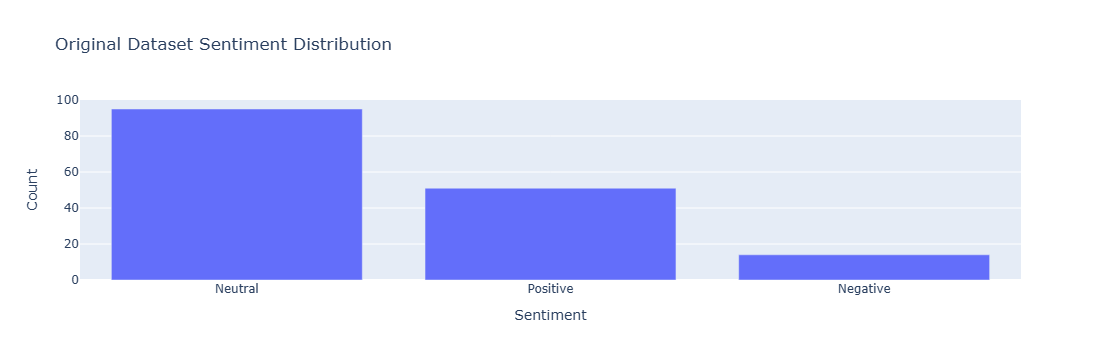

In [380]:
sentiment_counts = df_original['sentiment'].value_counts()
fig = px.bar(sentiment_counts, x=sentiment_counts.index.tolist(), y=sentiment_counts.values,
             labels={'x': 'Sentiment', 'y': 'Count'}, title="Original Dataset Sentiment Distribution")
fig.show()

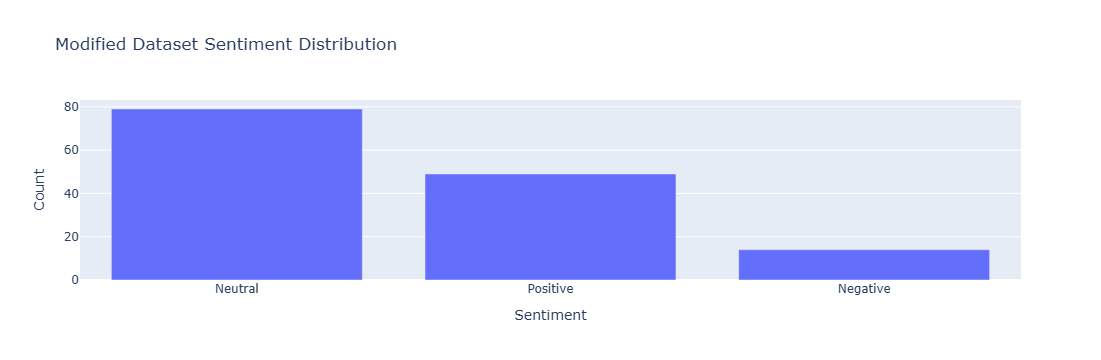

In [381]:
sentiment_counts = df_reddit['sentiment'].value_counts()
fig = px.bar(sentiment_counts, x=sentiment_counts.index.tolist(), y=sentiment_counts.values,
             labels={'x': 'Sentiment', 'y': 'Count'}, title="Modified Dataset Sentiment Distribution")
fig.show()

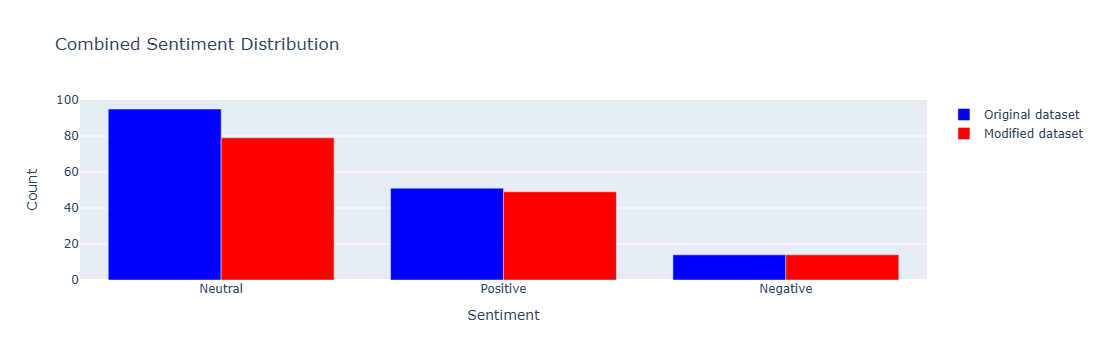

In [382]:
sentiment_counts1 = df_original['sentiment'].value_counts()
fig1 = go.Figure()
fig1.add_trace(go.Bar(x=sentiment_counts1.index, y=sentiment_counts1.values,
                      name="Original dataset", marker_color="blue"))
sentiment_counts2 = df_reddit['sentiment'].value_counts()
fig2 = go.Figure()
fig2.add_trace(go.Bar(x=sentiment_counts2.index, y=sentiment_counts2.values,
                      name="Modified dataset", marker_color="red"))

combined = go.Figure(fig1.data + fig2.data)
combined.update_layout(barmode="group",
                           xaxis_title="Sentiment",
                           yaxis_title="Count",
                           title="Combined Sentiment Distribution")

combined.show()

<span style="color: blue;">

### 5.4. Machine Learning Models <a class="anchor" id="14th-bullet"></a>
    
</span>

Dataset picked for Machine Learning regression analysis is df_EU_exports_merged.

In [385]:
df_EU_exports_merged.head()

,Area,Population,Item,Year,Value (In USD),Per Capita,Tonnes,Price per Tonne,Flag,Flag Description
0,Austria,7086299,"Meat of cattle boneless, fresh or chilled",1961,0,0.0,0.0,NaN,A,Official figure
1,Austria,7129864,"Meat of cattle boneless, fresh or chilled",1962,0,0.0,0.0,NaN,A,Official figure
2,Austria,7175811,"Meat of cattle boneless, fresh or chilled",1963,0,0.0,0.0,NaN,A,Official figure
3,Austria,7223801,"Meat of cattle boneless, fresh or chilled",1964,0,0.0,0.0,NaN,A,Official figure
4,Austria,7270889,"Meat of cattle boneless, fresh or chilled",1965,0,0.0,0.0,NaN,A,Official figure


In [386]:
df_EU_exports_merged.shape

(1310, 10)

In [387]:
df_EU_exports_merged.isnull().sum()

Area                  0
Population            0
Item                  0
Year                  0
Value (In USD)        0
Per Capita            0
Tonnes                0
Price per Tonne     279
Flag                  0
Flag Description      0
dtype: int64

Dataset contains missing values, so they are filled using median value, that was calculated during that year.

In [389]:
# filling missing values
df_EU_exports_merged["Price per Tonne"] = df_EU_exports_merged.groupby("Year")["Price per Tonne"].transform(
    lambda x: x.fillna(x.median()))


In [390]:
df_EU_exports_merged.isnull().sum()

Area                0
Population          0
Item                0
Year                0
Value (In USD)      0
Per Capita          0
Tonnes              0
Price per Tonne     0
Flag                0
Flag Description    0
dtype: int64

In [391]:
# getting statistical values before deciding on scaling method
df_EU_exports_merged.describe()

,Population,Year,Value (In USD),Per Capita,Tonnes,Price per Tonne
count,1.310000e+03,1310.000000,1.310000e+03,1310.000000,1310.000000,1310.000000
mean,1.789506e+07,1995.790076,1.427199e+08,15.033967,30384.733244,3848.225415
std,2.207448e+07,17.930501,3.639415e+08,53.146563,63887.783453,2582.773986
min,3.019960e+05,1961.000000,0.000000e+00,0.000000,0.000000,375.000000
25%,4.275349e+06,1981.000000,6.200000e+04,0.016540,14.250000,2057.307320
50%,8.848518e+06,1998.000000,5.788000e+06,0.724668,1391.550000,3251.187246
75%,2.000278e+07,2011.000000,1.005210e+08,5.531613,33625.000000,5295.904388
max,8.379798e+07,2023.000000,2.910679e+09,485.001258,365746.000000,25592.417062


In [392]:
# deleting unnessecary columns
df_EU_exports_merged = df_EU_exports_merged.drop(columns=["Flag", "Flag Description", "Item"])

In [393]:
# looking at the encoded dataframe
df_ml_encoded = pd.get_dummies(data=df_EU_exports_merged, dtype=int, drop_first=True)
df_ml_encoded

,Population,Year,Value (In USD),Per Capita,Tonnes,Price per Tonne,Area_Belgium,Area_Bulgaria,Area_Croatia,Area_Cyprus,Area_Czechia,Area_Denmark,Area_Estonia,Area_Finland,Area_France,Area_Germany,Area_Greece,Area_Hungary,Area_Ireland,Area_Italy,Area_Latvia,Area_Lithuania,Area_Luxembourg,Area_Malta,Area_Netherlands,Area_Poland,Area_Portugal,Area_Romania,Area_Slovakia,Area_Slovenia,Area_Spain,Area_Sweden
0,7086299,1961,0,0.000000,0.00,696.722535,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,7129864,1962,0,0.000000,0.00,778.622744,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,7175811,1963,0,0.000000,0.00,780.616994,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,7223801,1964,0,0.000000,0.00,838.409128,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,7270889,1965,0,0.000000,0.00,1075.303523,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1305,10278887,2019,6614000,0.643455,810.59,8159.488767,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1306,10353442,2020,6469000,0.624816,812.77,7959.201250,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1307,10415811,2021,12133000,1.164864,1259.74,9631.352501,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1308,10486941,2022,12582000,1.199778,1235.04,10187.524291,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [394]:
# creating new dataframe for scaled data
df_ml_scaled = df_ml_encoded

In [395]:
df_ml_scaled.columns

Index(['Population', 'Year', 'Value (In USD)', 'Per Capita', 'Tonnes',
       'Price per Tonne', 'Area_Belgium', 'Area_Bulgaria', 'Area_Croatia',
       'Area_Cyprus', 'Area_Czechia', 'Area_Denmark', 'Area_Estonia',
       'Area_Finland', 'Area_France', 'Area_Germany', 'Area_Greece',
       'Area_Hungary', 'Area_Ireland', 'Area_Italy', 'Area_Latvia',
       'Area_Lithuania', 'Area_Luxembourg', 'Area_Malta', 'Area_Netherlands',
       'Area_Poland', 'Area_Portugal', 'Area_Romania', 'Area_Slovakia',
       'Area_Slovenia', 'Area_Spain', 'Area_Sweden'],
      dtype='object')

In [396]:
# scaling variable using MinMax scaler
df_ml_scaled["Population"]=preproc.minmax_scale(df_ml_scaled[["Population"]])
df_ml_scaled["Value (In USD)"]=preproc.minmax_scale(df_ml_scaled[["Value (In USD)"]])
df_ml_scaled["Per Capita"]=preproc.minmax_scale(df_ml_scaled[["Per Capita"]])
df_ml_scaled["Tonnes"]=preproc.minmax_scale(df_ml_scaled[["Tonnes"]])
df_ml_scaled["Price per Tonne"]=preproc.minmax_scale(df_ml_scaled[["Price per Tonne"]])

In [397]:
df_ml_scaled.head()

,Population,Year,Value (In USD),Per Capita,Tonnes,Price per Tonne,Area_Belgium,Area_Bulgaria,Area_Croatia,Area_Cyprus,Area_Czechia,Area_Denmark,Area_Estonia,Area_Finland,Area_France,Area_Germany,Area_Greece,Area_Hungary,Area_Ireland,Area_Italy,Area_Latvia,Area_Lithuania,Area_Luxembourg,Area_Malta,Area_Netherlands,Area_Poland,Area_Portugal,Area_Romania,Area_Slovakia,Area_Slovenia,Area_Spain,Area_Sweden
0,0.081253,1961,0.0,0.0,0.0,0.012758,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0.081775,1962,0.0,0.0,0.0,0.016006,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0.082325,1963,0.0,0.0,0.0,0.016085,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0.082900,1964,0.0,0.0,0.0,0.018377,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0.083464,1965,0.0,0.0,0.0,0.027771,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Defining target variable

In [399]:
# splitting the dataframe
X = df_ml_scaled.drop(columns=["Price per Tonne"]) 
y = df_ml_scaled["Price per Tonne"] 

In [400]:
# setting train-test size at 0.2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

### Linear Regression

In [402]:
# defining the model
def get_cv_scores(model):
    scores = cross_val_score(model,
                             X_train,
                             y_train,
                             cv = 10,
                             scoring="r2")
    
    print("CV Mean: ", np.mean(scores))
    print("STD: ", np.std(scores))
    print("\n")

In [403]:
# fitting the model
lr = LinearRegression().fit(X_train, y_train)
get_cv_scores(lr)

CV Mean:  0.6116905971557463
STD:  0.11430207559284489




In [404]:
# predicting the scores
y_pred_lr = lr.predict(X_test)

In [405]:
# printing Actual versus Predicted scored
df_results = pd.DataFrame({"Actual": y_test, "Predicted": y_pred_lr})
df_results.head(5)

,Actual,Predicted
701,0.231935,0.258739
994,0.169390,0.143837
350,0.086500,0.097747
986,0.080791,0.118748
409,0.047279,0.058905


In [406]:
# calculating main model errors
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

In [407]:
#  printing the results
print("Mean Absolute Error:", mae_lr)
print("Mean Squared Error:", mse_lr)
print("Root Mean Squared Error:", rmse_lr)
print("R-squared:", r2_lr)

Mean Absolute Error: 0.03934322743141507
Mean Squared Error: 0.004839333561536703
Root Mean Squared Error: 0.06956531866912351
R-squared: 0.582056242325956


### Bayesian Regression

In [409]:
bayesian_regression = BayesianRidge()

In [410]:
bayesian_regression.fit(X_train, y_train)

BayesianRidge()

In [411]:
y_pred_bay = bayesian_regression.predict(X_test)

In [412]:
mse_br = mean_squared_error(y_test, y_pred_bay)
rmse_br = np.sqrt(mse_br)
mae_br = mean_absolute_error(y_test, y_pred_bay)
r2_br = r2_score(y_test, y_pred_bay)

In [413]:
print("Mean Absolute Error:", mae_br)
print("Mean Squared Error:", mse_br)
print("Root Mean Squared Error:", rmse_br)
print("R-squared:", r2_br)

Mean Absolute Error: 0.03982369945513009
Mean Squared Error: 0.004899505478959854
Root Mean Squared Error: 0.0699964676177295
R-squared: 0.5768595603955833


### Random Forest

In [415]:
random_forest_regressor = RandomForestRegressor(random_state=42)

In [416]:
random_forest_regressor.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [417]:
y_pred_rf = random_forest_regressor.predict(X_test)

In [418]:
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

In [419]:
print("Mean Absolute Error:", mae_rf)
print("Mean Squared Error:", mse_rf)
print("Root Mean Squared Error:", rmse_rf)
print("R-squared:", r2_rf)

Mean Absolute Error: 0.021733220392774102
Mean Squared Error: 0.0016934486189929831
Root Mean Squared Error: 0.04115153240151554
R-squared: 0.8537471595520478


In [420]:
# for comparison of the results all the scores are brought into one subtable
mae_list = [mae_lr, mae_br, mae_rf]  
mse_list = [mse_lr, mse_br, mse_rf]  
rmse_list = [rmse_lr, rmse_br, rmse_rf]  
r2_list = [r2_lr, r2_br, r2_rf] 
models = ["Linear Regression", "Bayesian Ridge", "Random Forest"]
subtable = pd.DataFrame({
    'Model': models,
    'MAE': mae_list,
    "RMSE": rmse_list,
    "MSE": mse_list,
    "R2": r2_list})

borders = [
    {"selector": "td, th", "props": [("border", "2px solid black")]}
]

borders_subtable = subtable.style.set_table_styles(borders)

borders_subtable

,Model,MAE,RMSE,MSE,R2
0,Linear Regression,0.039343,0.069565,0.004839,0.582056
1,Bayesian Ridge,0.039824,0.069996,0.004900,0.576860
2,Random Forest,0.021733,0.041152,0.001693,0.853747


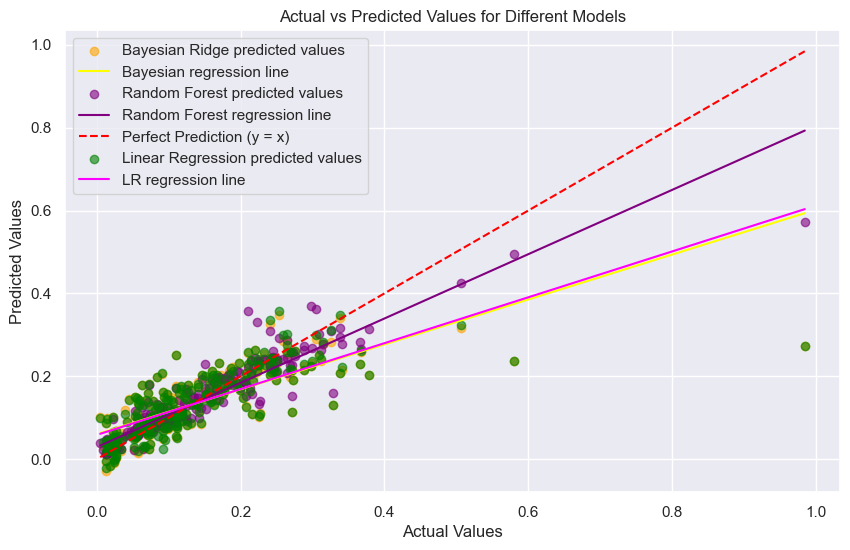

In [421]:
plt.figure(figsize=(10, 6))


plt.scatter(y_test, y_pred_bay, color="orange", alpha=0.6, label="Bayesian Ridge predicted values")

x_range = np.linspace(min(y_test), max(y_test), 100)
slope, intercept = np.polyfit(y_test, y_pred_bay, 1)
plt.plot(x_range, slope * x_range + intercept, color="yellow", linestyle="-", label="Bayesian regression line")

plt.scatter(y_test, y_pred_rf, color="purple", alpha=0.6, label="Random Forest predicted values")

slope, intercept = np.polyfit(y_test, y_pred_rf, 1)
plt.plot(x_range, slope * x_range + intercept, color="purple", linestyle="-", label="Random Forest regression line")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linestyle="--", label="Perfect Prediction (y = x)")

plt.scatter(y_test, y_pred_lr, color="green", alpha=0.6, label="Linear Regression predicted values")

slope, intercept = np.polyfit(y_test, y_pred_lr, 1)
plt.plot(x_range, slope * x_range + intercept, color="magenta", linestyle="-", label="LR regression line")

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values for Different Models")

plt.legend()

plt.show()

In [422]:
# picking regressor
rf_regressor = RandomForestRegressor(random_state=42)
# setting k-folds
k_folds = [5, 10, 15]
# storing results
results = []
# iterating through folds and printing the results
scoring = {"MSE": "neg_mean_squared_error", "MAE": "neg_mean_absolute_error", "R2": "r2"}
for k in k_folds:
    print(f"\nCross-validating with {k} folds...")
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    
    cv_results = cross_validate(rf_regressor, X, y, cv=kf, scoring=scoring, return_train_score=False)
    
    mean_mse = -np.mean(cv_results['test_MSE'])
    mean_rmse = np.sqrt(mean_mse)
    mean_mae = -np.mean(cv_results['test_MAE'])
    mean_r2 = np.mean(cv_results['test_R2'])
    
    results.append({
        "K-Folds": k,
        "MSE": mean_mse,
        "RMSE": mean_rmse,
        "MAE": mean_mae,
        "R2": mean_r2
    })
    
    print(f"Mean MSE: {mean_mse:.4f}")
    print(f"Mean RMSE: {mean_rmse:.4f}")
    print(f"Mean MAE: {mean_mae:.4f}")
    print(f"Mean R2: {mean_r2:.4f}")


Cross-validating with 5 folds...
Mean MSE: 0.0024
Mean RMSE: 0.0488
Mean MAE: 0.0230
Mean R2: 0.7710

Cross-validating with 10 folds...
Mean MSE: 0.0023
Mean RMSE: 0.0477
Mean MAE: 0.0221
Mean R2: 0.7913

Cross-validating with 15 folds...
Mean MSE: 0.0023
Mean RMSE: 0.0479
Mean MAE: 0.0218
Mean R2: 0.7900


In [423]:
# putting the results nicely in the table
cross_subtable = pd.DataFrame(results)

borders = [
    {"selector": "td, th", "props": [("border", "2px solid black")]}
]

borders_subtable = cross_subtable.style.set_table_styles(borders)

borders_subtable

,K-Folds,MSE,RMSE,MAE,R2
0,5,0.002385,0.048838,0.022955,0.771044
1,10,0.002276,0.047709,0.022073,0.791278
2,15,0.002291,0.047863,0.021825,0.790015


In [424]:
# setting up hyperparameters search ranges
n_estimators = [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)]

max_features = ["auto", "sqrt"]

max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]
max_depth.append(None)

min_samples_split = [2, 5, 10]

min_samples_leaf = [1, 2, 4]

bootstrap = [True, False]

random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}
pprint(random_grid)

{'bootstrap': [True, False],
 'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, None],
 'max_features': ['auto', 'sqrt'],
 'min_samples_leaf': [1, 2, 4],
 'min_samples_split': [2, 5, 10],
 'n_estimators': [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]}


In [425]:
# fitting random forest model with the best cross validation score - 10
rf = RandomForestRegressor()

rf_random = RandomizedSearchCV(estimator = rf, param_distributions = random_grid, n_iter = 20, cv = 10, verbose=2, random_state=42, n_jobs = -1)

rf_random.fit(X_train, y_train)

Fitting 10 folds for each of 20 candidates, totalling 200 fits


RandomizedSearchCV(cv=10, estimator=RandomForestRegressor(), n_iter=20,
                   n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [10, 20, 30, 40, 50, 60,
                                                      70, 80, 90, 100, 110,
                                                      None],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [200, 400, 600, 800,
                                                         1000, 1200, 1400, 1600,
                                                         1800, 2000]},
                   random_state=42, verbose=2)

In [426]:
# calculating best parameters
rf_random.best_params_

{'n_estimators': 1000,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 70,
 'bootstrap': True}

In [427]:
# imputing best parameters
model = RandomForestRegressor(
    n_estimators=1400,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features="sqrt",
    max_depth=30,
    bootstrap=True,
    random_state=42)

In [428]:
# fitting the model
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=30, max_features='sqrt', min_samples_split=5,
                      n_estimators=1400, random_state=42)

In [429]:
# predicting the scores
y_pred_grid = model.predict(X_test)

In [430]:
# calculating errors
mse_grid = mean_squared_error(y_test, y_pred_grid)
mae_grid = mean_absolute_error(y_test, y_pred_grid)
rmse_grid = np.sqrt(mse_grid)
r2_grid = r2_score(y_test, y_pred_grid)

print(f"Mean Squared Error: {mse_grid}")
print(f"Mean Absolute Error: {mae_grid}")
print("Root Mean Squared Error:", rmse_grid)
print(f"R-squared: {r2_grid}")

Mean Squared Error: 0.0023212039149227703
Mean Absolute Error: 0.025311776416206945
Root Mean Squared Error: 0.04817887415582446
R-squared: 0.799531759033683


In [431]:
# printing originally calculated errors
print("Mean Absolute Error:", mae_rf)
print("Mean Squared Error:", mse_rf)
print("Root Mean Squared Error:", rmse_rf)
print("R-squared:", r2_rf)

Mean Absolute Error: 0.021733220392774102
Mean Squared Error: 0.0016934486189929831
Root Mean Squared Error: 0.04115153240151554
R-squared: 0.8537471595520478


In [432]:
# putting results in the table
mae_list = [mae_rf, mae_grid]  
mse_list = [mse_rf, mse_grid]  
rmse_list = [rmse_rf, rmse_grid]  
r2_list = [r2_rf, r2_grid] 
Scores = ["Before tuning", "After tuning"]
subtable = pd.DataFrame({
    "Scores": Scores,
    "MAE": mae_list,
    "RMSE": rmse_list,
    "MSE": mse_list,
    "R2": r2_list})

borders = [
    {"selector": "td, th", "props": [("border", "2px solid black")]}
]

borders_subtable = subtable.style.set_table_styles(borders)

borders_subtable

,Scores,MAE,RMSE,MSE,R2
0,Before tuning,0.021733,0.041152,0.001693,0.853747
1,After tuning,0.025312,0.048179,0.002321,0.799532


<span style="color: blue;">

## 6. Dashboard <a class="anchor" id="11th-bullet"></a>
    
</span>

Selection of visualisations used for Dashboard

In [435]:
# creating names for panel Dashboard
irish_agri_total_exports = pn.pane.Matplotlib(fig_agri_total, tight = True, width=800, height = 600)
irish_agri_total_tonnes = pn.pane.Matplotlib(fig_agri_total_tonnes, tight=True, width = 800, height = 600)
all_comodities_dashboard = pn.pane.Plotly(all_comodities, width=800, height = 600)
EU_top10_panel = pn.pane.Matplotlib(fig_top10, tight=True, width=800, height = 600)
export_change_through_the_years_panel = pn.pane.Plotly(export_change_through_the_years, width=1000, height=800)
brexit_impact = pn.pane.Matplotlib(graph_for_dashboard, width = 800, height = 600)

In [436]:
pn.extension('vega','plotly')

In [437]:
dashboard = pn.Column(
    pn.pane.Markdown('<div style="padding: 10px; width:1900px; text-align: center;"><span style="display: block; color: black; font-size: 24px; text-align: right; font-weight: bold; text-shadow: 2px 2px 4px #999999;">Data Analytics<br><br></span><span style="display: block; color: black; text-align: right; font-weight: bold; text-shadow: 2px 2px 4px #999999;">Zygimantas Jakubauskas<br></span></div>'),
    pn.pane.Markdown('<div style="padding: 10px; margin: 0px; width:1900px; text-align: center;"><span style="color: black; font-weight:bold; font-size:30px; text-shadow: 2px 2px 4px #999999;">Irish Agriculture Export Analysis Dashboard</span></div>', align='center'),
    pn.pane.Markdown('<div style="padding: 10px; margin: 0px; width:1900px; text-align: center; background-color: #f0f0f0;"><span style="color: black; font-weight:bold; font-size:24px;">About the project</span></div>', align='center'),
    pn.pane.Markdown('<div style="padding: 10px; margin: 0px; width:1900px; text-align: justify;"><span style="color: black; font-weight:bold; font-size:16px;">This is analysis of irish agriculture sector with the focus to beef industry</span></div>', align='center'),
    pn.pane.Markdown('<div style="padding: 10px; width:1900px; text-align: center; background-color: #f0f0f0;"><span style="color: black; font-weight:bold; font-size:24px;">Overview of Irish agriculture sector</span></div>', align='center'),
    pn.Row(irish_agri_total_exports, irish_agri_total_tonnes, all_comodities_dashboard),
    pn.pane.Markdown('<div style="padding: 10px; width:1900px; text-align: center; background-color: #f0f0f0;"><span style="color: black; font-weight:bold; font-size:24px;">Comparison of Ireland with other EU states</span></div>', align='center'),
    pn.Row(export_change_through_the_years_panel, brexit_impact),    
)

In [439]:
# pn.serve(dashboard.servable())

In [ ]:
# Uncomment below to serve dashboard in new window
# pn.serve(dashboard.servable())
# dashboard.show()

In [ ]:
# Uncomment below to run dashboard within the Jupyter Notebook
# dashboard.servable()

## The End